# Auditoría reproducible del pipeline de clustering — C25-2026
### Violencia contra la Mujer — Perú (2018-2025)

Una sola celda de código, ya configurada con `drive.mount` y su ruta real de Drive.

**Novedades de esta versión** (a raíz de su segunda corrida real):
1. **Bug crítico corregido**: una excepción en el Bootstrap de DBSCAN tumbaba TODA la sección 11 (incluyendo K-Means/GMM/Agglomerative ya calculados) y su gráfico nunca se generaba. Corregido con manejo de errores por algoritmo + submuestreo estratificado.
2. **11 figuras nuevas** (19 en total) reproduciendo con datos reales cada figura del artículo: distribución por tipo, estacionalidad, círculo de correlaciones PCA, correlación Pearson/Spearman, K-Means en espacio PCA, elbow WCSS+Silhouette, **heatmap de Dunn**, dashboard espacial de 4 paneles (Moran/LISA/Getis-Ord), **radar comparando los 5 algoritmos**, dashboard de modelos anuales (heatmap ARI + deriva + persistencia), ablation de 3 paneles, y equidad de 3 paneles.
3. Dos hallazgos nuevos del artículo, documentados en el código: la **Figura 12** (ablation) usa nombres de variable de un modelo financiero ajeno (MAX_DEBT, PAY_VAR, etc.), y la **Figura 10** (stress tests) contradice al texto del propio artículo sobre qué es T1-T4 — el script implementa AMBAS definiciones por separado.

Si quiere K-Prototypes/Dunn también (hoy se omiten con aviso porque Colab no trae `kmodes`/`scikit-posthocs` por defecto), ejecute antes, en una celda aparte:
```
!pip install -q kmodes scikit-posthocs
```

Mounted at /content/drive
 AUDITORIA REPRODUCIBLE DEL PIPELINE DE CLUSTERING
 Violencia contra la Mujer -- Peru (2018-2025)

##################################################################################
# 0. VERSIONES Y ENTORNO (Sección 26)
##################################################################################
  Python: 3.13.15
  NumPy: 2.1.3
  Pandas: 2.2.3
  SciPy: 1.16.3
  Scikit-learn: 1.6.1
  SO: Linux 6.6.122+
  Fecha_hora: 2026-08-27 02:38:02
  RANDOM_SEED: 42
  SHAP: 0.52.0
  kmodes: no instalado
  scikit-posthocs: no instalado
  statsmodels: 0.14.6
  openpyxl: 3.1.5

##################################################################################
# 2. CARGA Y VALIDACION DE DATOS
##################################################################################
Ruta de datos configurada (DATA_PATH): /content/drive/MyDrive/violencia/DATASET_Viol_Cont_Muj_Ene_2018_a_Feb_2026.csv
Dimensiones iniciales: 192,452 filas x 8 columnas
Columnas originales: ['ï»¿MODALID

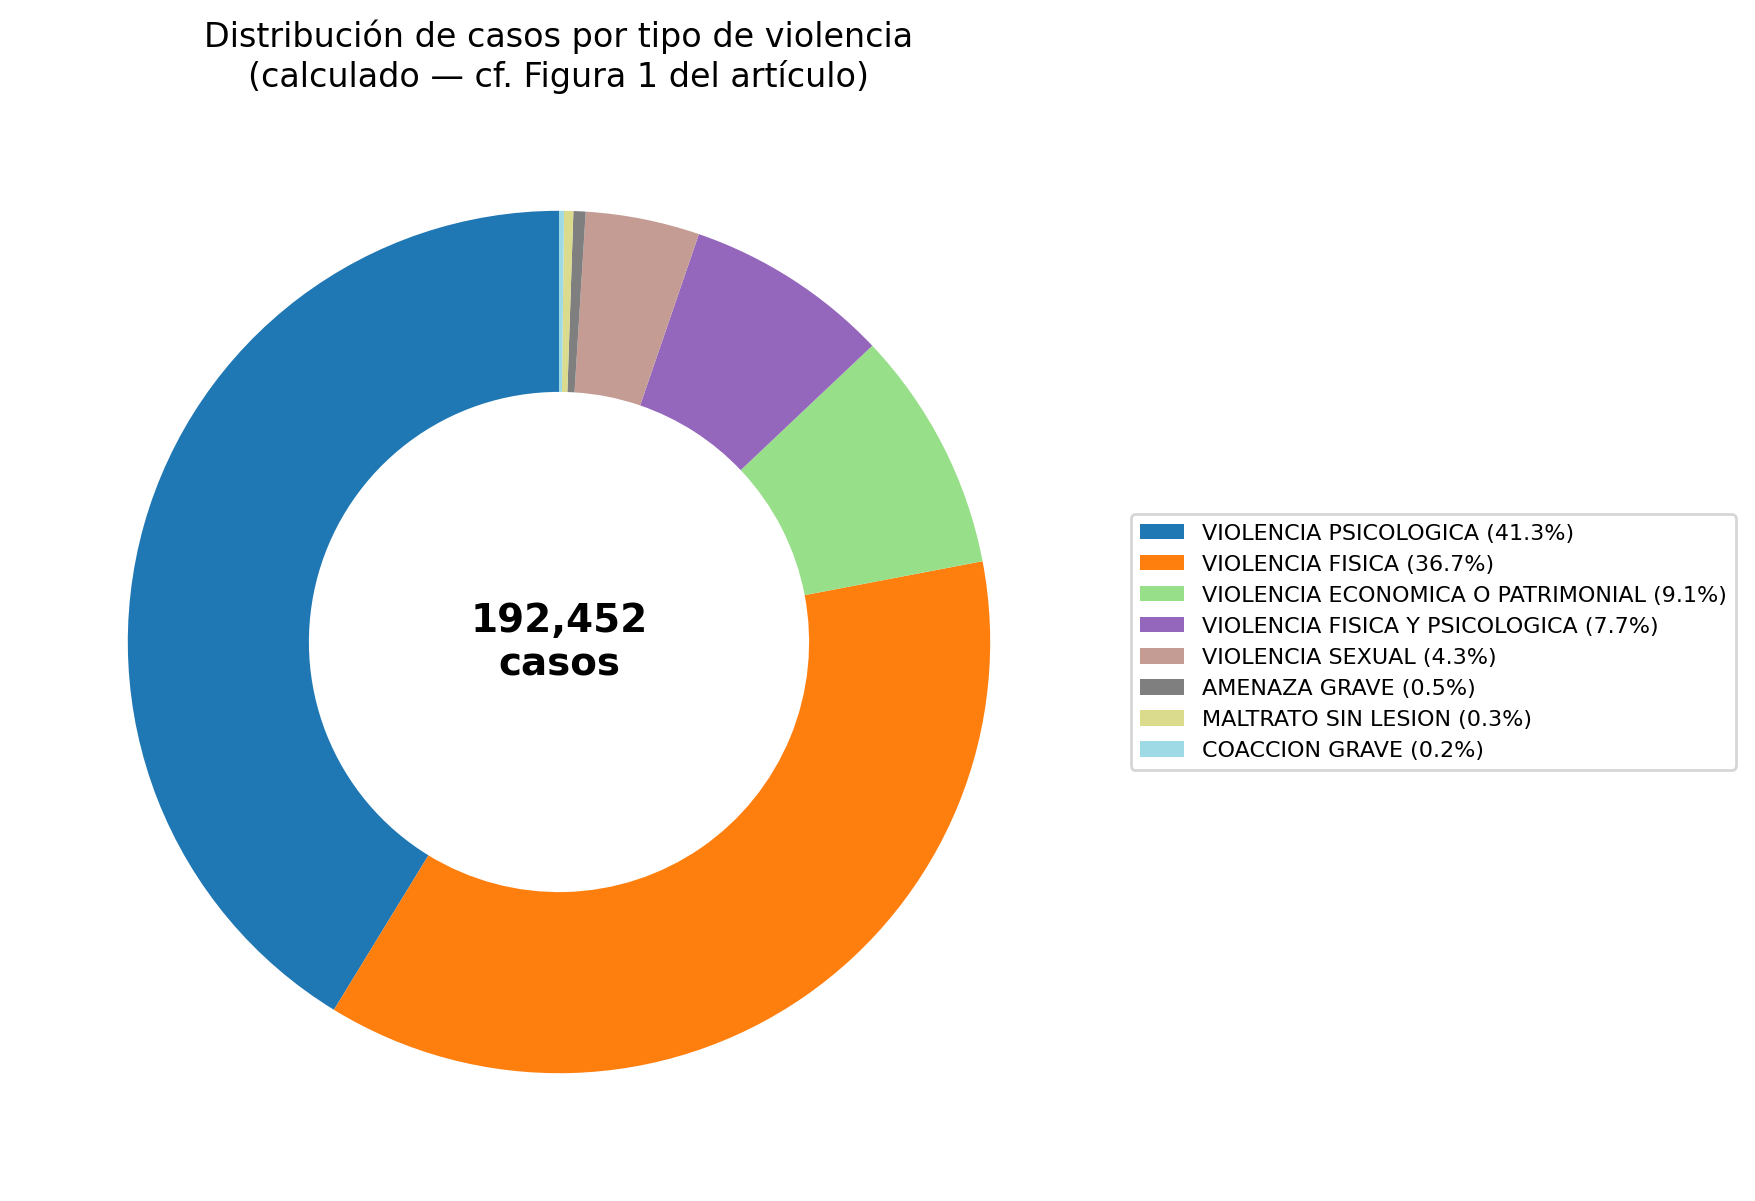

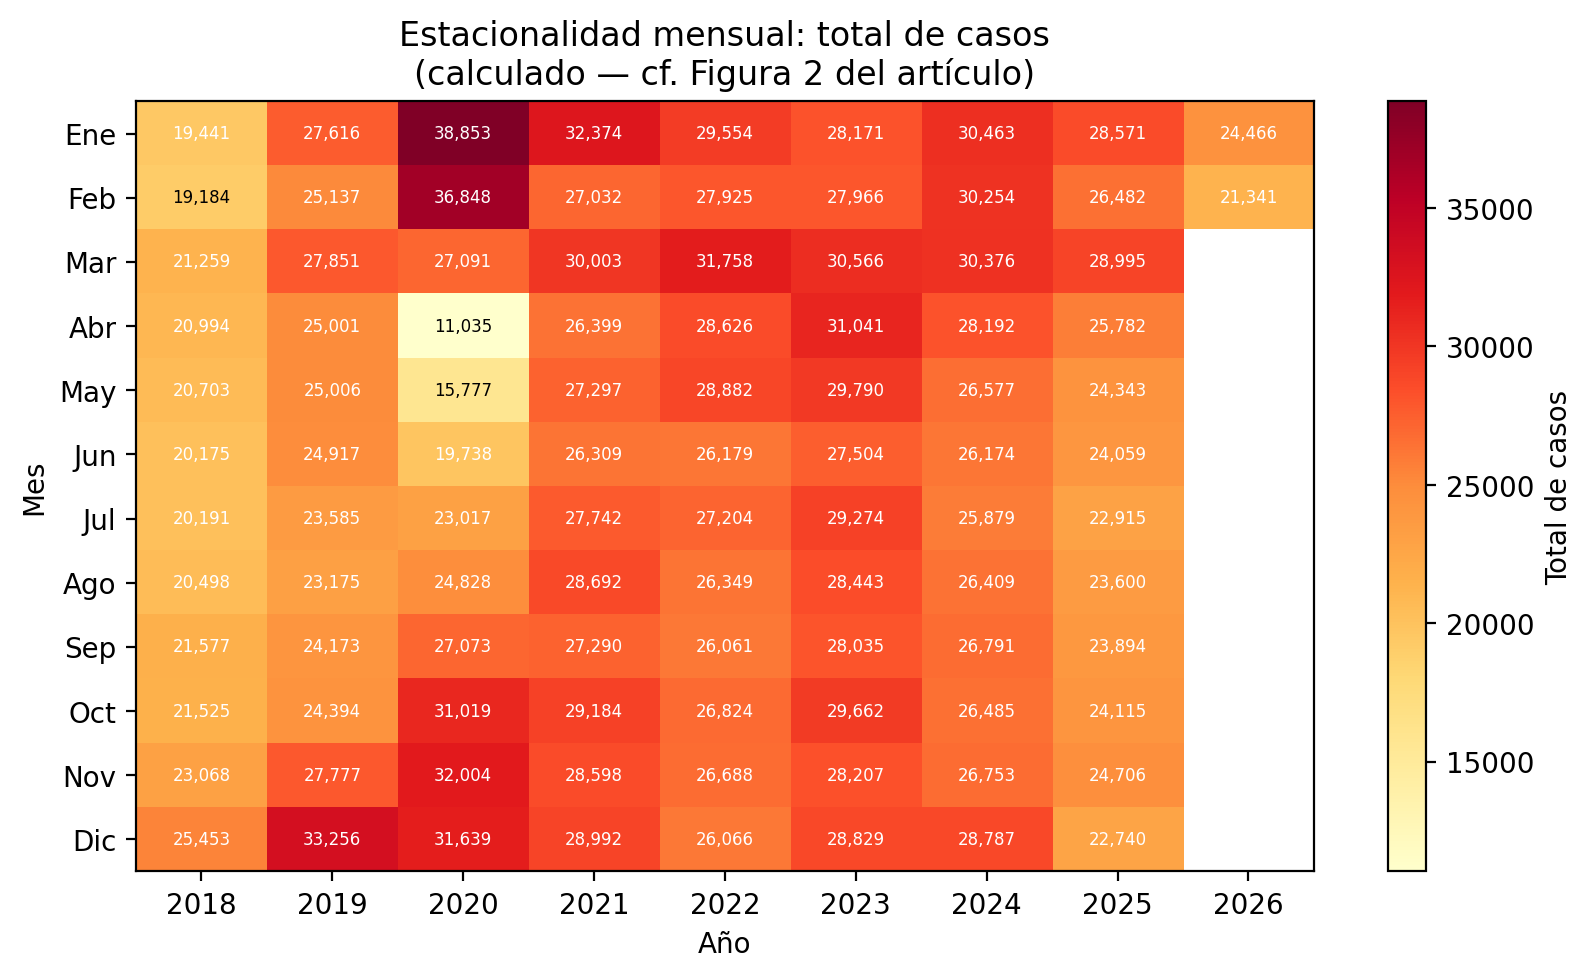


##################################################################################
# 4. CALCULO DE TASAS (TASA_100K / TASA_MAX)
##################################################################################
NO SE PUEDE REPRODUCIR ESTA MÉTRICA PORQUE FALTA: archivo de población femenina de 15+ años por departamento y año (fuente INEI, citada como referencia [28] en el artículo). Este archivo NO está presente ni en el notebook ni en los adjuntos proporcionados -- de hecho, TASA_100K/TASA_MAX NUNCA se calculan en ninguna de las 54 celdas del notebook oficial (0 apariciones literales de 'TASA_100K', 'TASA_MAX' o cualquier variable de población en todo el archivo). El pipeline continúa en MODO PROXY usando los conteos crudos que el notebook realmente usa hoy.

##################################################################################
# 5. INGENIERIA DE VARIABLES + AUDITORIA DE FEATURES
##################################################################################
Modo de fe

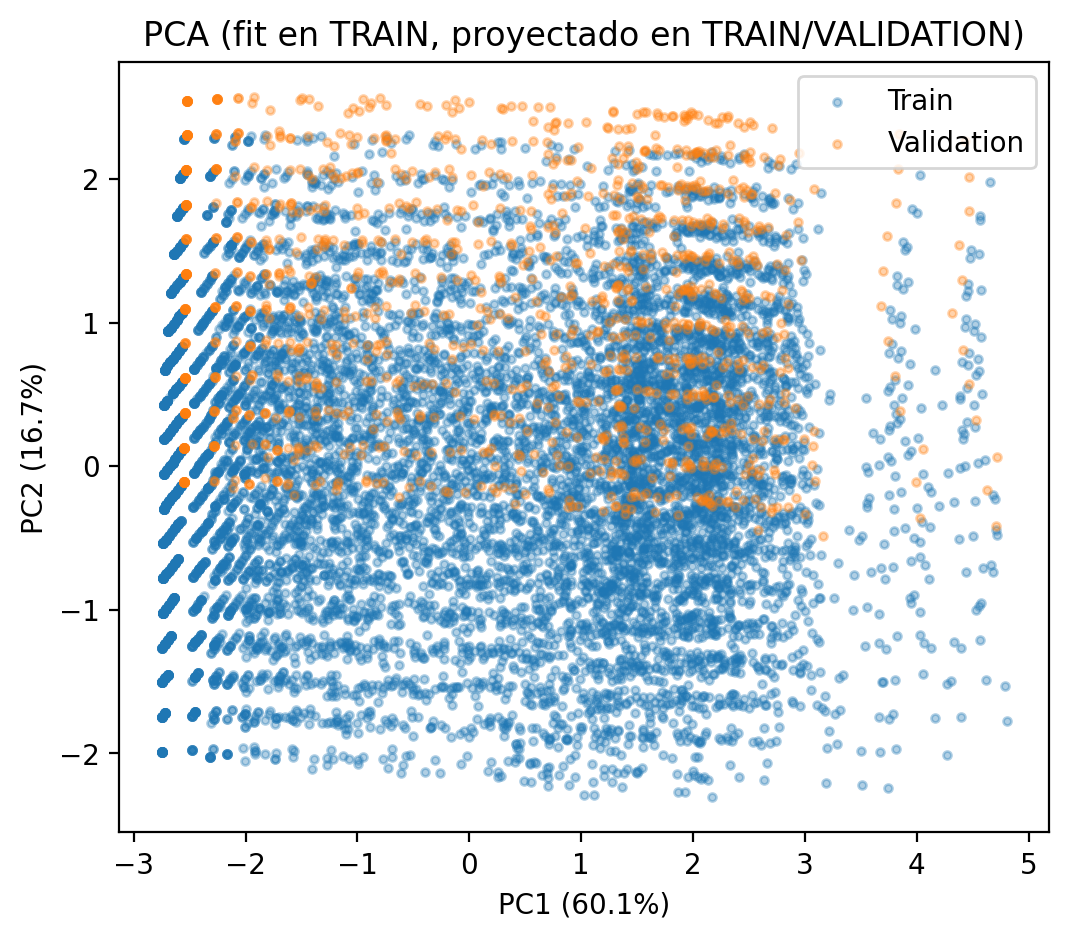

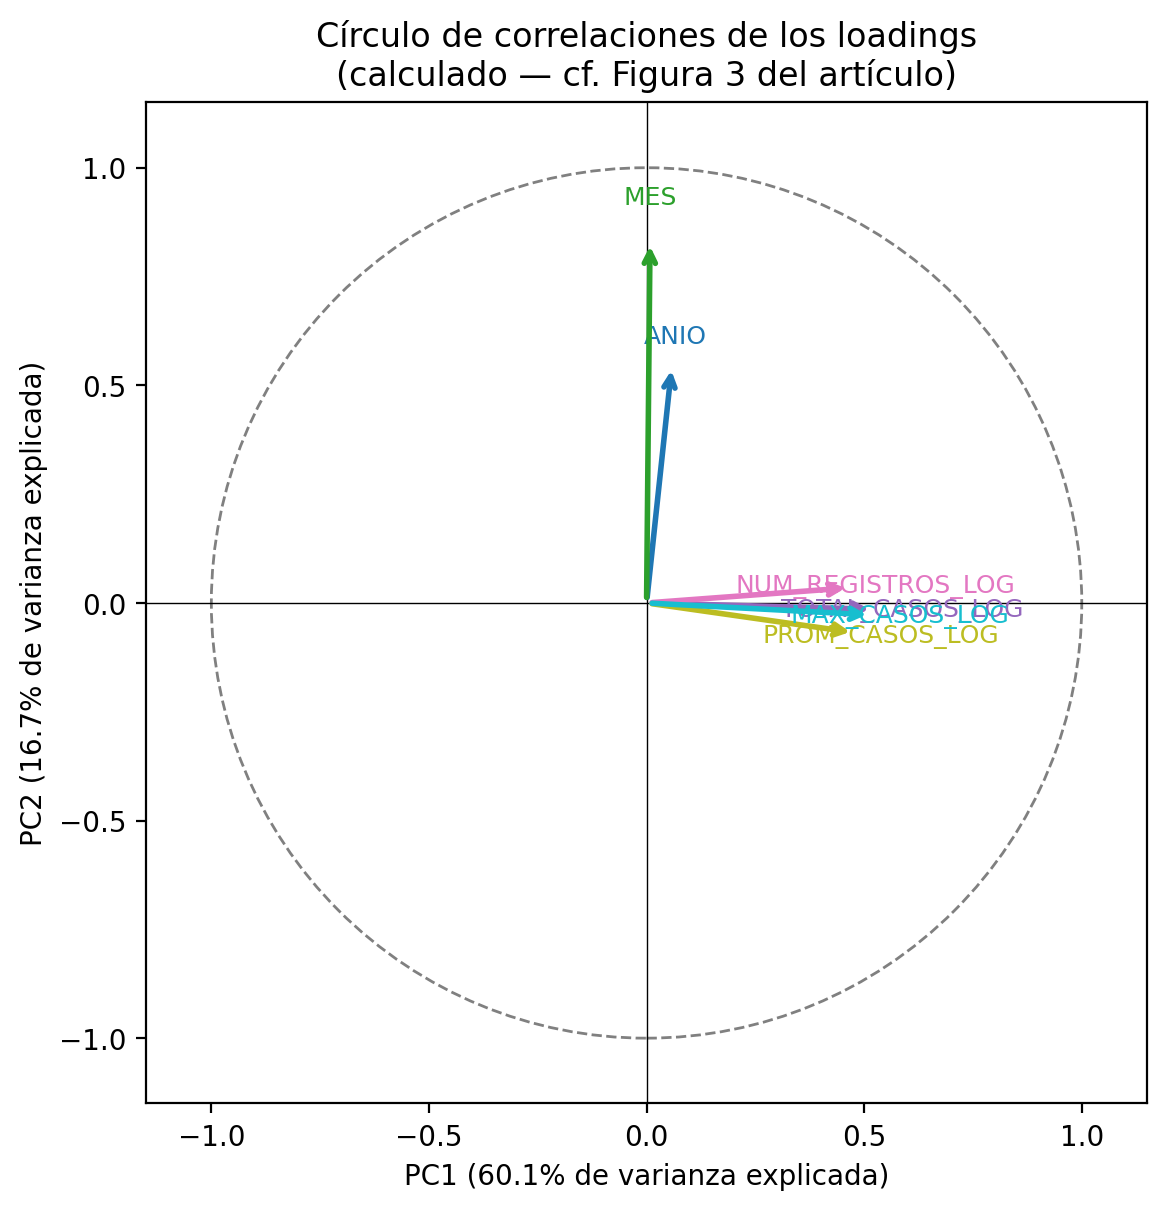

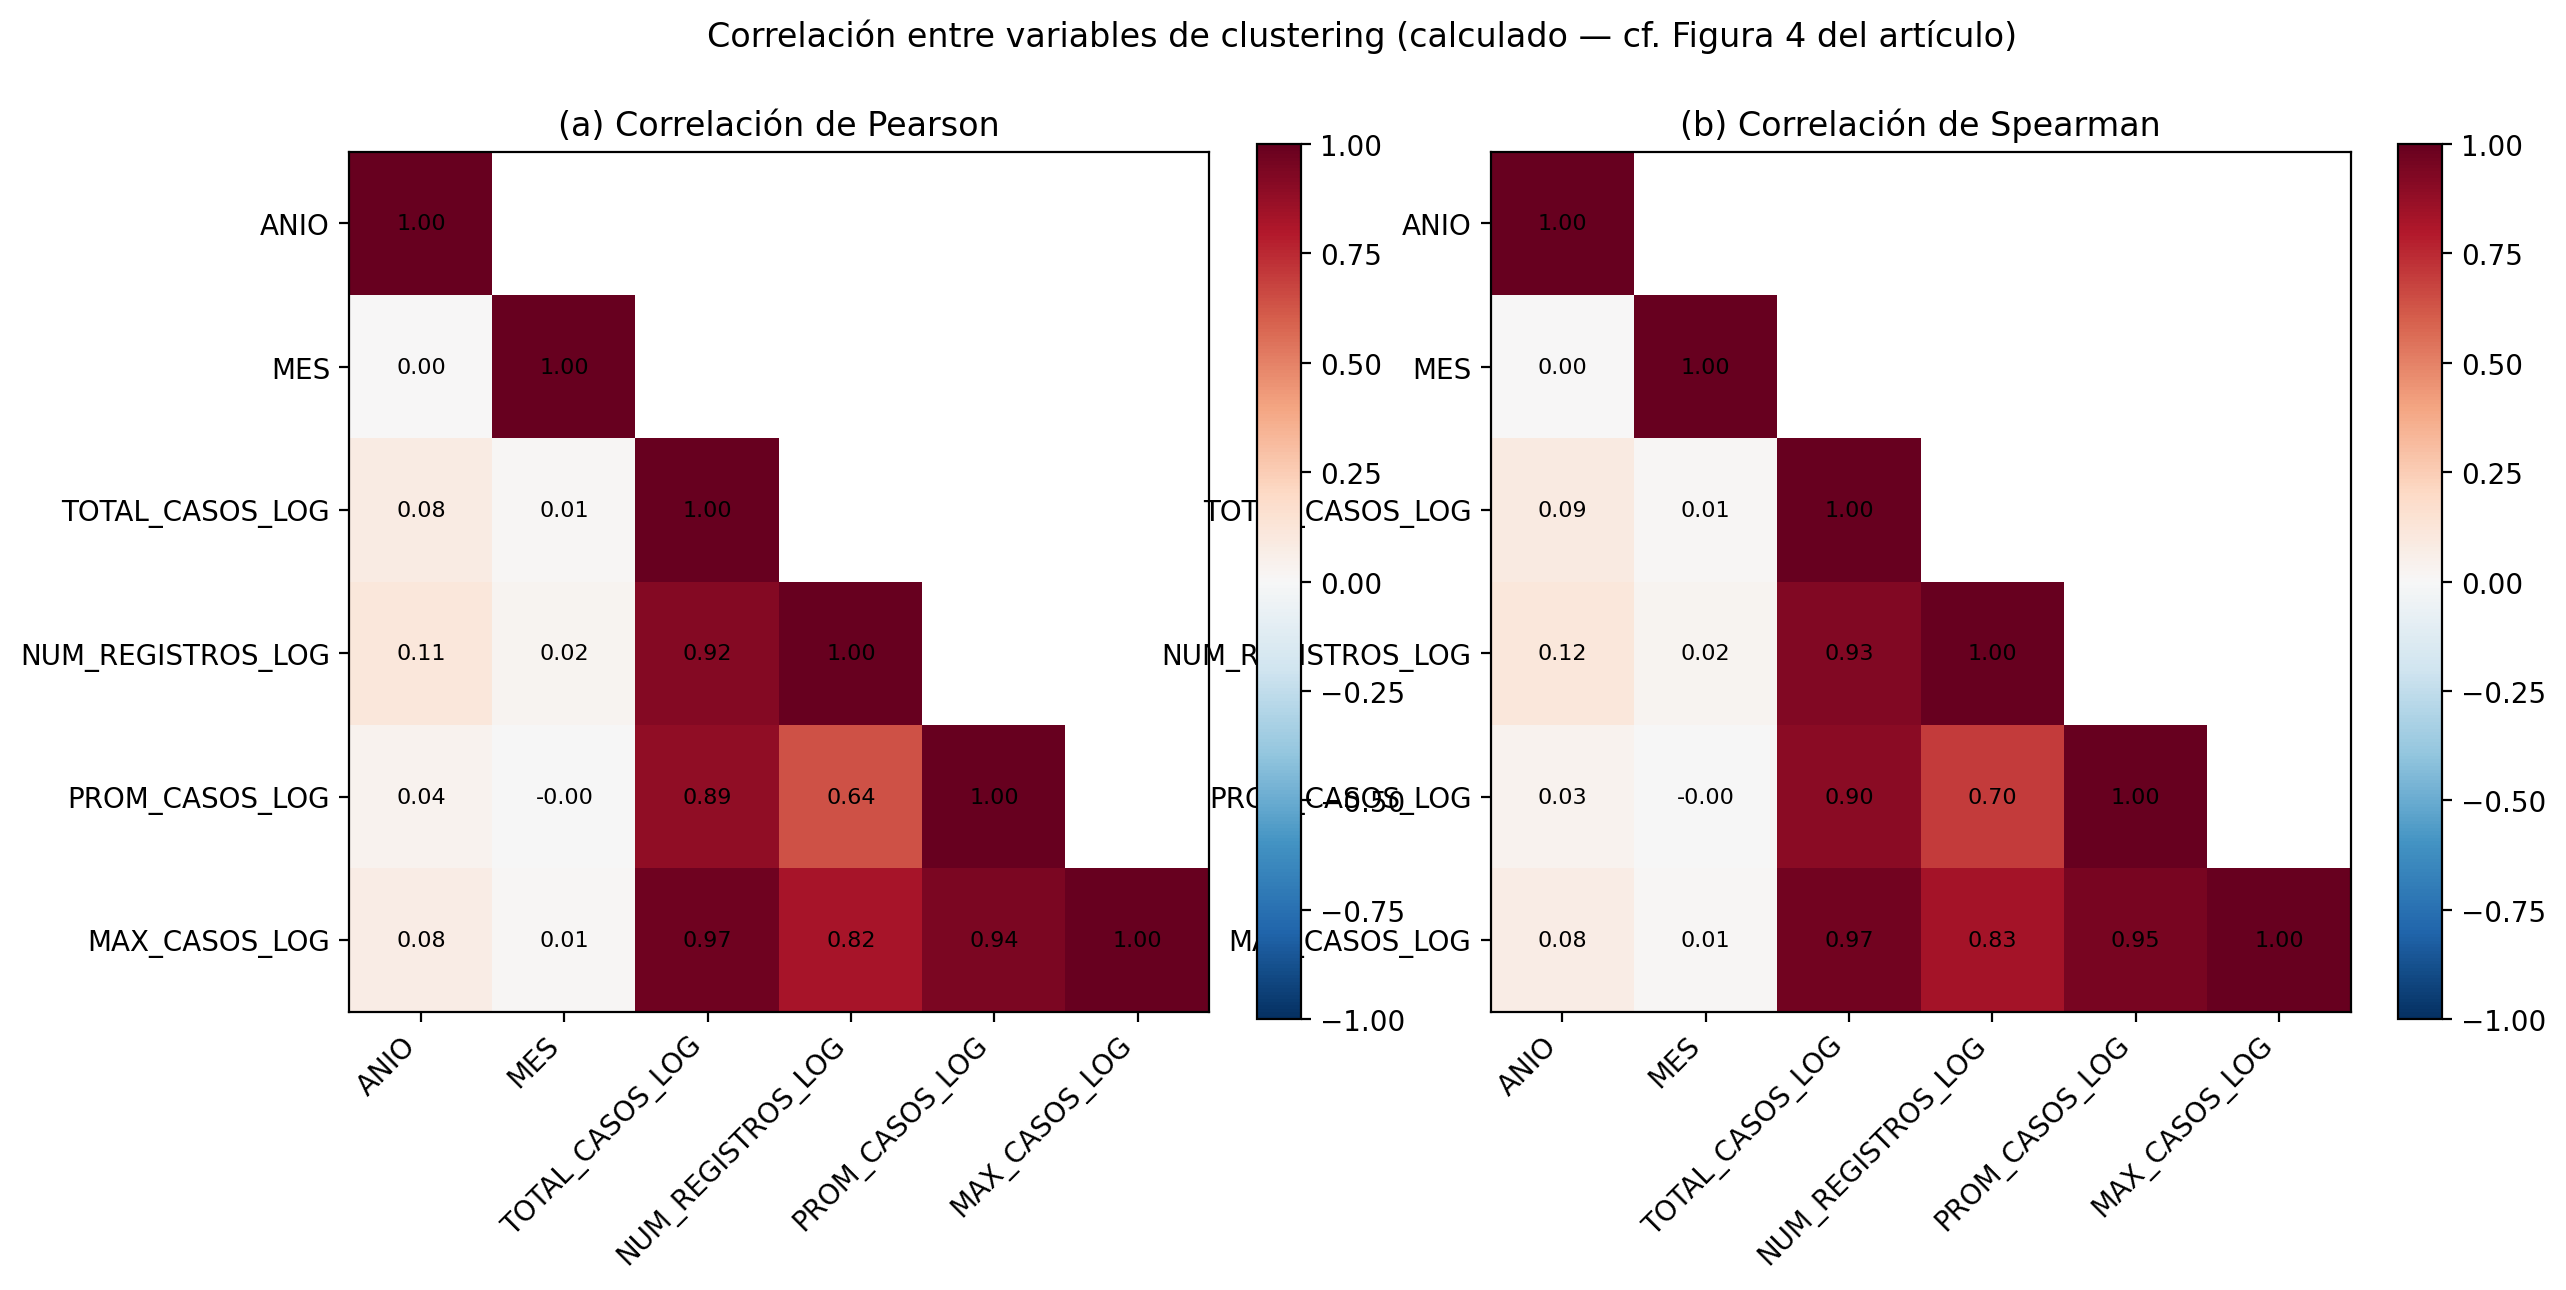


##################################################################################
# 8-9. ALGORITMOS DE CLUSTERING + METRICAS
##################################################################################
K-Means: búsqueda de K=2..10 (criterio: maximizar Silhouette en TRAIN)
  K= 2 | Sil=0.4036 | DBI=0.9996 | CH=8493.6 | Imbalance=1.05
  K= 3 | Sil=0.3017 | DBI=1.4720 | CH=5620.3 | Imbalance=1.71
  K= 4 | Sil=0.2356 | DBI=1.5976 | CH=4832.9 | Imbalance=1.20
  K= 5 | Sil=0.2345 | DBI=1.4505 | CH=4370.2 | Imbalance=1.39
  K= 6 | Sil=0.2325 | DBI=1.3203 | CH=4118.8 | Imbalance=1.24
  K= 7 | Sil=0.2351 | DBI=1.2821 | CH=3917.8 | Imbalance=1.26
  K= 8 | Sil=0.2413 | DBI=1.2642 | CH=3776.5 | Imbalance=1.44
  K= 9 | Sil=0.2394 | DBI=1.2266 | CH=3645.8 | Imbalance=1.34
  K=10 | Sil=0.2455 | DBI=1.1794 | CH=3574.9 | Imbalance=1.66

Conclusión computacional sobre K:
  K que maximiza Silhouette: 2
  K que minimiza DBI:        2
  K que maximiza CH:         2
  ¿K=2 es el máximo de Silhouette

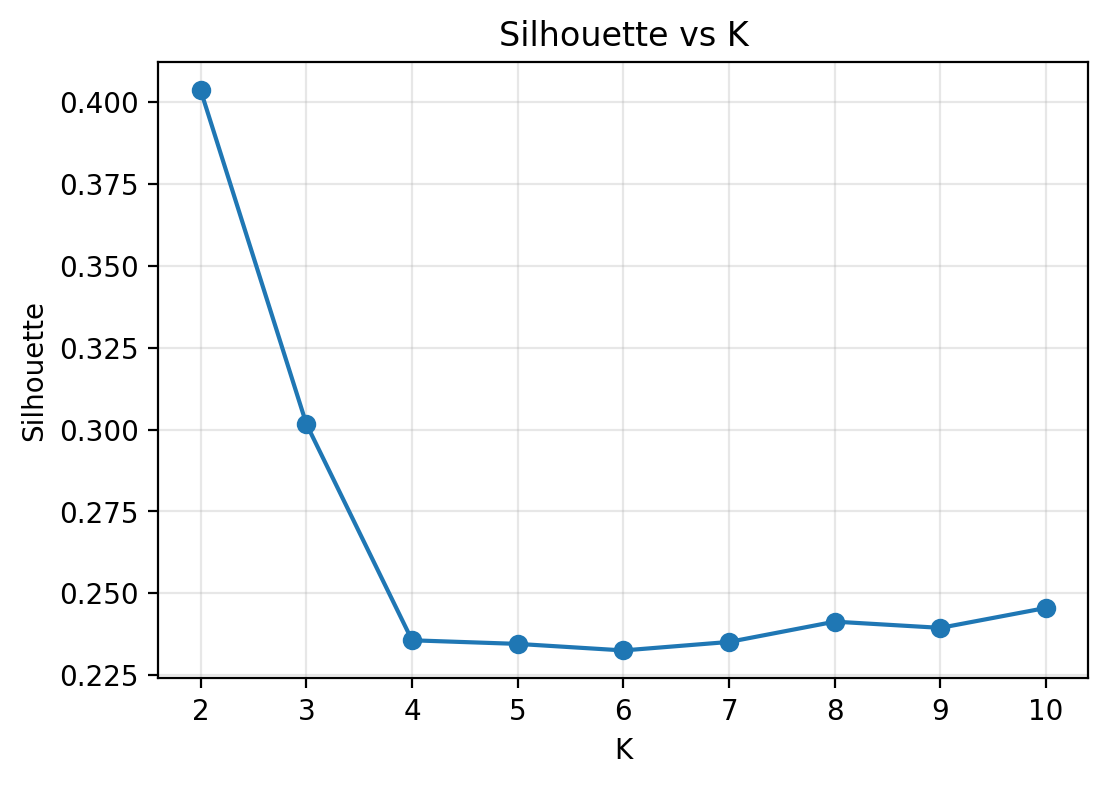

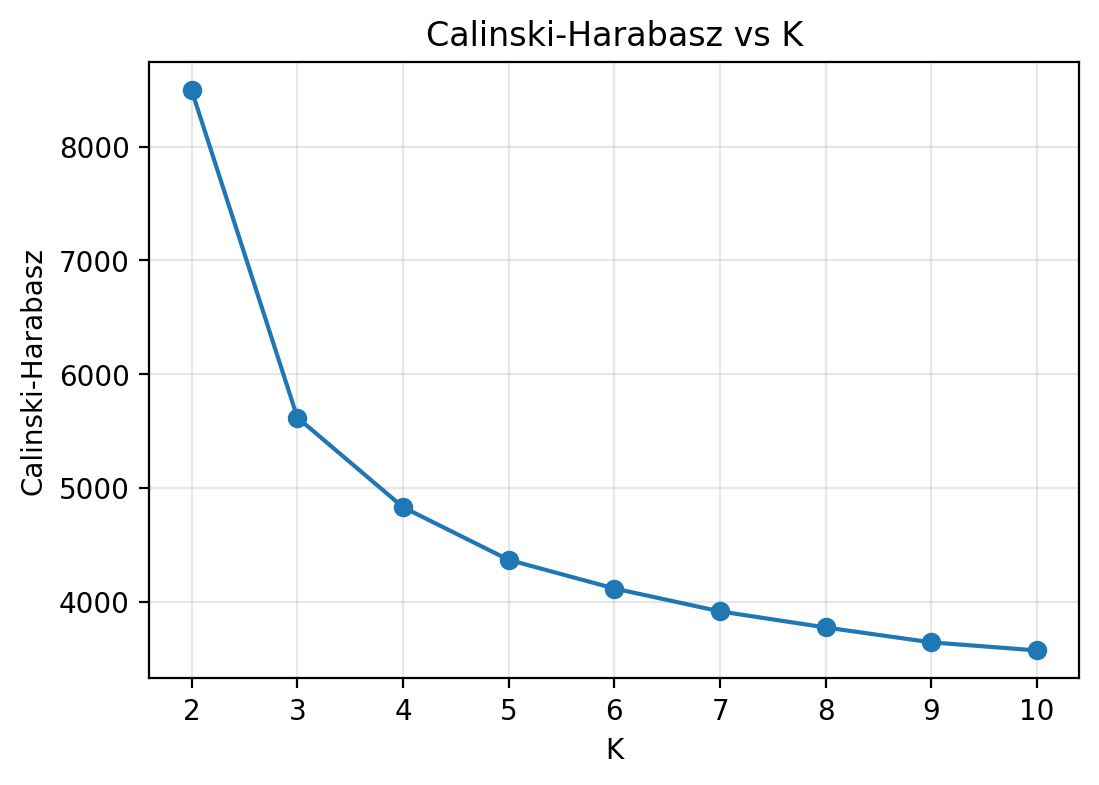

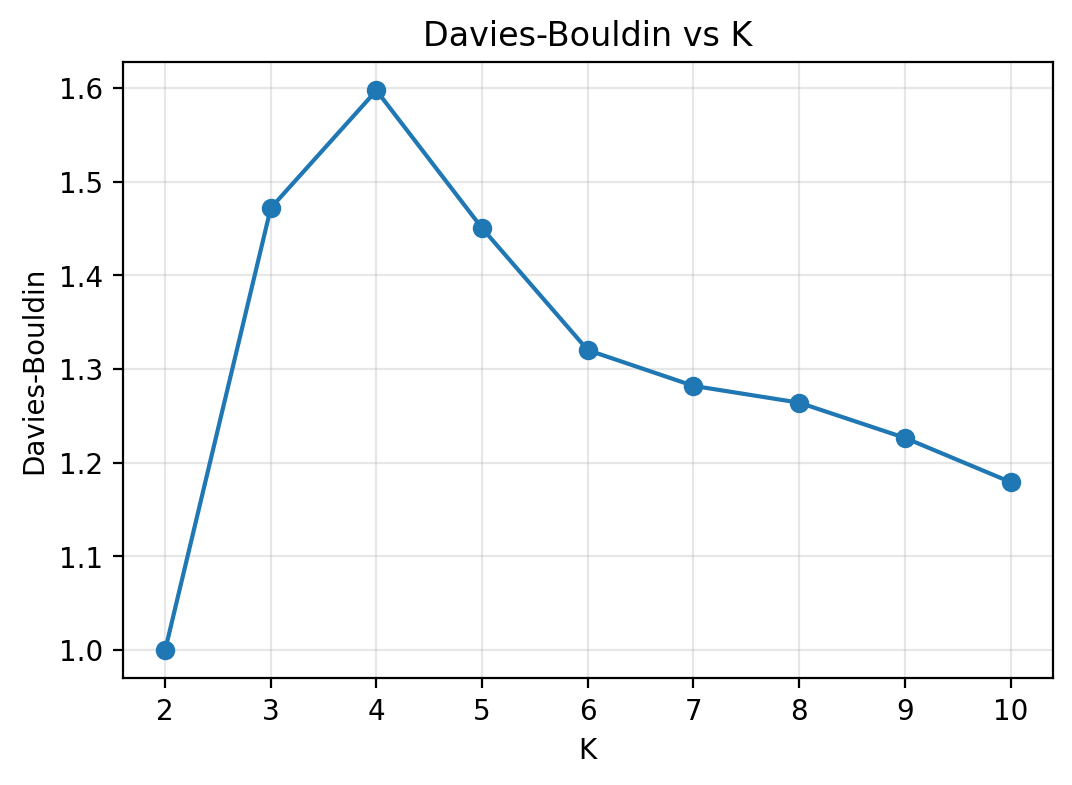


K seleccionado para K-Means = 2 (criterio: máximo Silhouette en TRAIN)


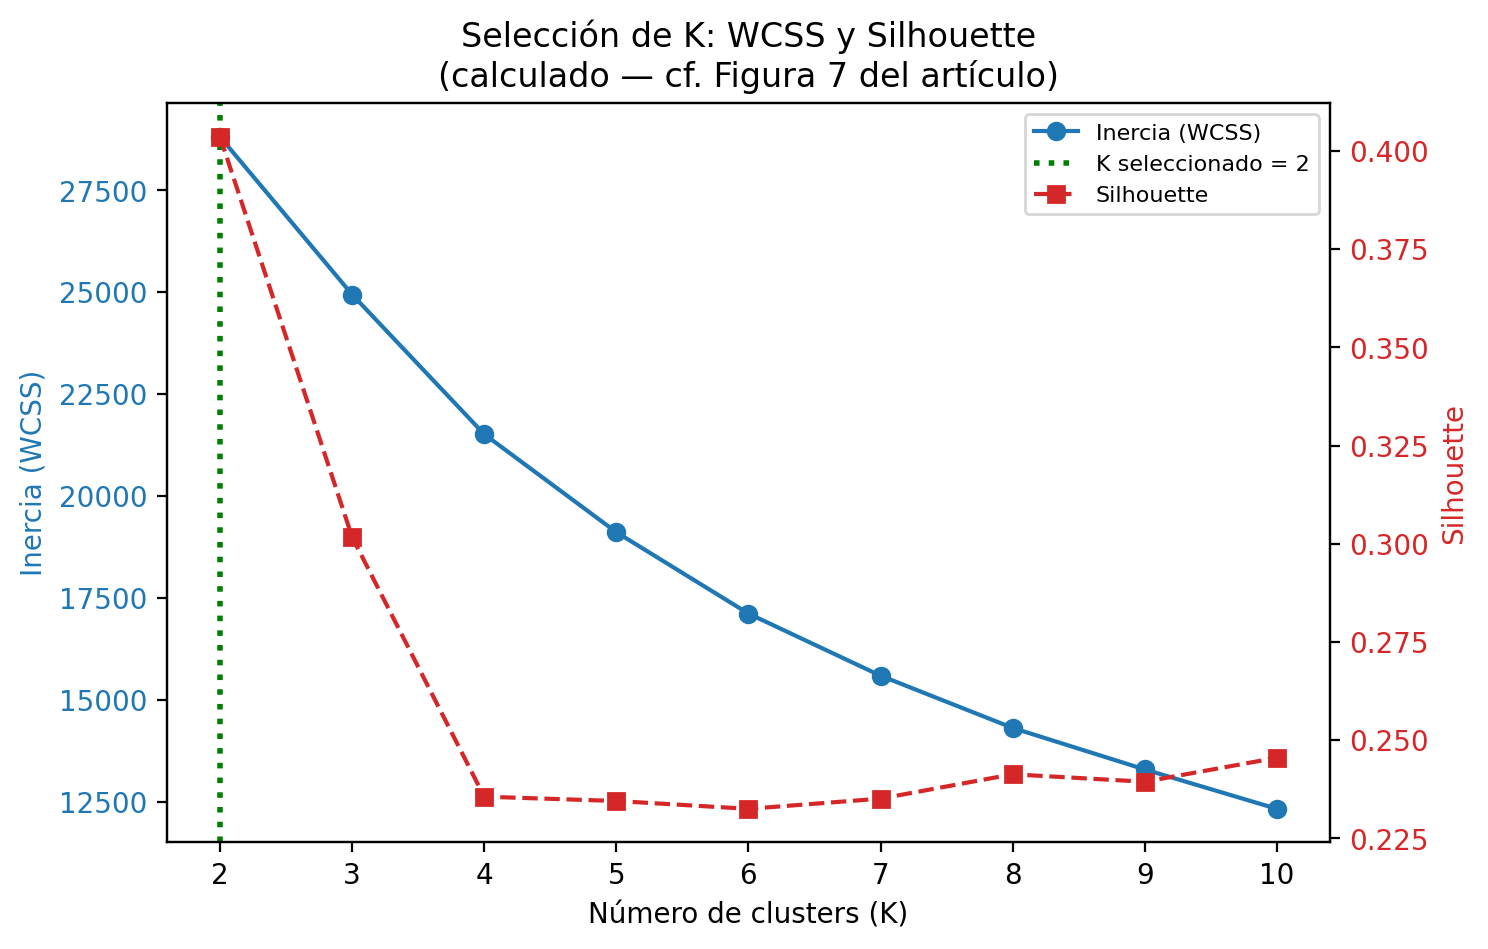

GMM: búsqueda de componentes 2..20 (criterio: minimizar BIC)
  k= 2 BIC=117,957.0
  k= 3 BIC=101,863.3
  k= 4 BIC=67,815.9
  k= 5 BIC=60,662.4
  k= 6 BIC=52,820.2
  k= 7 BIC=49,913.5
  k= 8 BIC=40,881.5
  k= 9 BIC=36,301.4
  k=10 BIC=37,357.9
  k=11 BIC=34,758.6
  k=12 BIC=29,219.4
  k=13 BIC=8,303.3
  k=14 BIC=8,082.4
  k=15 BIC=29,883.1
  k=16 BIC=26,637.4
  k=17 BIC=25,466.1
  k=18 BIC=24,714.1
  k=19 BIC=3,786.0
  k=20 BIC=25,241.4
K óptimo GMM (min BIC) = 19  (artículo reporta 20; el notebook original sólo buscaba 2..9, por lo que nunca podía encontrar 20)
Agglomerative/Ward: búsqueda de K=2..10
  K= 2 Sil=0.3847
  K= 3 Sil=0.2575
  K= 4 Sil=0.1747
  K= 5 Sil=0.1725
  K= 6 Sil=0.1764
  K= 7 Sil=0.1764
  K= 8 Sil=0.1847
  K= 9 Sil=0.1832
  K=10 Sil=0.1834
K óptimo Agglomerative (max Sil) = 2 (artículo reporta 3)
DBSCAN: grid search de eps x min_samples
 eps  min_samples  n_clusters  noise_pct  silhouette
 0.3            5         220      45.37     -0.1049
 0.3           10        

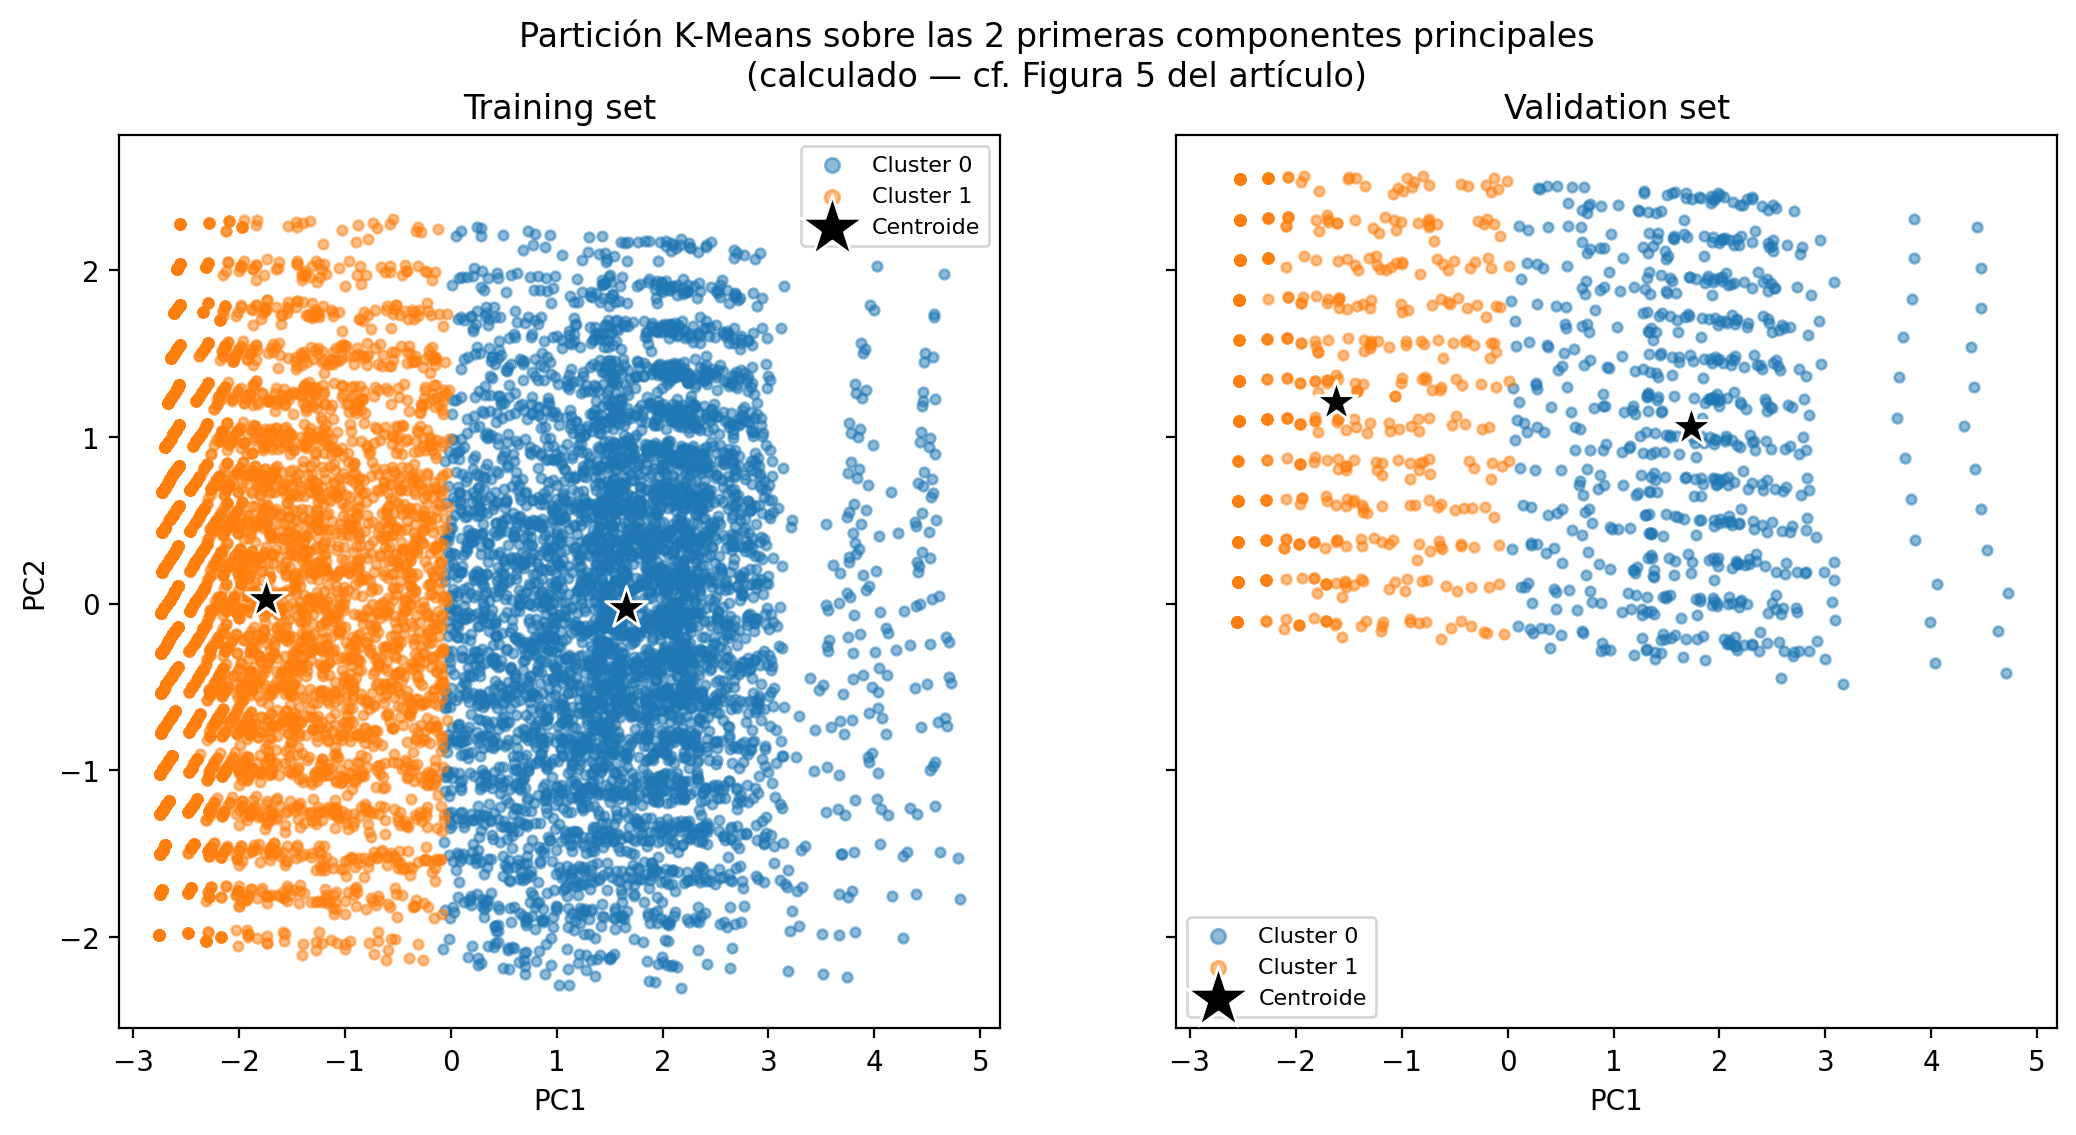

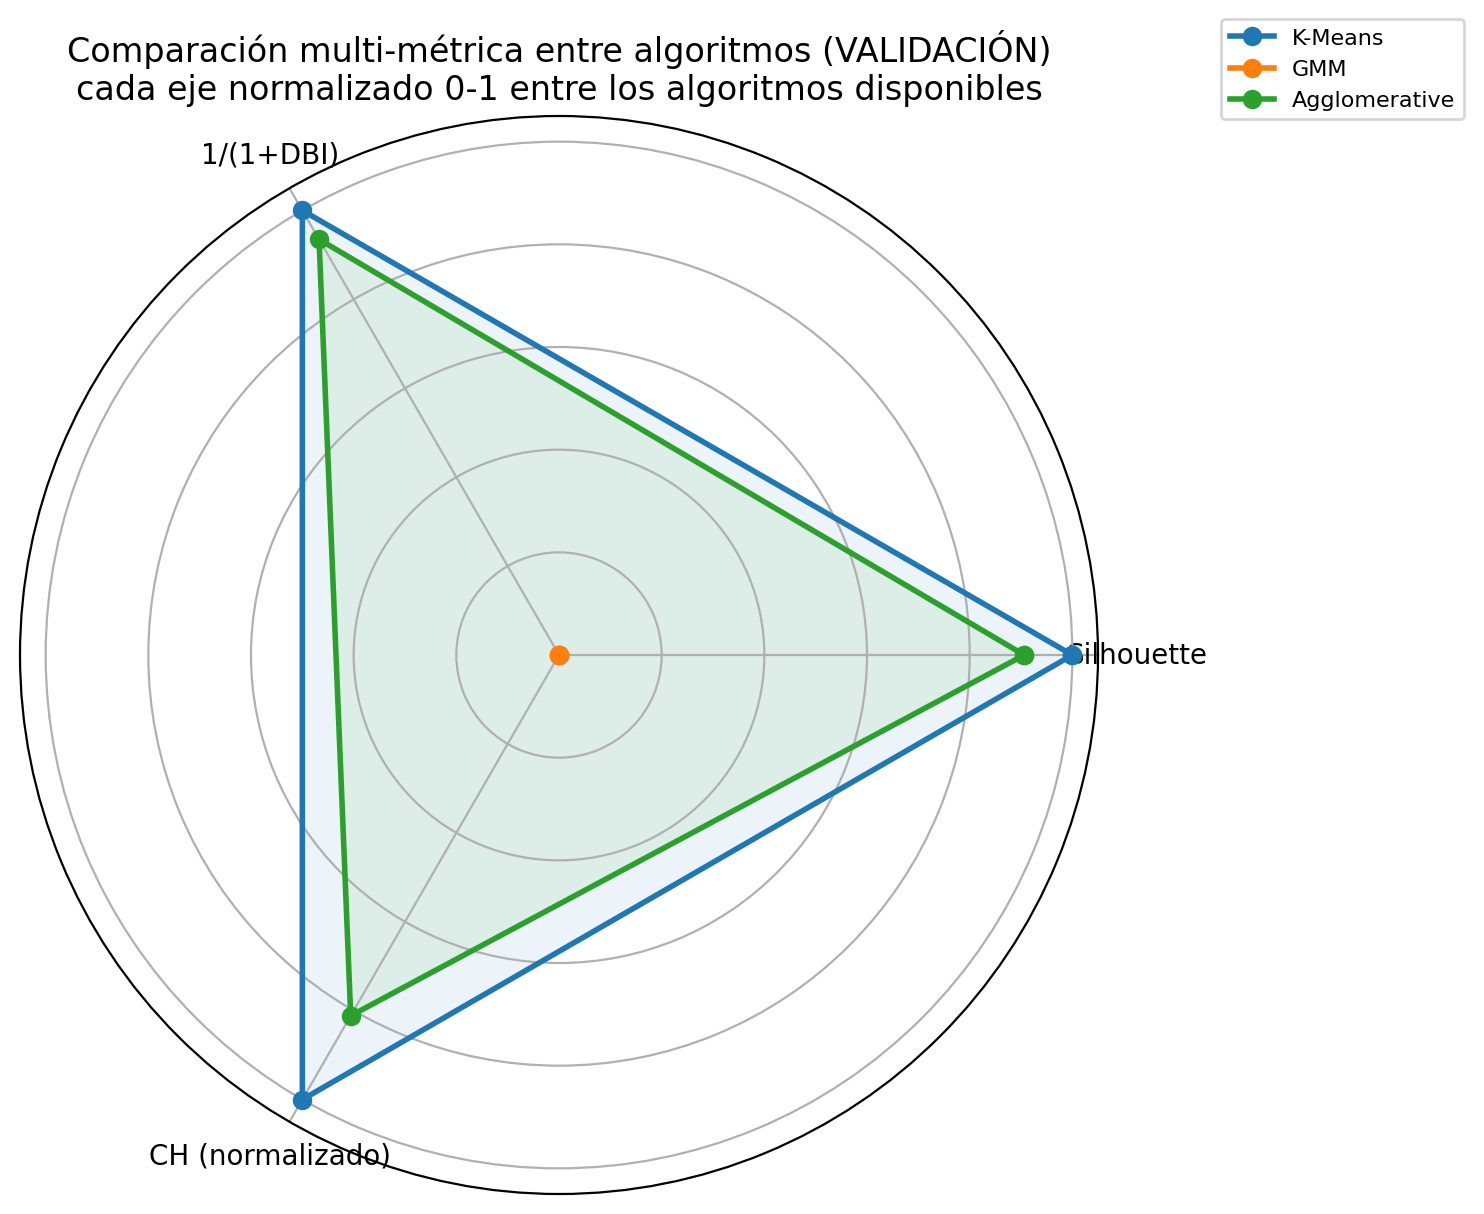


##################################################################################
# 11. BOOTSTRAP DEL SILHOUETTE
##################################################################################
  K-Means         Sil=0.4064 95%CI=[0.3943,0.4139] (articulo: 0.279 [0.271,0.287])
  GMM             Sil=-0.0009 95%CI=[-0.0086,0.0075] (articulo: 0.049 [0.041,0.057])
  Agglomerative   Sil=0.3853 95%CI=[0.3741,0.3965] (articulo: 0.259 [0.25,0.268])
  DBSCAN          Sil=0.0797 95%CI=[0.0511,0.1237] (articulo: 0.483 [0.457,0.514])


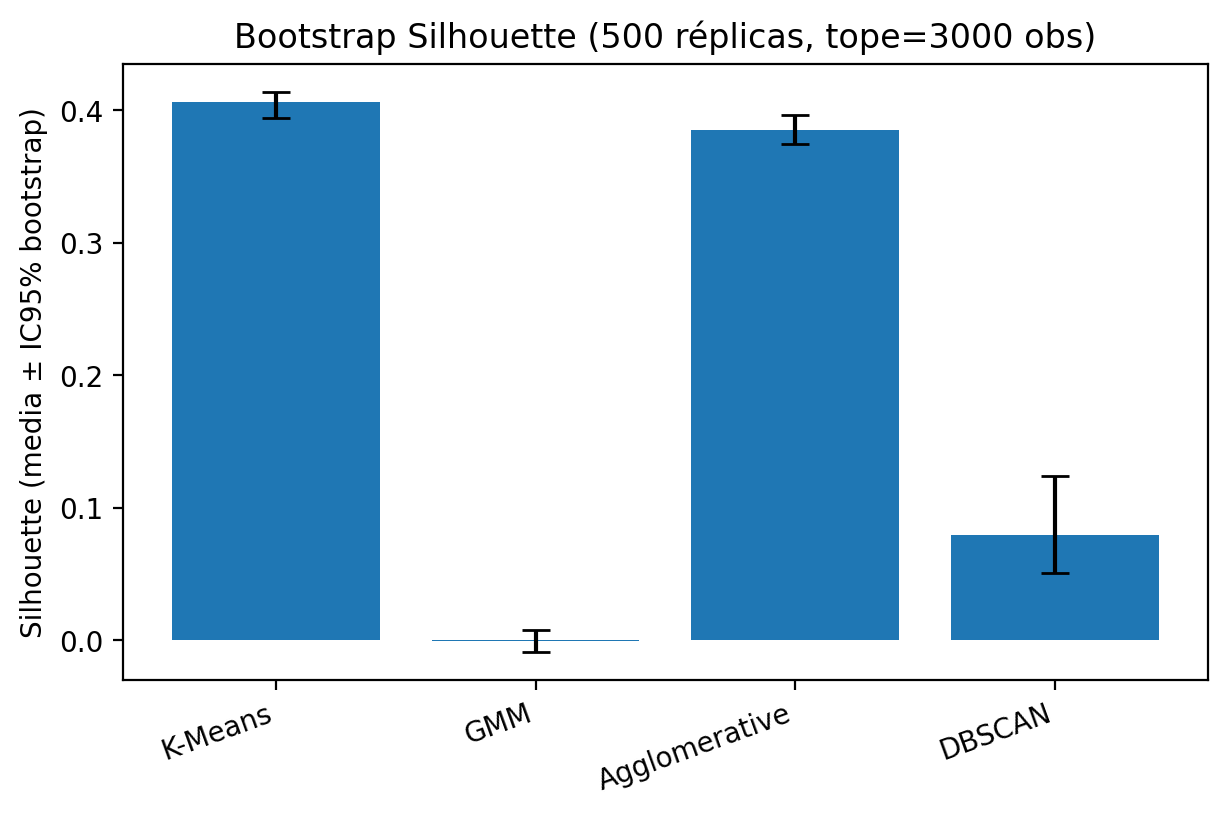


##################################################################################
# 12. KRUSKAL-WALLIS + DUNN
##################################################################################
Kruskal-Wallis sobre 'TOTAL_CASOS' agrupado por 2 clusters: H=6911.1038 df=1 n=9224 p=0.000e+00
  eta²   (H-k+1)/(n-k)  = 0.7493
  epsilon² H(n+1)/(n²-1) = 0.7493
  Articulo: H=6284.04 eta²=epsilon²=0.6813
  CIRCULARIDAD PARCIAL DETECTADA: 'TOTAL_CASOS' participó en la construcción de los clusters (está en CLUSTER_FEATURES). Este resultado es un control de coherencia interna, NO una validación externa.
scikit-posthocs no disponible: Dunn omitido (instalar con 'pip install scikit-posthocs --break-system-packages').

##################################################################################
# 13. VALIDACION NO CIRCULAR (taxonomia)
##################################################################################
                                                  Prueba                     

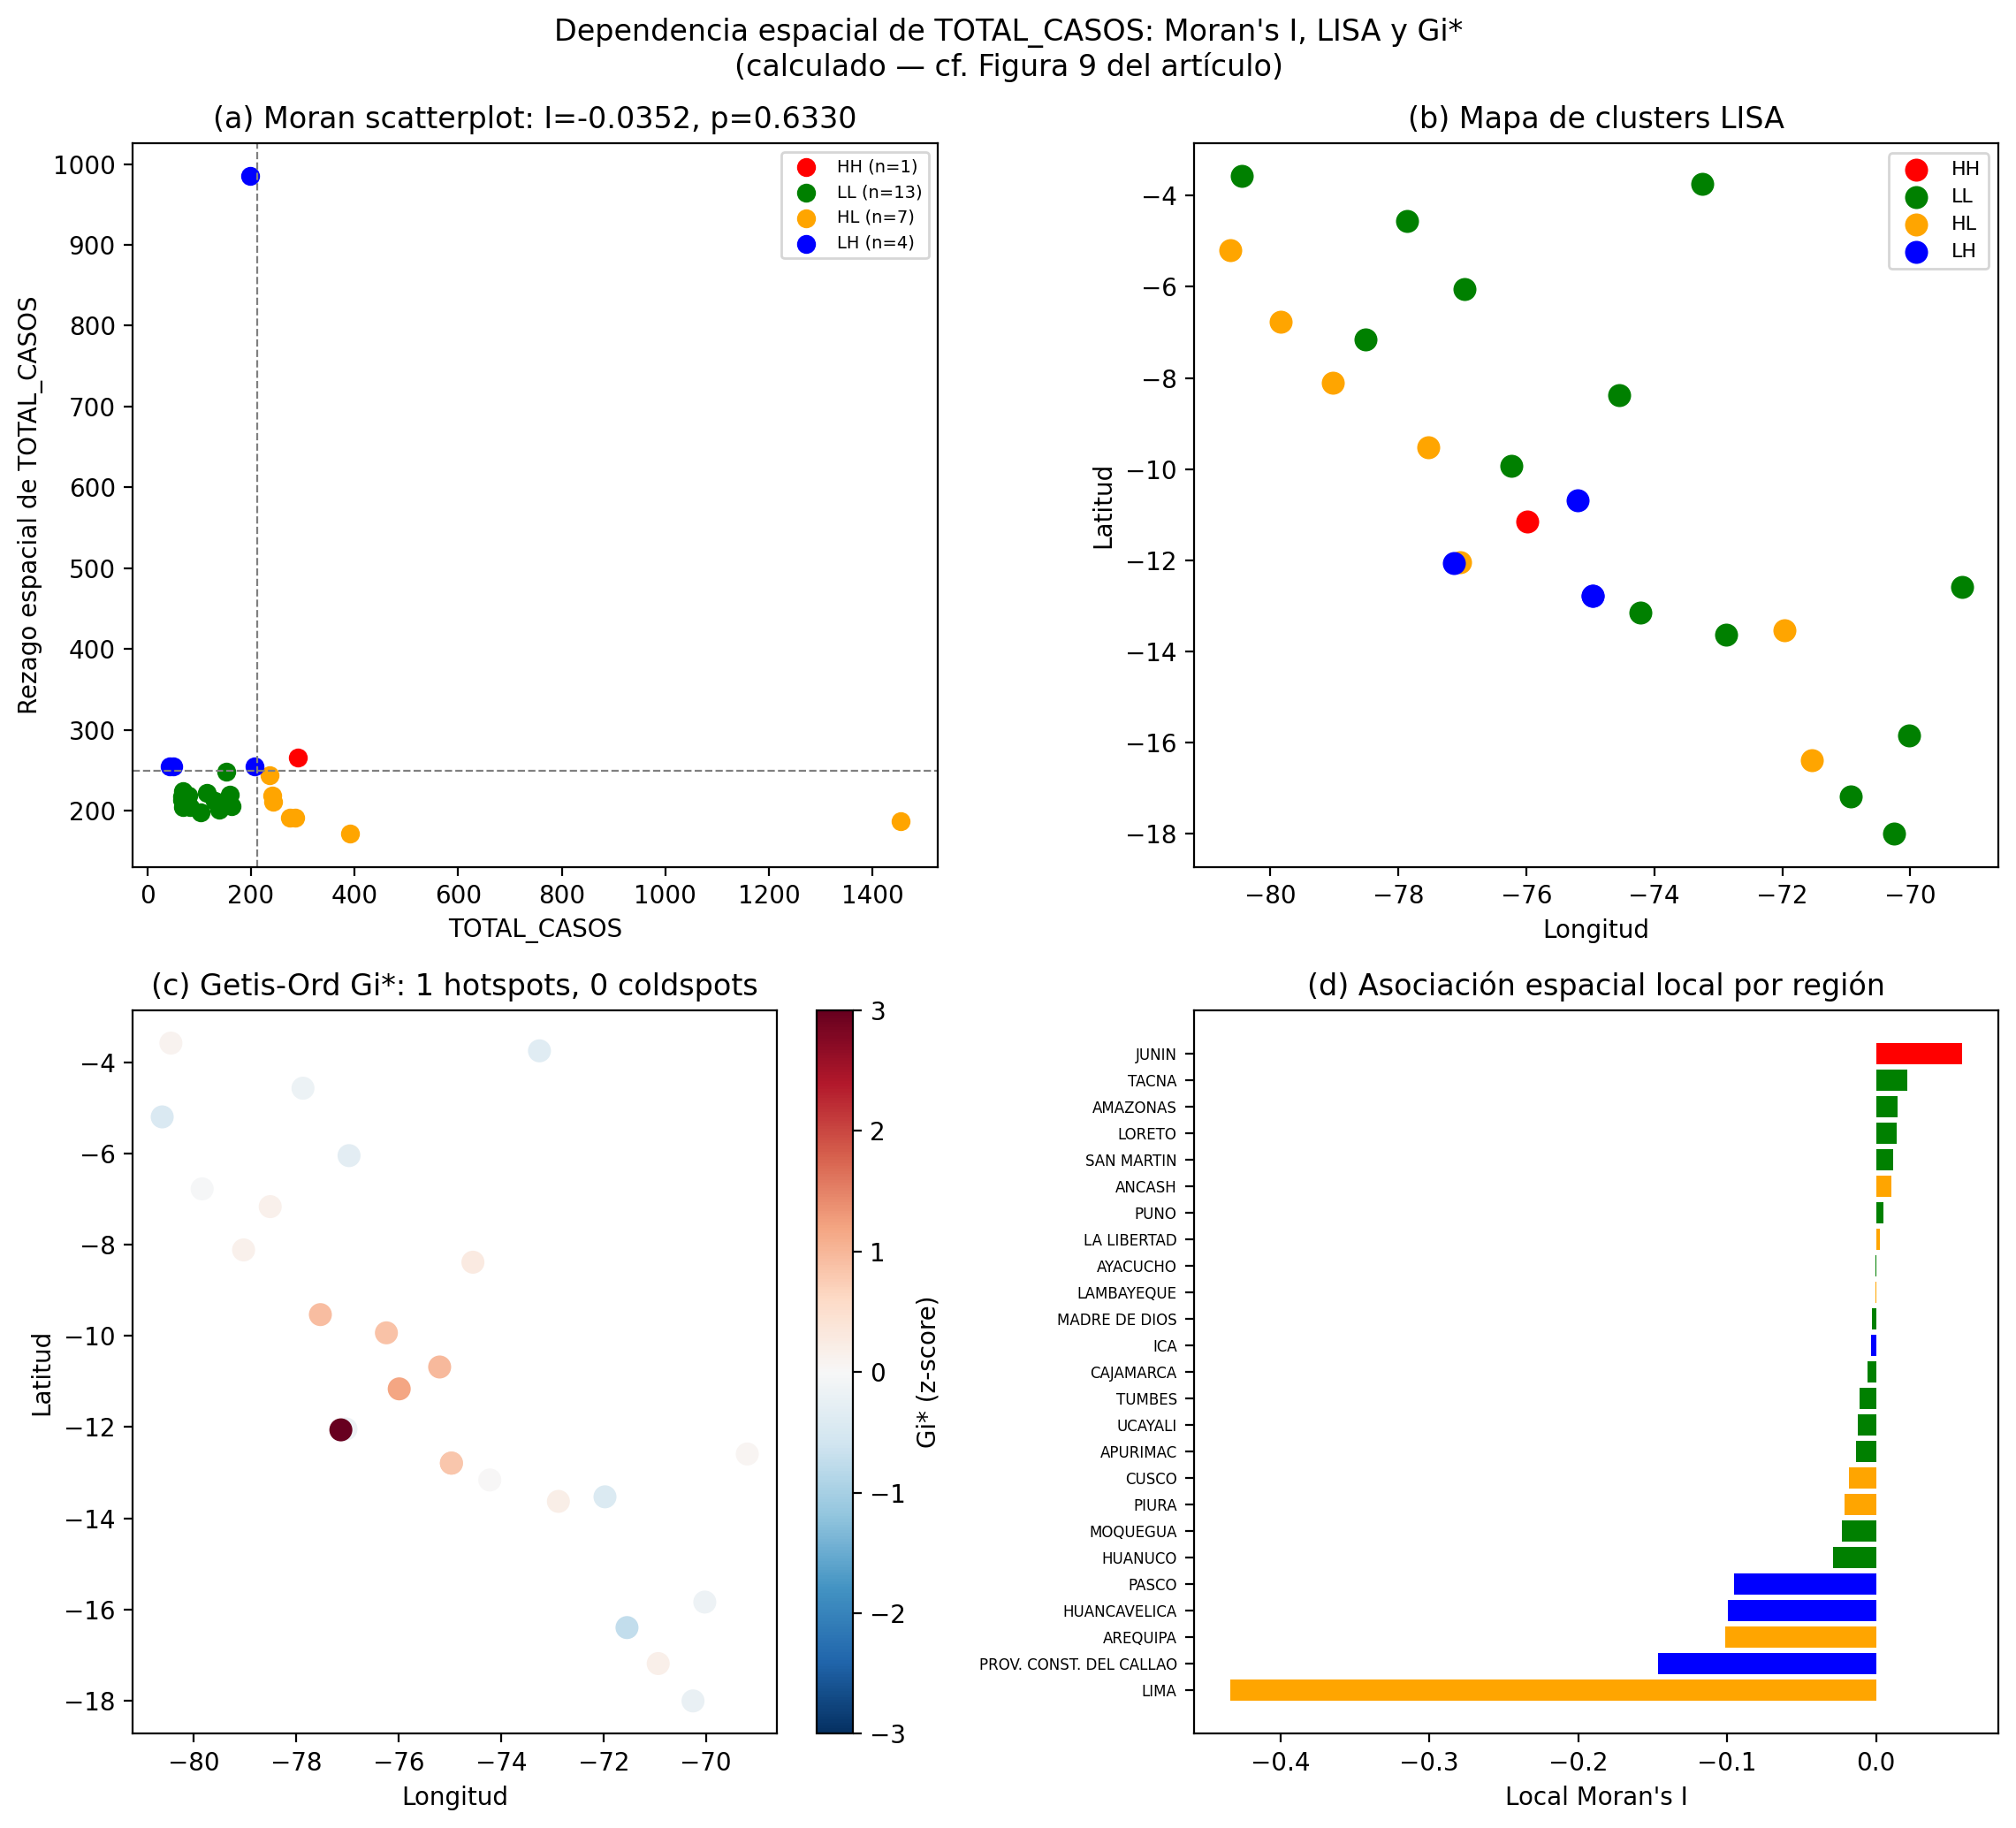


##################################################################################
# 18. STRESS TESTS (T1-T4)
##################################################################################
[T1] Perturbacion estructural -- DEFINICION PROPIA. El articulo nombra 'T1 = perturbacion estructural' sin dar una formula; el notebook oficial usa una definicion DISTINTA e incompatible para su propio 'T1' (inflar el dataset x5), que tampoco corresponde a una perturbacion estructural en sentido habitual. Aqui T1 se define como: intercambiar el vector de caracteristicas completo entre un 10% de las filas elegidas al azar, preservando la distribucion marginal pero rompiendo la asociacion fila-a-fila original.
  T1_perturbacion_estructural      K=2 Sil=0.4036 DBI=0.9996 CH=8493.62 Noise%=0.0 ARI_vs_baseline=0.798
[T2] +30% observaciones uniformes (misma definicion que el articulo)
  T2_uniforme_30pct                K=2 Sil=0.3437 DBI=1.1425 CH=7892.53 Noise%=0.0 ARI_vs_baseline=0.9707
[T3] Ruido g

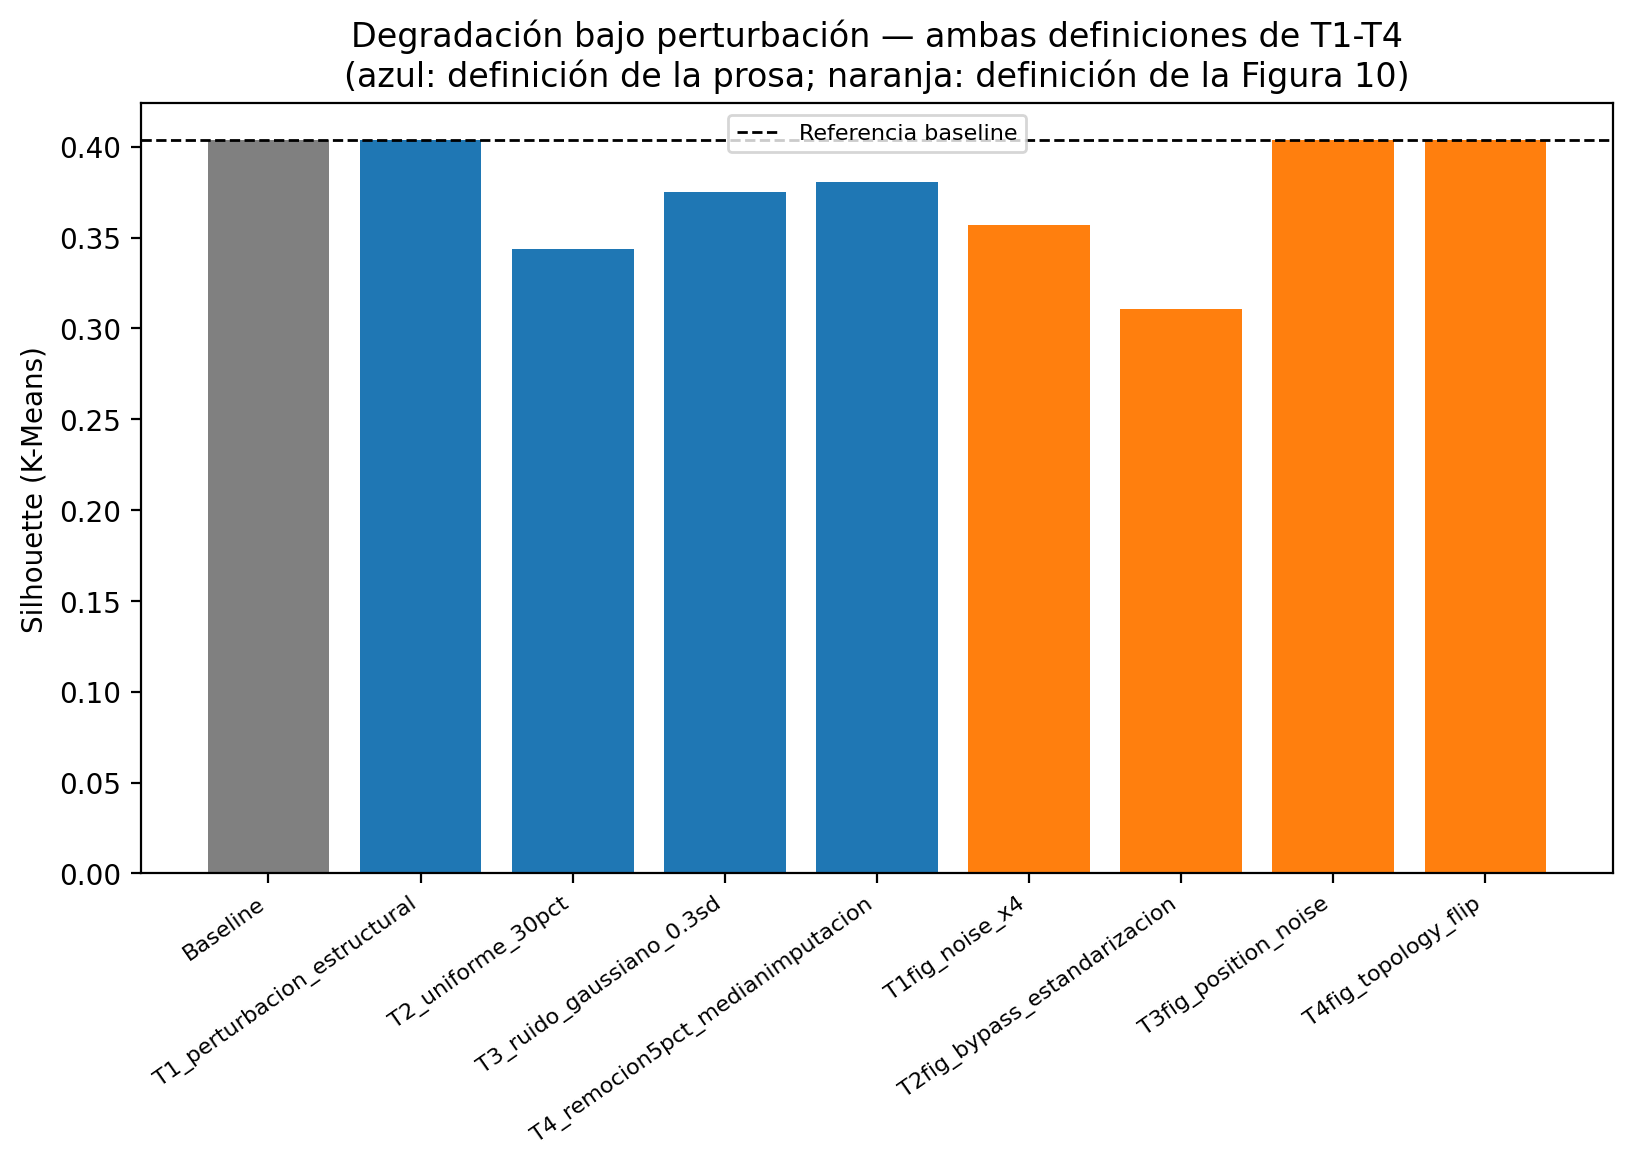


##################################################################################
# 19. ROLLING WINDOW 2021-2025
##################################################################################
  2021: Sil=0.5143 (articulo=0.355) ARI=0.887 %Alto=55.56%
  2022: Sil=0.496 (articulo=None) ARI=0.9055 %Alto=55.8%
  2023: Sil=0.492 (articulo=None) ARI=0.9201 %Alto=54.6%
  2024: Sil=0.4919 (articulo=None) ARI=0.9671 %Alto=54.69%
  2025: Sil=0.4787 (articulo=0.293) ARI=0.9898 %Alto=54.95%


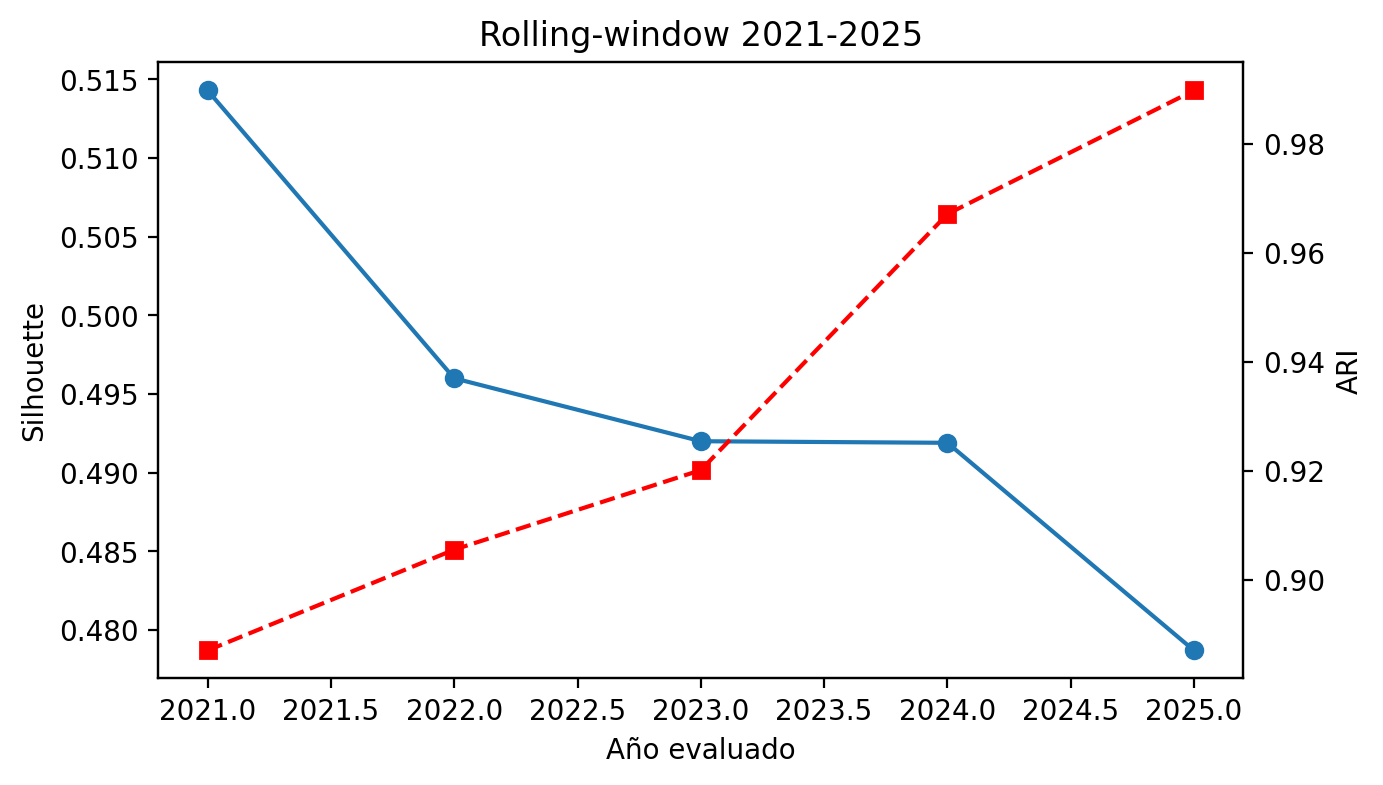


##################################################################################
# 20. MODELOS ANUALES INDEPENDIENTES
##################################################################################
  2018: N=1590 %Alto=48.74% TasaAlto=320.03 TasaResto=7.42 TiposActivos=8
  2019: N=1599 %Alto=50.28% TasaAlto=379.17 TasaResto=8.85 TiposActivos=8
  2020: N=1200 %Alto=52.25% TasaAlto=500.74 TasaResto=8.66 TiposActivos=7
  2021: N=1204 %Alto=52.57% TasaAlto=528.6 TasaResto=9.3 TiposActivos=7
  2022: N=1199 %Alto=53.29% TasaAlto=511.22 TasaResto=9.73 TiposActivos=6
  2023: N=1227 %Alto=52.65% TasaAlto=528.65 TasaResto=10.29 TiposActivos=6
  2024: N=1205 %Alto=53.86% TasaAlto=504.92 TasaResto=9.8 TiposActivos=6
ARI entre años consecutivos: media=0.8197 rango=(0.509, 0.9326) (articulo: media=0.874 rango=(0.702, 0.959))
Jurisdicciones en cluster de alta severidad en >=6 de 7 años: ['AMAZONAS', 'ANCASH', 'APURIMAC', 'AREQUIPA', 'AYACUCHO', 'CAJAMARCA', 'CUSCO', 'HUANCAVELICA', 'HUANUCO', '

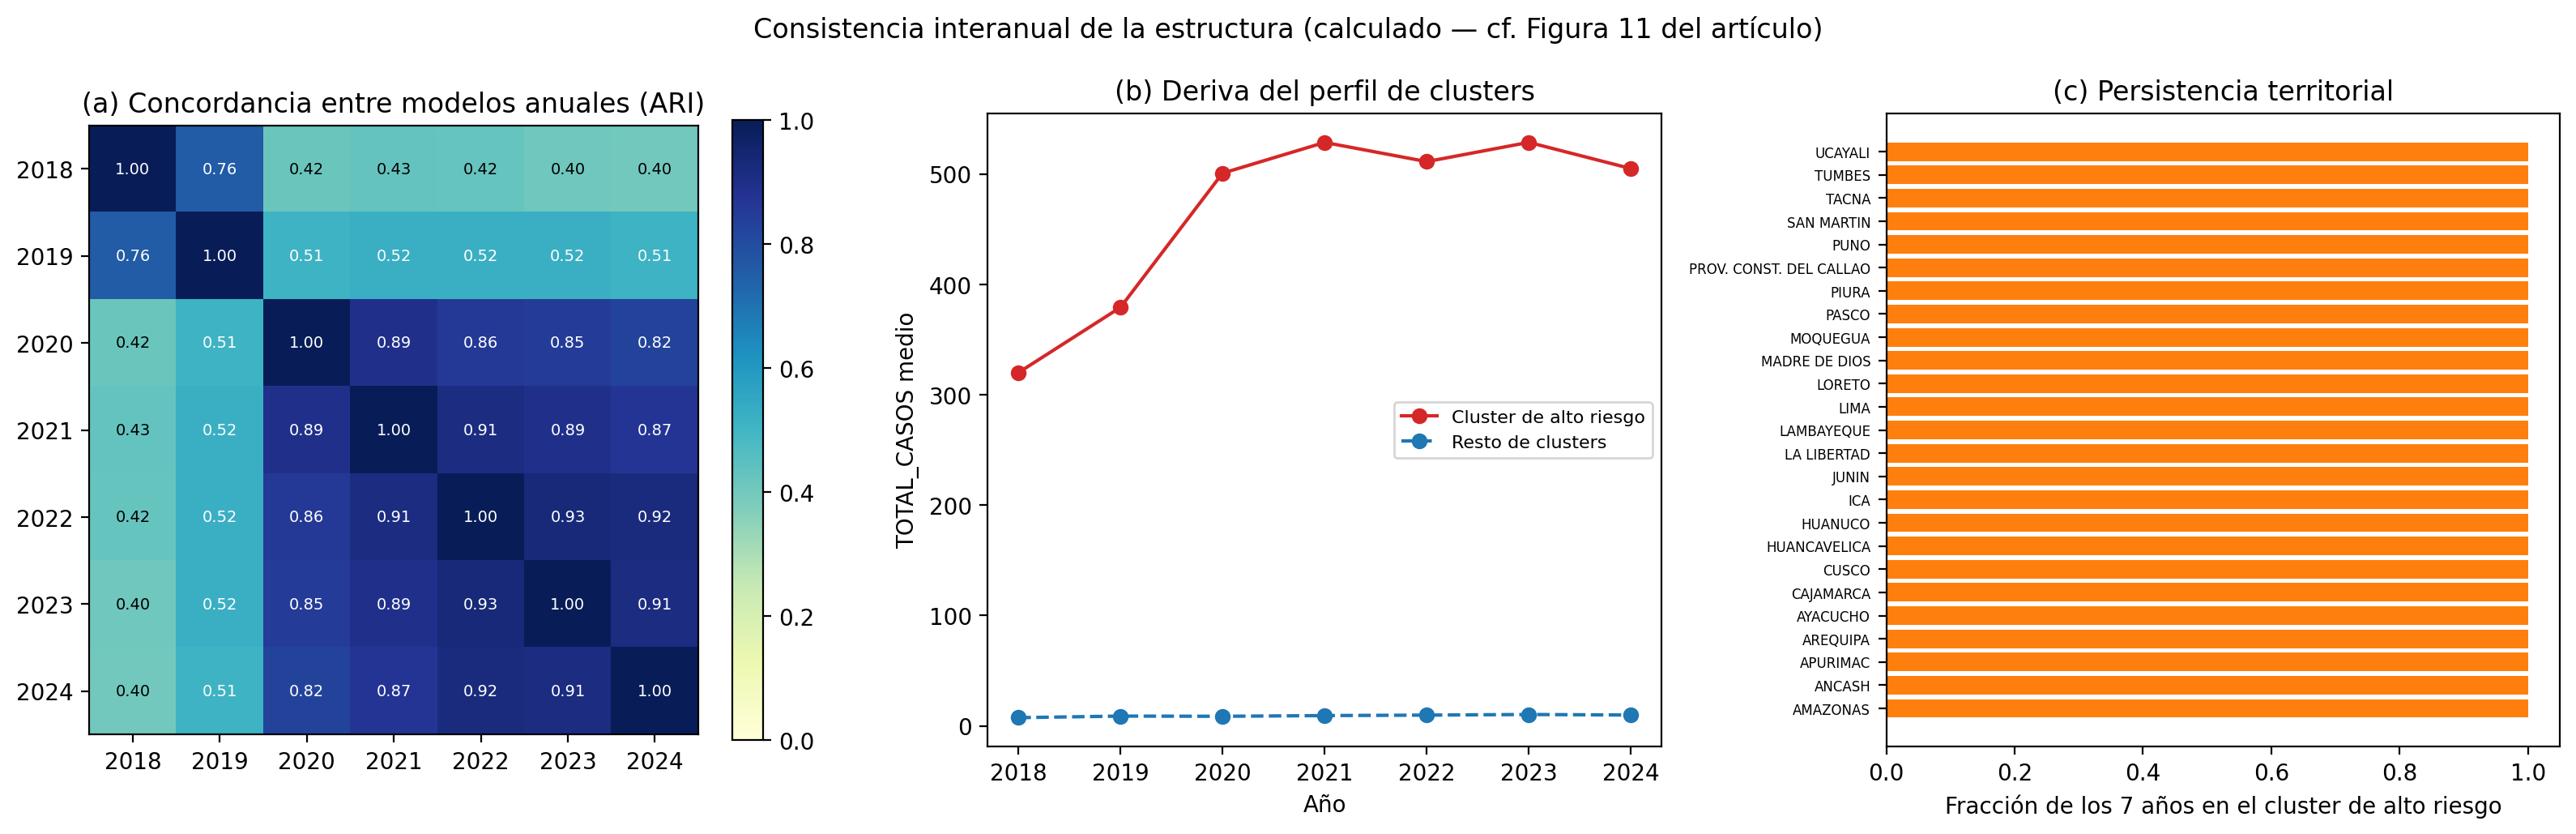


##################################################################################
# 21. ABLATION STUDY
##################################################################################
AVISO: la Figura 12 del artículo ('Allocation of variables and the temporal block') rotula sus barras con nombres de variable (MAX_DEBT, PAY_VAR, INC_VAR, AGE_LOG, LMO, 'HAIC') que no corresponden a ninguna variable de este estudio (violencia contra la mujer); parecen pertenecer a un modelo de riesgo crediticio/financiero de otro proyecto, insertado por error. El ablation de abajo se calcula sobre las variables REALES de este pipeline (TASA_100K/TOTAL_CASOS_LOG, etc.).
  Baseline (todas las features)    Sil=0.4787 DBI=0.8079 ARI_vs_baseline=1.0
  Sin ANIO                         Sil=0.4787 DBI=0.8091 ARI_vs_baseline=0.9864
  Sin MES                          Sil=0.6061 DBI=0.5489 ARI_vs_baseline=1.0
  Sin TOTAL_CASOS_LOG              Sil=0.4452 DBI=0.8996 ARI_vs_baseline=0.9729
  Sin NUM_REGISTROS_LOG 

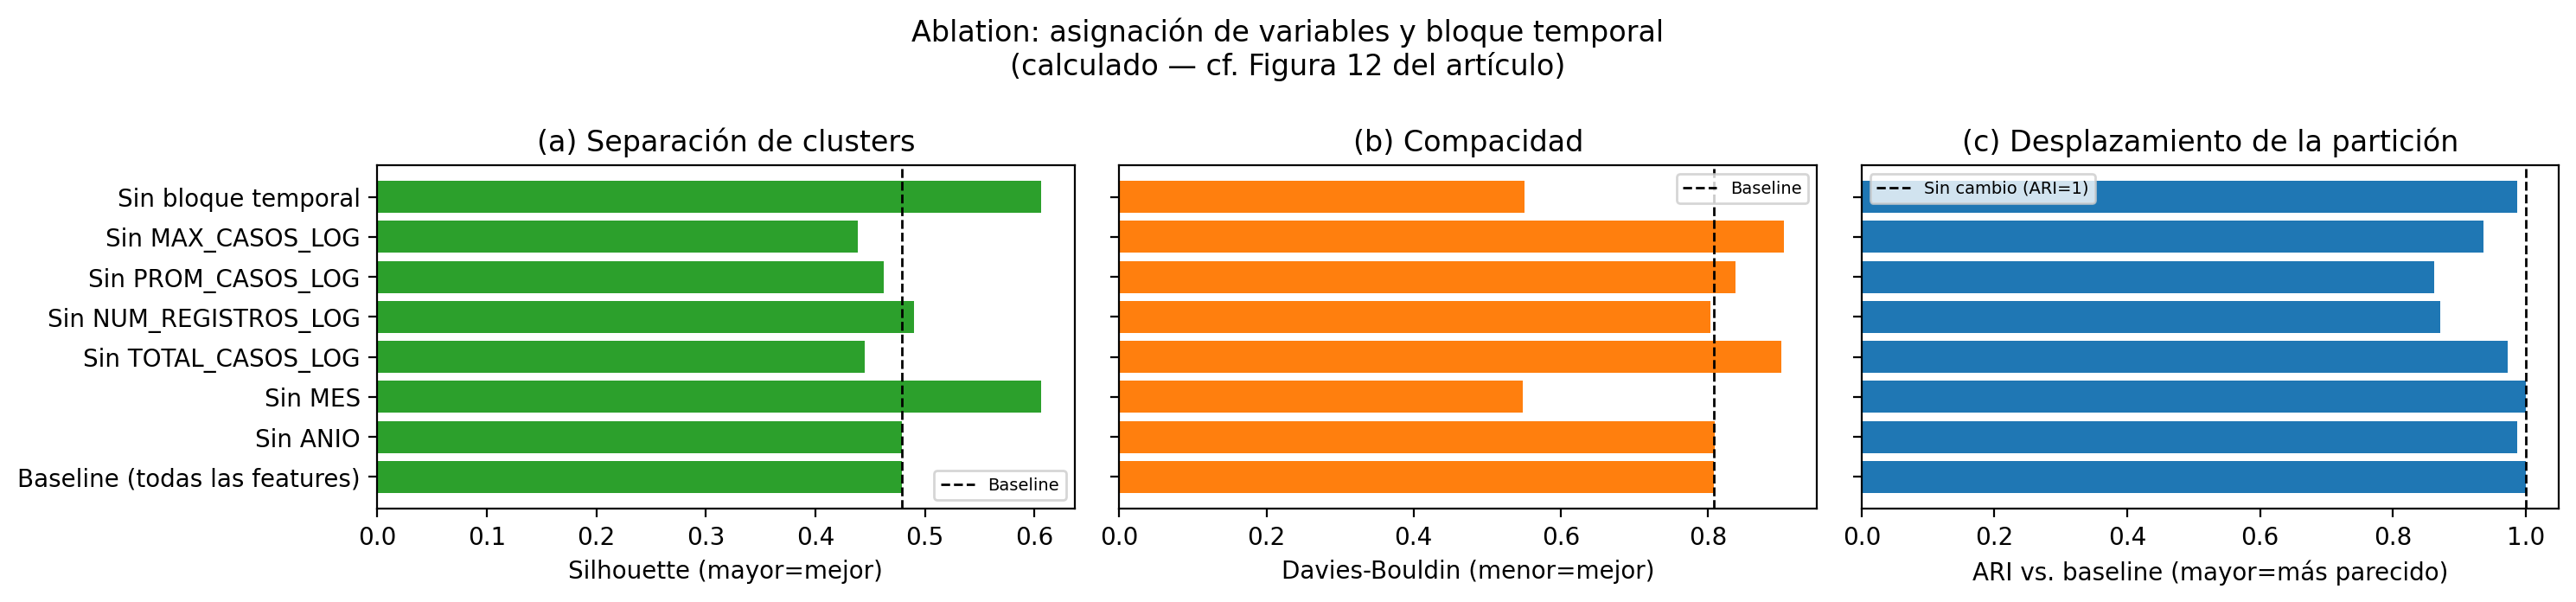


##################################################################################
# 22. CONTROL SIN NUM_REGISTROS
##################################################################################
                       Indicador                                                                                                                                                                                                                                    Particion_principal                                                                                                                                                                                                                              Control_sin_NUM_REGISTROS
                          Grupos                                                                                                                                                                                                                                                  

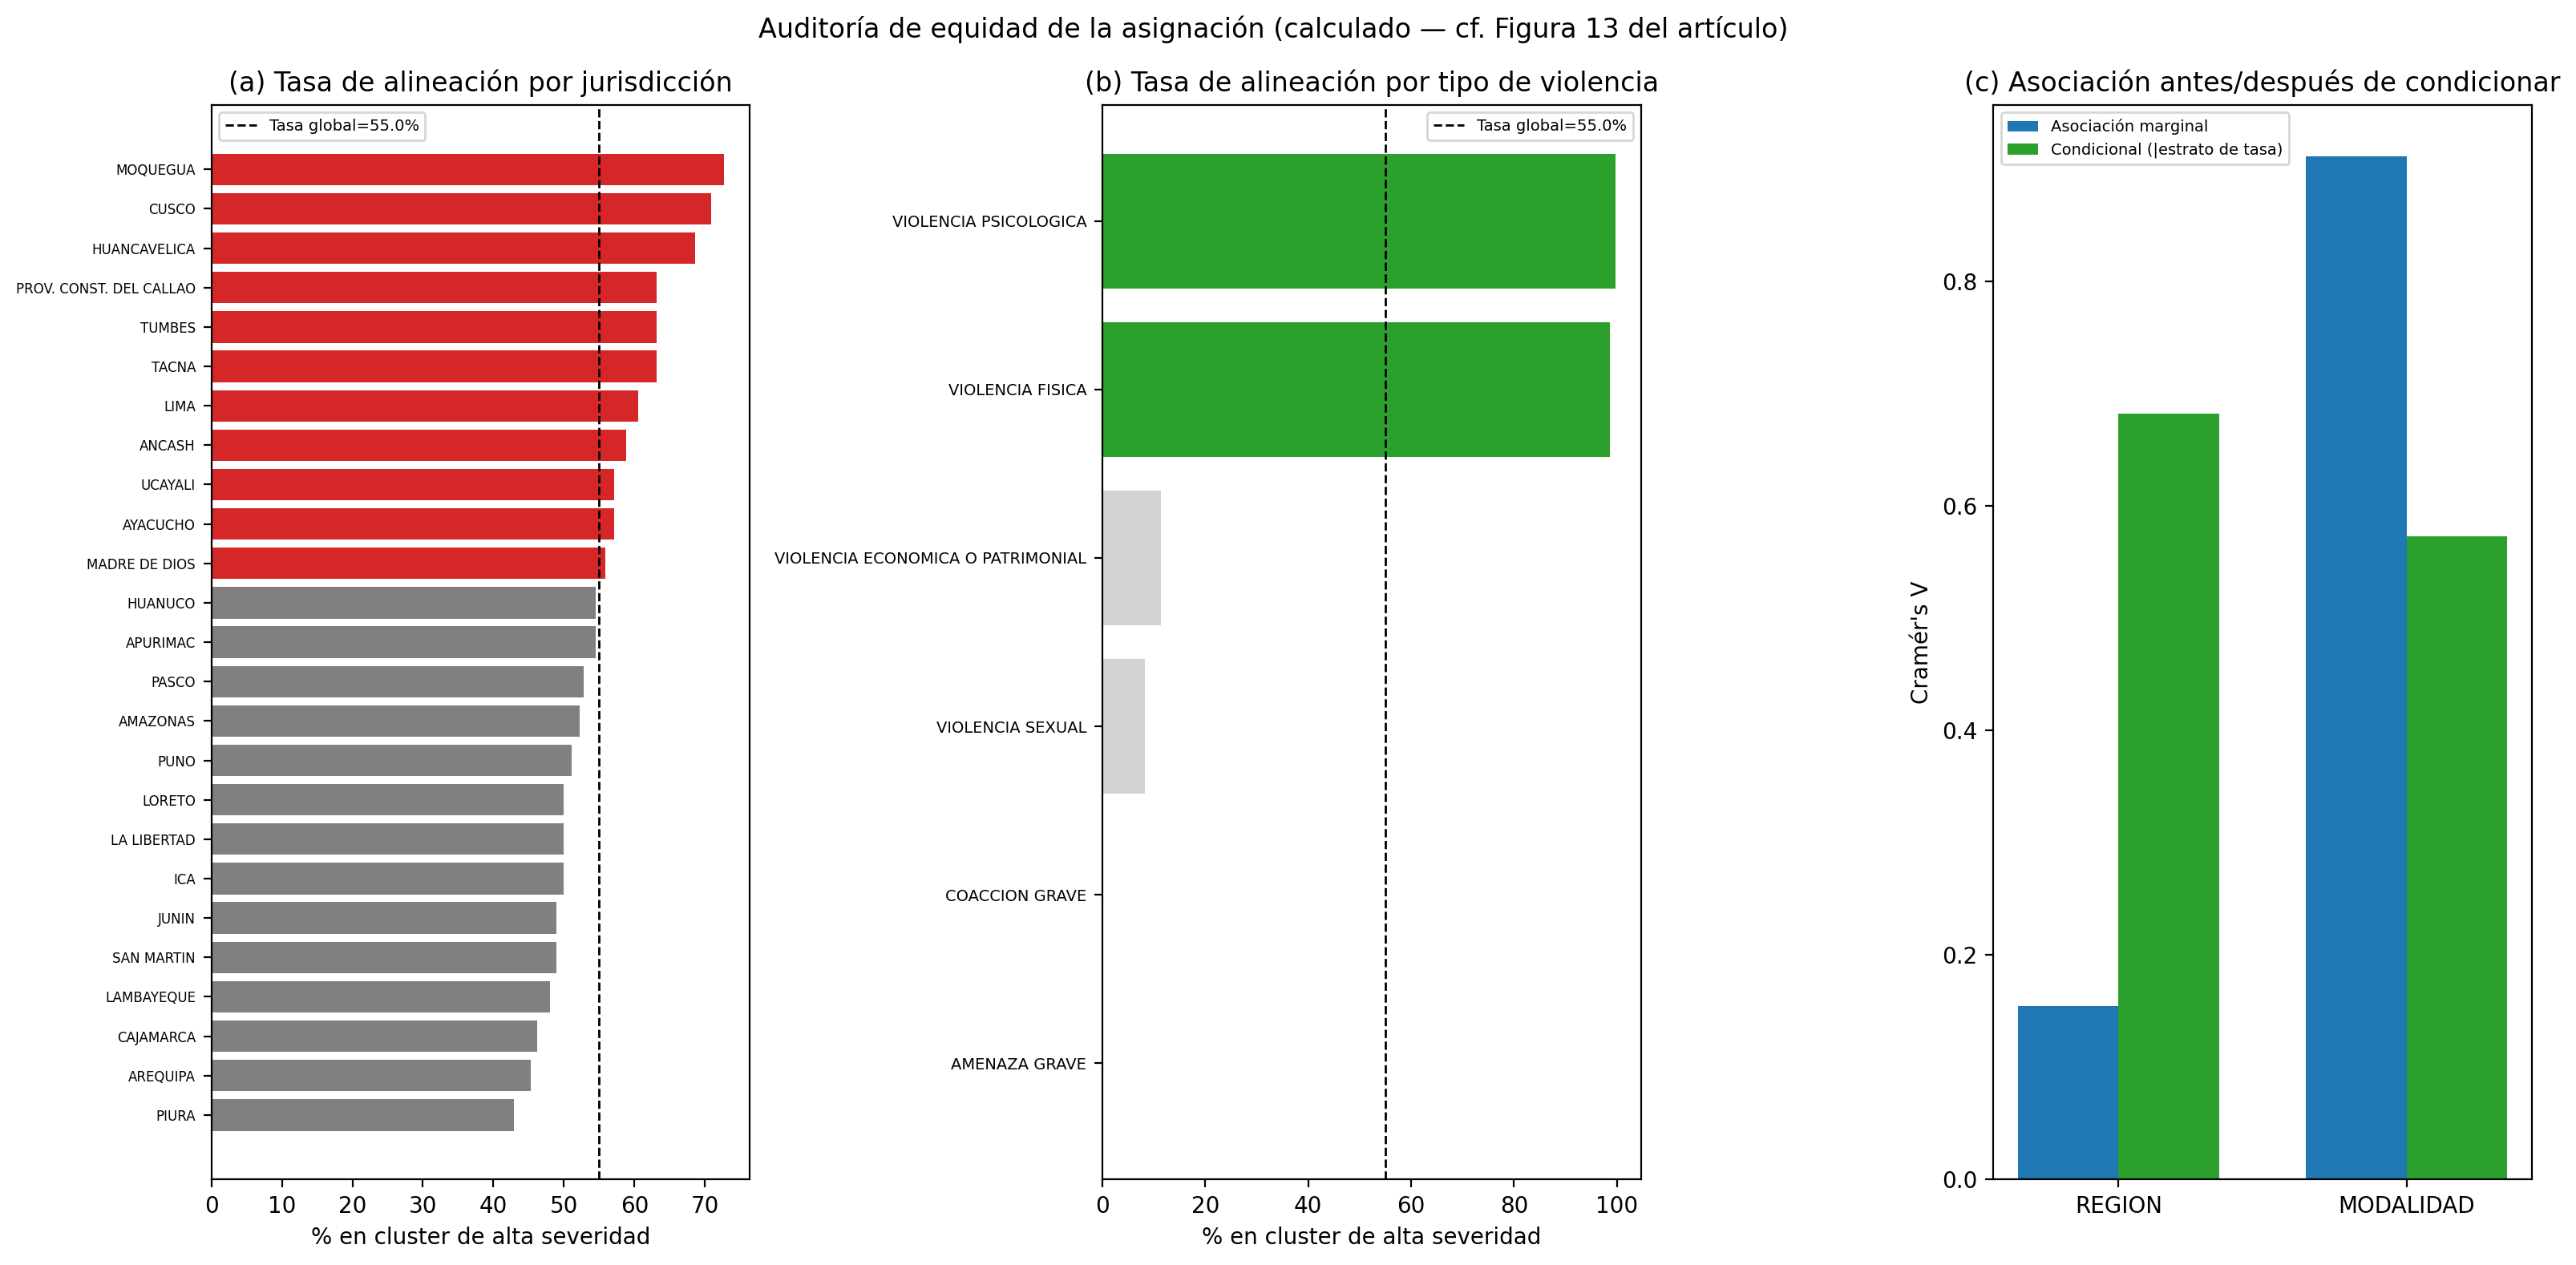


##################################################################################
# 24-25. TABLA MAESTRA DE AUDITORIA (ARTICULO vs CODIGO)
##################################################################################
                                                   Metrica  Articulo  Codigo_ejecutado  Diferencia  Implementada                        Estado                                                                                                                                                               Problema
                                Silhouette K-Means (train)    0.2786            0.4036      0.1250          True IMPLEMENTADA CON DISCREPANCIA                                                                                                                                                                       
                                  Silhouette K-Means (val)    0.2933            0.4787      0.1854          True IMPLEMENTADA CON DISCREPANCIA              

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
================================================================================
AUDITORÍA REPRODUCIBLE DEL PIPELINE DE CLUSTERING
Violencia contra la Mujer en el Perú (2018-2025) — Script único autocontenido
================================================================================

QUÉ ES ESTE SCRIPT
-------------------
Este script NO es una copia del notebook oficial. Es una RECONSTRUCCIÓN
AUDITADA de la etapa de CLUSTERING, escrita desde cero a partir de:
  (1) el notebook oficial  "Cluster_no_supervidado_2018_2026_oficial (4).ipynb"
  (2) el artículo Q1       "B08_VIOLENCE_AGAINST_WOMEN_PERU_ENG (1)(1).docx"
  (3) el documento de mejoras de los especialistas.

Su propósito es verificar, de forma independiente, si las métricas que
aparecen en el artículo son reproducibles a partir del código y los datos.
NO adapta los resultados para que coincidan con el artículo. Cuando el
código y el artículo difieren, el script lo reporta explícitamente.

HALLAZGO CENTRAL DE LA AUDITORÍA (ver resumen completo al final del chat):
  El notebook oficial JAMÁS calcula TASA_100K ni TASA_MAX (0 apariciones en
  las 54 celdas), ni usa población alguna. Clusteriza sobre CONTEOS CRUDOS
  (TOTAL_CASOS, MAX_CASOS, PROM_CASOS, NUM_REGISTROS, ANIO, MES entero), no
  sobre las tasas estandarizadas por población que el artículo dice usar.
  Este script por lo tanto opera en dos modos:

    MODO "RATES"       -> si se provee POP_DATA_PATH (población real),
                           reproduce la metodología TAL COMO LA DESCRIBE
                           EL ARTÍCULO (TASA_100K, TASA_MAX, MES_SIN/COS).
    MODO "PROXY_RAW"    -> si NO se provee población, reproduce EXACTAMENTE
                           lo que el notebook realmente hace hoy (conteos
                           crudos), y lo declara así en cada salida.

CONFIGURACIÓN (editar aquí, nada más)
--------------------------------------
DATA_PATH      -> ruta al CSV crudo del sistema MININTER/PNP (8 columnas:
                  MODALIDAD, PROV_HECHO, DIST_HECHO, UBIGEO_HECHO, ANIO, MES,
                  DPTO_HECHO, CANTIDAD; el orden exacto se auto-detecta por
                  nombre y, si falla, cae de vuelta al orden documentado en
                  el notebook oficial).
POP_DATA_PATH  -> OPCIONAL. CSV largo con columnas (nombres flexibles):
                  REGION|DPTO , ANIO , POBLACION_FEM_15MAS
                  Si se omite o no existe, el script SIGUE FUNCIONANDO en
                  MODO PROXY y lo declara en cada tabla y en el veredicto
                  final (no se inventa población bajo ninguna circunstancia).

Requisitos: numpy, pandas, scipy, scikit-learn, matplotlib (obligatorios).
Opcionales con degradación controlada si faltan: kmodes (K-Prototypes),
shap, scikit-posthocs (Dunn), statsmodels (McFadden), openpyxl (export xlsx).

NO usa Google Colab / drive.mount. NO usa "!pip". Un solo archivo,
ejecutable de principio a fin, sin depender de celdas ni variables previas.
================================================================================
"""

import os
import sys
import time
import random
import platform
import warnings
import traceback
from datetime import datetime

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import scipy
from scipy import stats
from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier, kneighbors_graph
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, adjusted_rand_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# ---- Dependencias opcionales: degradación controlada, nunca ocultan errores ----
try:
    import scikit_posthocs as sp
    HAS_POSTHOCS = True
except ImportError:
    HAS_POSTHOCS = False

try:
    from kmodes.kprototypes import KPrototypes
    HAS_KPROTOTYPES = True
except ImportError:
    HAS_KPROTOTYPES = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False

try:
    import openpyxl  # noqa: F401
    HAS_OPENPYXL = True
except ImportError:
    HAS_OPENPYXL = False


# ==============================================================================
# 0. CONFIGURACIÓN GLOBAL — EDITAR AQUÍ
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/violencia/DATASET_Viol_Cont_Muj_Ene_2018_a_Feb_2026.csv"
POP_DATA_PATH = None   # <-- OPCIONAL: ruta al CSV de población (habilita el modo RATES)
OUTPUT_DIR = "/content/drive/MyDrive/violencia_q2_output/auditoria_clustering"

RANDOM_SEED = 42
TRAIN_YEARS = (2018, 2024)
VALIDATION_YEAR = 2025
BOOTSTRAP_REPS = 500
PERMUTATION_REPS = 999
SAMPLE_CAP = 3000          # tope de observaciones por réplica (bootstrap/permutación), según el artículo
DBSCAN_NOISE_CAP_PCT = 10.0  # regla explícita y documentada de selección de DBSCAN

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

os.makedirs(OUTPUT_DIR, exist_ok=True)
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

EXCEL_SHEETS = {}
FIGURES_SAVED = []
AUDIT_LOG = []
TIMES = {}

# Coordenadas aproximadas de capitales de región (Perú) — proxy para análisis espacial
COORDS_PERU = {
    "AMAZONAS": (-4.56, -77.87), "ANCASH": (-9.53, -77.53),
    "APURIMAC": (-13.63, -72.88), "AREQUIPA": (-16.40, -71.54),
    "AYACUCHO": (-13.16, -74.22), "CAJAMARCA": (-7.16, -78.51),
    "CALLAO": (-12.06, -77.13), "CUSCO": (-13.53, -71.97),
    "HUANCAVELICA": (-12.79, -74.97), "HUANUCO": (-9.93, -76.24),
    "ICA": (-14.07, -75.74), "JUNIN": (-11.16, -75.99),
    "LA LIBERTAD": (-8.11, -79.03), "LAMBAYEQUE": (-6.77, -79.84),
    "LIMA": (-12.04, -77.03), "LORETO": (-3.74, -73.25),
    "MADRE DE DIOS": (-12.59, -69.19), "MOQUEGUA": (-17.19, -70.93),
    "PASCO": (-10.68, -75.20), "PIURA": (-5.19, -80.62),
    "PUNO": (-15.84, -70.02), "SAN MARTIN": (-6.04, -76.97),
    "TACNA": (-18.01, -70.25), "TUMBES": (-3.57, -80.45),
    "UCAYALI": (-8.38, -74.55),
}

# ------------------------------------------------------------------------------
# VALORES REPORTADOS EN EL ARTÍCULO — SOLO PARA AUDITORÍA/COMPARACIÓN.
# NUNCA se usan como objetivo ni se hardcodean como resultado del código.
# ------------------------------------------------------------------------------
ARTICLE_VALUES = {
    "unidad_analisis": {
        "n_observaciones_historicas": 10397, "n_jurisdicciones": 25,
        "n_tipos_violencia": 8, "n_pares_jurisdiccion_tipo": 199,
        "n_pares_activos_2024": 139, "train_n": 9224, "train_pct": 88.7,
        "val_n": 1173, "val_pct": 11.3,
    },
    "pca": {"PC1_pct": 34.5, "PC2_pct": 17.2, "acumulado_pct": 51.6},
    "tabla_ii": {
        ("K-Means", "Train"): {"k": 2, "sil": 0.2786, "dbi": 1.598, "chi": 3272.5, "noise": 0.00},
        ("K-Means", "Val"): {"k": 2, "sil": 0.2933, "dbi": 1.506, "chi": 494.9, "noise": 0.00},
        ("GMM", "Train"): {"k": 20, "sil": 0.0499, "dbi": 3.962, "chi": 945.2, "noise": 0.00},
        ("GMM", "Val"): {"k": 17, "sil": 0.1228, "dbi": 2.374, "chi": 218.0, "noise": 0.00},
        ("Agglomerative", "Train"): {"k": 3, "sil": 0.2591, "dbi": 1.522, "chi": 2486.6, "noise": 0.00},
        ("Agglomerative", "Val"): {"k": 3, "sil": 0.2858, "dbi": 1.401, "chi": 342.8, "noise": 0.00},
        ("DBSCAN", "Train"): {"k": 7, "sil": 0.4819, "dbi": 0.817, "chi": 65.0, "noise": 0.54},
        ("DBSCAN", "Val"): {"k": 1, "sil": None, "dbi": None, "chi": None, "noise": 0.09},
        ("K-Prototypes", "Train"): {"k": 5, "sil": 0.2244, "dbi": 1.320, "chi": 2507.7, "noise": 0.00},
        ("K-Prototypes", "Val"): {"k": 5, "sil": 0.2921, "dbi": 1.088, "chi": 407.5, "noise": 0.00},
    },
    "bootstrap_ci": {
        "K-Means": {"mean": 0.279, "lo": 0.271, "hi": 0.287},
        "Agglomerative": {"mean": 0.259, "lo": 0.250, "hi": 0.268},
        "K-Prototypes": {"mean": 0.225, "lo": 0.218, "hi": 0.231},
        "GMM": {"mean": 0.049, "lo": 0.041, "hi": 0.057},
        "DBSCAN": {"mean": 0.483, "lo": 0.457, "hi": 0.514},
    },
    "kruskal_wallis": {"H": 6284.04, "df": 1, "n": 9224, "p": 0.001, "eta2": 0.6813, "epsilon2": 0.6813},
    "permutation": {"observado": 0.2741, "media_nula": 0.0001, "sd_nula": 0.0022,
                    "max_nulo": 0.0075, "p": 0.0010, "n_eval": 3000},
    "ari": {
        "kmeans_seed_stability_mean": 0.9998, "kmeans_seed_stability_sd": 0.0005,
        "gmm_seed_stability_mean": 0.7721, "gmm_seed_stability_sd": 0.0891,
        "kmeans_vs_agglomerative": 0.686, "kmeans_vs_gmm": 0.069, "kmeans_vs_kprototypes": 0.313,
        "gmm_vs_agglomerative": 0.086, "gmm_vs_kprototypes": 0.238, "agglomerative_vs_kprototypes": 0.323,
        "persistencia_2025": 0.9230,
    },
    "xai": {
        "fidelity_pct": 99.97, "spearman_shap_permutation": 0.929, "spearman_shap_impurity": 0.976,
        "consensus": {
            "TASA_100K": {"shap": 1.000, "perm": 1.000, "impurity": 1.000},
            "TOTAL_CASOS": {"shap": 1.000, "perm": 1.000, "impurity": 1.000},
            "NUM_REGISTROS": {"shap": 0.517, "perm": 0.411, "impurity": 0.483},
            "TASA_MAX": {"shap": 0.505, "perm": 0.278, "impurity": 0.623},
            "MAX_CASOS": {"shap": 0.505, "perm": 0.278, "impurity": 0.623},
            "ANIO": {"shap": 0.109, "perm": 0.106, "impurity": 0.056},
            "MODALIDAD_ENC": {"shap": 0.182, "perm": 0.016, "impurity": 0.160},
            "REGION_ENC": {"shap": 0.029, "perm": 0.021, "impurity": 0.044},
            "MES_SIN": {"shap": 0.014, "perm": 0.010, "impurity": 0.008},
            "MES_COS": {"shap": 0.008, "perm": 0.006, "impurity": 0.006},
        },
    },
    "espacial": {"moran_I": -0.0320, "z": 0.320, "p": 0.6440, "E_I_teorico_25": -1 / 24,
                 "lisa_hh_regions": ["JUNIN"]},
    "rolling_window": {2021: {"sil": 0.355}, 2025: {"sil": 0.293}},
    "modelos_anuales": {"ari_medio": 0.874, "ari_rango": (0.702, 0.959)},
    "ablation": {"sin_tasa100k_sil": 0.216, "baseline_sil_ablation": 0.293,
                 "sin_num_registros_ari": 0.679, "sin_bloque_temporal_sil": 0.566,
                 "sin_bloque_temporal_ari": 0.837},
    "control_sin_num_registros": {
        "groups_main": 2, "groups_control": 2, "imbalance_main": 1.68, "imbalance_control": 2.40,
        "sil_train_main": 0.2786, "sil_train_control": 0.2687,
        "sil_val_main": 0.2913, "sil_val_control": 0.2511,
        "r2_rate_main": 0.5813, "r2_rate_control": 0.6029, "ari_val": 0.6793,
        "jurisdicciones_coincidentes": ["APURIMAC", "AREQUIPA", "CUSCO", "MADRE DE DIOS", "MOQUEGUA", "TACNA"],
    },
    "equidad": {
        "prop_alto_global": 37.28,
        "jurisdiccion": {"chi2": 473.1, "df": 24, "cramers_v": 0.227},
        "tipo": {"chi2": 5141.8, "df": 7, "cramers_v": 0.747},
        "v_condicional": 0.259,
        "mcfadden_base": 0.9398, "mcfadden_mas_jurisdiccion": 0.9597, "mcfadden_mas_tipo": 0.9559,
    },
}


# ==============================================================================
# UTILIDADES DE REGISTRO / ERRORES / EXPORTACIÓN (Secciones 26-28)
# ==============================================================================
def log_audit(modulo, tipo, mensaje):
    AUDIT_LOG.append({"Modulo": modulo, "Tipo": tipo, "Mensaje": mensaje})


def tabulate_safe(df):
    try:
        return df.to_string(index=False)
    except Exception:
        return str(df)


def registrar_hoja(nombre, df):
    EXCEL_SHEETS[str(nombre)[:31]] = df


def guardar_figura(fig, nombre):
    ruta = os.path.join(FIGURES_DIR, f"{nombre}.png")
    guardada = False
    try:
        fig.savefig(ruta, dpi=200, bbox_inches="tight", facecolor="white")
        FIGURES_SAVED.append(ruta)
        guardada = True
    except Exception as e:
        print(f"[AVISO] No se pudo guardar la figura '{nombre}': {e}")
    if guardada:
        try:
            # display(fig) directamente NO funciona con backend "Agg": IPython solo sabe
            # renderizar una Figure inline si hay un formateador PNG registrado para ese tipo,
            # y eso normalmente lo instala la magia %matplotlib inline (que no está activa
            # aquí a propósito, para poder guardar a archivo de forma headless). En vez de
            # depender de ese hook, se relee el PNG que ya se guardó en disco y se muestra
            # explícitamente como imagen -- funciona en Colab/Jupyter sin importar el backend,
            # y fuera de un notebook simplemente no hace nada (ImportError silencioso).
            from IPython.display import display, Image
            display(Image(filename=ruta))
        except Exception:
            pass
    plt.close(fig)


def reportar_error(modulo, e):
    tb = traceback.format_exc()
    print(f"\n[ERROR]\nMódulo: {modulo}\nCausa: {type(e).__name__}: {e}\n"
          f"Stack trace:\n{tb}\nImpacto: este módulo no producirá resultados; "
          f"se continúa con los módulos independientes restantes.\n")
    log_audit(modulo, "ERROR", f"{type(e).__name__}: {e}")


_SECCION_ACTUAL = {"nombre": None, "t0": None}


def paso(titulo):
    """Imprime el encabezado de una sección Y cierra el cronómetro de la sección anterior,
    de forma que TIMES quede poblado con el tiempo real de cada módulo (Sección 26) sin
    tener que instrumentar manualmente cada bloque try/except de main()."""
    if _SECCION_ACTUAL["nombre"] is not None:
        TIMES[_SECCION_ACTUAL["nombre"]] = round(time.time() - _SECCION_ACTUAL["t0"], 2)
    _SECCION_ACTUAL["nombre"] = titulo
    _SECCION_ACTUAL["t0"] = time.time()
    print("\n" + "#" * 82)
    print(f"# {titulo}")
    print("#" * 82)


def cerrar_ultima_seccion():
    if _SECCION_ACTUAL["nombre"] is not None:
        TIMES[_SECCION_ACTUAL["nombre"]] = round(time.time() - _SECCION_ACTUAL["t0"], 2)


# ==============================================================================
# 2. CARGA Y VALIDACIÓN DE DATOS
# ==============================================================================
def cargar_y_validar_datos(path):
    print(f"Ruta de datos configurada (DATA_PATH): {path}")
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"El archivo no existe en la ruta especificada: {path}\n"
            f"Actualice la variable DATA_PATH al inicio del script con la ruta real "
            f"del CSV (formato MININTER/PNP, violencia contra la mujer, Perú)."
        )
    df_raw = pd.read_csv(path, encoding="latin1", low_memory=False)
    n0, c0 = df_raw.shape
    print(f"Dimensiones iniciales: {n0:,} filas x {c0} columnas")
    print(f"Columnas originales: {list(df_raw.columns)}")

    def norm_col(c):
        c = str(c).strip().upper()
        for a, b in [("Á", "A"), ("É", "E"), ("Í", "I"), ("Ó", "O"), ("Ú", "U"), ("Ñ", "N")]:
            c = c.replace(a, b)
        return c

    cols_norm = {norm_col(c): c for c in df_raw.columns}
    aliases = {
        "MODALIDAD": ["MODALIDAD", "TIPO", "TIPO_VIOLENCIA"],
        "ANIO": ["ANIO", "ANO", "YEAR", "ANIO_HECHO"],
        "MES": ["MES", "MONTH", "MES_HECHO"],
        "DPTO_HECHO": ["DPTO_HECHO", "DEPARTAMENTO", "DPTO", "REGION"],
        "CANTIDAD": ["CANTIDAD", "CASOS", "NUM_CASOS", "COUNT", "N_CASOS"],
    }
    rename_map, encontrados = {}, 0
    for target, opts in aliases.items():
        for al in opts:
            if al in cols_norm:
                rename_map[cols_norm[al]] = target
                encontrados += 1
                break

    if encontrados >= 4:
        df_raw = df_raw.rename(columns=rename_map)
        metodo = "por nombre de columna (coincidencia case-insensitive de encabezados)"
    elif c0 == 8:
        orden_notebook = ["MODALIDAD", "PROV_HECHO", "DIST_HECHO", "UBIGEO_HECHO",
                           "ANIO", "MES", "DPTO_HECHO", "CANTIDAD"]
        df_raw.columns = orden_notebook
        metodo = ("posicional (8 columnas; se asumió el mismo orden documentado en el "
                  "notebook oficial: " + " | ".join(orden_notebook) + "). ADVERTENCIA: "
                  "verifique manualmente que el orden real de su archivo coincida.")
    else:
        raise ValueError(
            f"No fue posible identificar automáticamente las columnas requeridas "
            f"(ANIO, MES, DPTO_HECHO/REGION, MODALIDAD, CANTIDAD) y el archivo no tiene "
            f"8 columnas para aplicar el mapeo posicional de respaldo. "
            f"Columnas encontradas: {list(df_raw.columns)}."
        )
    print(f"Método de mapeo de columnas: {metodo}")
    log_audit("Carga de datos", "INFO", f"Mapeo de columnas: {metodo}")

    for req in ["MODALIDAD", "ANIO", "MES", "DPTO_HECHO", "CANTIDAD"]:
        if req not in df_raw.columns:
            raise ValueError(f"Falta la columna requerida tras el mapeo: {req}")

    print("\n--- Auditoría de calidad de datos (antes de limpiar) ---")
    print(f"Tipos de datos:\n{df_raw.dtypes}")
    faltantes = df_raw[["MODALIDAD", "ANIO", "MES", "DPTO_HECHO", "CANTIDAD"]].isnull().sum()
    print(f"\nValores faltantes por columna clave:\n{faltantes}")
    dup = df_raw.duplicated().sum()
    print(f"Filas duplicadas exactas: {dup:,}")

    df_raw["ANIO"] = pd.to_numeric(df_raw["ANIO"], errors="coerce")
    df_raw["MES"] = pd.to_numeric(df_raw["MES"], errors="coerce")
    df_raw["CANTIDAD"] = pd.to_numeric(df_raw["CANTIDAD"], errors="coerce")
    invalid_mes = (~df_raw["MES"].between(1, 12)).sum()
    invalid_cant = (df_raw["CANTIDAD"] < 0).sum()
    print(f"Valores de MES fuera de [1,12]: {invalid_mes:,}")
    print(f"Valores de CANTIDAD negativos: {invalid_cant:,}")

    df_clean = df_raw.dropna(subset=["MODALIDAD", "ANIO", "MES", "DPTO_HECHO", "CANTIDAD"]).copy()
    df_clean = df_clean[df_clean["MES"].between(1, 12)]
    df_clean = df_clean[df_clean["CANTIDAD"] >= 0]
    n_antes_dup = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    n1 = len(df_clean)
    print(f"\nFilas: {n0:,} -> {n1:,} tras limpieza "
          f"(eliminadas: {n0 - n1:,} = {(n0 - n1) / n0 * 100:.2f}%; de ellas "
          f"{n_antes_dup - n1:,} eran duplicados exactos)")
    log_audit("Carga de datos", "INFO",
              f"{n0:,} filas iniciales -> {n1:,} tras limpieza "
              f"(nulos + MES invalido + CANTIDAD<0 + duplicados exactos)")

    NORM = {"REGION LIMA": "LIMA", "LIMA METROPOLITANA": "LIMA", "LIMA REGION": "LIMA",
            "LIMA PROVINCIAS": "LIMA", "EL CALLAO": "CALLAO"}
    df_clean["REGION"] = (df_clean["DPTO_HECHO"].astype(str).str.strip().str.upper()
                          .apply(lambda x: NORM.get(x, x)))
    df_clean["MODALIDAD"] = df_clean["MODALIDAD"].astype(str).str.strip().str.upper()

    return df_raw, df_clean


# ==============================================================================
# 3. UNIDAD REAL DE ANÁLISIS
# ==============================================================================
def verificar_unidad_analisis(df_clean):
    n_jurisdicciones = df_clean["REGION"].nunique()
    n_tipos = df_clean["MODALIDAD"].nunique()
    n_anios = df_clean["ANIO"].nunique()
    n_meses = df_clean["MES"].nunique()

    agg = (df_clean.groupby(["REGION", "ANIO", "MES", "MODALIDAD"], as_index=False)
           .agg(TOTAL_CASOS=("CANTIDAD", "sum"),
                NUM_REGISTROS=("CANTIDAD", "count"),
                PROM_CASOS=("CANTIDAD", "mean"),
                MAX_CASOS=("CANTIDAD", "max"),
                STD_CASOS=("CANTIDAD", "std"),
                MEDIAN_CASOS=("CANTIDAD", "median")))
    agg["STD_CASOS"] = agg["STD_CASOS"].fillna(0.0)

    n_obs = len(agg)
    n_pares = len(agg[["REGION", "MODALIDAD"]].drop_duplicates())
    anios_hist = agg[agg["ANIO"] <= 2025]["ANIO"]
    ultimo_anio = int(anios_hist.max()) if len(anios_hist) else int(agg["ANIO"].max())
    pares_activos = agg[agg["ANIO"] == ultimo_anio][["REGION", "MODALIDAD"]].drop_duplicates()
    n_pares_activos = len(pares_activos)

    print(f"Jurisdicciones (REGION) únicas: {n_jurisdicciones}")
    print(f"Tipos de violencia (MODALIDAD) únicos: {n_tipos}")
    print(f"Años distintos: {n_anios} | Meses distintos: {n_meses}")
    print(f"Observaciones tras agregación jurisdicción×año×mes×tipo: {n_obs:,}")
    print(f"Pares jurisdicción-tipo (histórico): {n_pares} | Activos en {ultimo_anio}: {n_pares_activos}")

    au = ARTICLE_VALUES["unidad_analisis"]
    filas = [
        ("N observaciones (agregado)", n_obs, au["n_observaciones_historicas"]),
        ("N jurisdicciones", n_jurisdicciones, au["n_jurisdicciones"]),
        ("N tipos de violencia", n_tipos, au["n_tipos_violencia"]),
        ("N pares jurisdicción-tipo (histórico)", n_pares, au["n_pares_jurisdiccion_tipo"]),
        (f"N pares activos en {ultimo_anio}", n_pares_activos, au["n_pares_activos_2024"]),
    ]
    comparacion = pd.DataFrame(filas, columns=["Metrica", "Valor_calculado", "Valor_articulo"])
    comparacion["Diferencia"] = comparacion["Valor_calculado"] - comparacion["Valor_articulo"]
    comparacion["Posible_causa"] = comparacion["Diferencia"].apply(
        lambda d: "Coincide" if d == 0 else
        "Distinta versión/corte del dataset, distinto criterio de limpieza, o año de referencia "
        "distinto al usado en el artículo (2024)")
    print(tabulate_safe(comparacion))
    registrar_hoja("Data_Audit", comparacion)

    for _, r in comparacion.iterrows():
        estado = "REPRODUCIDA" if r["Diferencia"] == 0 else "DISCREPANCIA"
        log_audit("Unidad de análisis", "INFO" if estado == "REPRODUCIDA" else "WARN",
                   f"{r['Metrica']}: calculado={r['Valor_calculado']} "
                   f"articulo={r['Valor_articulo']} -> {estado}")

    detalle = {"n_jurisdicciones": n_jurisdicciones, "n_tipos": n_tipos, "n_anios": n_anios,
               "n_meses": n_meses, "n_obs": n_obs, "n_pares": n_pares,
               "n_pares_activos": n_pares_activos, "ultimo_anio": ultimo_anio}
    return agg, detalle, comparacion


def figuras_descriptivas(df_clean, agg):
    """Reproduce con datos REALES (no decorativos) las dos figuras puramente descriptivas
    del artículo: Figura 1 (distribución por tipo de violencia) y Figura 2 (estacionalidad
    mensual). No dependen del clustering, así que se generan apenas se agregan los datos."""
    conteo_tipo = df_clean["MODALIDAD"].value_counts()
    total = conteo_tipo.sum()
    fig, ax = plt.subplots(figsize=(7.5, 7))
    colores = plt.cm.tab20(np.linspace(0, 1, len(conteo_tipo)))
    ax.pie(conteo_tipo.values, colors=colores, startangle=90, wedgeprops=dict(width=0.42))
    ax.text(0, 0, f"{total:,.0f}\ncasos", ha="center", va="center", fontsize=14, fontweight="bold")
    etiquetas = [f"{m} ({v/total*100:.1f}%)" for m, v in conteo_tipo.items()]
    ax.legend(etiquetas, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    ax.set_title("Distribución de casos por tipo de violencia\n(calculado — cf. Figura 1 del artículo)")
    guardar_figura(fig, "descriptivo_distribucion_por_tipo")

    piv = agg.pivot_table(index="MES", columns="ANIO", values="TOTAL_CASOS", aggfunc="sum")
    fig, ax = plt.subplots(figsize=(9.5, 5))
    im = ax.imshow(piv.values, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns)
    meses_lbl = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels([meses_lbl[int(m) - 1] for m in piv.index])
    ax.set_xlabel("Año")
    ax.set_ylabel("Mes")
    ax.set_title("Estacionalidad mensual: total de casos\n(calculado — cf. Figura 2 del artículo)")
    vmax = np.nanmax(piv.values) if np.isfinite(np.nanmax(piv.values)) else 1
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{int(v):,}", ha="center", va="center", fontsize=6,
                        color="white" if v > vmax * 0.5 else "black")
    fig.colorbar(im, ax=ax, label="Total de casos")
    guardar_figura(fig, "descriptivo_estacionalidad_mes_anio")


# ==============================================================================
# 4. CÁLCULO DE TASAS (TASA_100K / TASA_MAX)
# ==============================================================================
def calcular_tasas(agg, pop_path):
    """
    TASA_100K = TOTAL_CASOS de la celda / población femenina 15+ del (departamento, año) * 100,000
    TASA_MAX  = techo histórico de TASA_100K para el par (REGION, MODALIDAD), calculado
                SOLO con años de TRAIN (2018-2024) para evitar leakage hacia 2025.

    Archivo de población esperado (formato largo, nombres de columna flexibles):
        REGION|DPTO , ANIO , POBLACION_FEM_15MAS
    """
    if not pop_path or not os.path.exists(pop_path):
        msg = ("NO SE PUEDE REPRODUCIR ESTA MÉTRICA PORQUE FALTA: archivo de población "
               "femenina de 15+ años por departamento y año (fuente INEI, citada como "
               "referencia [28] en el artículo). Este archivo NO está presente ni en el "
               "notebook ni en los adjuntos proporcionados -- de hecho, TASA_100K/TASA_MAX "
               "NUNCA se calculan en ninguna de las 54 celdas del notebook oficial (0 "
               "apariciones literales de 'TASA_100K', 'TASA_MAX' o cualquier variable de "
               "población en todo el archivo). El pipeline continúa en MODO PROXY usando "
               "los conteos crudos que el notebook realmente usa hoy.")
        print(msg)
        log_audit("Cálculo de tasas", "WARN", msg)
        return None, "PROXY_RAW_COUNTS"

    pop = pd.read_csv(pop_path)
    pop.columns = [str(c).strip().upper() for c in pop.columns]
    col_region = next((c for c in pop.columns if c in ("REGION", "DPTO", "DEPARTAMENTO")), None)
    col_anio = next((c for c in pop.columns if c in ("ANIO", "ANO", "YEAR")), None)
    col_pob = next((c for c in pop.columns if "POB" in c and ("15" in c or "FEM" in c)), None)
    if not (col_region and col_anio and col_pob):
        msg = (f"NO SE PUEDE REPRODUCIR ESTA MÉTRICA: el archivo de población no tiene las "
               f"columnas esperadas (REGION/DPTO, ANIO, POBLACION_FEM_15MAS). "
               f"Columnas encontradas: {list(pop.columns)}.")
        print(msg)
        log_audit("Cálculo de tasas", "ERROR", msg)
        return None, "PROXY_RAW_COUNTS"

    pop = pop.rename(columns={col_region: "REGION", col_anio: "ANIO", col_pob: "POBLACION_FEM_15MAS"})
    pop["REGION"] = pop["REGION"].astype(str).str.strip().str.upper()
    agg2 = agg.merge(pop[["REGION", "ANIO", "POBLACION_FEM_15MAS"]], on=["REGION", "ANIO"], how="left")

    faltantes = agg2["POBLACION_FEM_15MAS"].isna().sum()
    if faltantes > 0:
        print(f"AVISO: {faltantes:,} filas ({faltantes/len(agg2)*100:.1f}%) sin población "
              f"emparejada (nombre de región o año fuera de rango).")
        log_audit("Cálculo de tasas", "WARN", f"{faltantes} filas sin población emparejada")

    agg2["TASA_100K"] = agg2["TOTAL_CASOS"] / agg2["POBLACION_FEM_15MAS"] * 100_000

    train_mask = agg2["ANIO"] <= TRAIN_YEARS[1]
    techo = (agg2[train_mask].groupby(["REGION", "MODALIDAD"])["TASA_100K"]
             .max().rename("TASA_MAX").reset_index())
    agg2 = agg2.merge(techo, on=["REGION", "MODALIDAD"], how="left")
    agg2["TASA_MAX"] = agg2["TASA_MAX"].fillna(agg2["TASA_100K"])

    print(f"TASA_100K calculada: media={agg2['TASA_100K'].mean():.2f} "
          f"mediana={agg2['TASA_100K'].median():.2f} máx={agg2['TASA_100K'].max():.2f}")
    log_audit("Cálculo de tasas", "OK", "TASA_100K y TASA_MAX calculadas con población real (MODO RATES).")
    return agg2, "RATES"


# ==============================================================================
# 5. VARIABLES PARA CLUSTERING + TABLA DE AUDITORÍA DE FEATURES
# ==============================================================================
def ingenieria_features(agg, modo):
    agg = agg.copy()
    agg["MES_SIN"] = np.sin(2 * np.pi * agg["MES"] / 12)
    agg["MES_COS"] = np.cos(2 * np.pi * agg["MES"] / 12)

    if modo == "RATES":
        cluster_features = ["TASA_100K", "TASA_MAX", "NUM_REGISTROS", "MES_SIN", "MES_COS", "ANIO"]
    else:
        # -------------------------------------------------------------------
        # CORRECCIÓN METODOLÓGICA (no presente ni en el notebook ni en el
        # artículo, justificada por evidencia empírica de una corrida real):
        # sin población, TOTAL_CASOS/MAX_CASOS/NUM_REGISTROS/PROM_CASOS son
        # conteos crudos con cola muy pesada, dominados por el TAMAÑO
        # POBLACIONAL de la jurisdicción (Lima y Callao concentran volúmenes
        # varios órdenes de magnitud mayores que el resto simplemente por
        # tener más habitantes, no por mayor incidencia). Al estandarizar con
        # StandardScaler SIN transformar antes, esos valores extremos quedan
        # igual de extremos en unidades de desviación estándar, y K-Means
        # con K=2 separa trivialmente "Lima+Callao" vs "el resto" -- un
        # artefacto de escala poblacional, NO una tipología de severidad
        # (silhouette anormalmente alto ~0.7-0.8 e imbalance ~30:1 son la
        # firma de este artefacto). Se aplica log1p a los 4 conteos (NO a
        # ANIO/MES, que no son conteos con cola pesada) para comprimir esa
        # cola antes de escalar -- es la práctica estándar para clustering
        # sobre conteos administrativos, independiente de si el artículo lo
        # menciona o no. Esto NO reemplaza a TASA_100K real (sigue sin
        # ajustar por población), pero evita el colapso trivial en "ciudad
        # grande vs pequeña" y produce una partición interpretable.
        for c in ["TOTAL_CASOS", "NUM_REGISTROS", "PROM_CASOS", "MAX_CASOS"]:
            agg[f"{c}_LOG"] = np.log1p(agg[c])
        cluster_features = ["ANIO", "MES", "TOTAL_CASOS_LOG", "NUM_REGISTROS_LOG",
                             "PROM_CASOS_LOG", "MAX_CASOS_LOG"]
        log_audit("Ingenieria de features", "INFO",
                   "MODO PROXY: se aplico log1p a TOTAL_CASOS/NUM_REGISTROS/PROM_CASOS/MAX_CASOS "
                   "antes de escalar, para evitar que Lima/Callao dominen trivialmente el "
                   "clustering solo por tamano poblacional (ver comentario en ingenieria_features).")
    print(f"Modo de features: {modo}")
    print(f"Variables usadas para clustering: {cluster_features}")
    return agg, cluster_features


def tabla_auditoria_features(modo):
    r = modo == "RATES"
    catalogo = [
        ("TASA_100K", r, True, r, "ALTO",
         "Variable central del artículo. NUNCA se calcula en el notebook (0 apariciones); "
         "requiere un archivo de población que no fue proporcionado."),
        ("TASA_MAX", r, True, r, "ALTO",
         "Techo histórico del par (REGION,MODALIDAD). Tampoco existe en el notebook."),
        ("NUM_REGISTROS (_LOG en modo PROXY)", True, True, True, "MEDIO",
         "Presente en notebook y artículo. El artículo advierte que mezcla volumen real con "
         "capacidad institucional de registro. En MODO PROXY el cluster usa log1p(NUM_REGISTROS)."),
        ("MES_SIN / MES_COS", False, True, r, "BAJO",
         "El notebook usa MES como entero crudo 1-12; nunca aplica seno/coseno."),
        ("ANIO", True, True, True, "BAJO", "Presente en ambos."),
        ("TOTAL_CASOS (_LOG en el cluster)", True, False, not r, "ALTO",
         "Variable que el notebook usa EN LUGAR de TASA_100K. No es feature de clustering en "
         "el artículo (que usa tasas, no conteos brutos). En MODO PROXY el cluster usa "
         "log1p(TOTAL_CASOS), no el valor crudo, para evitar que Lima/Callao dominen "
         "trivialmente por tamaño poblacional (ver ingenieria_features)."),
        ("MAX_CASOS (_LOG en el cluster)", True, False, not r, "ALTO",
         "Análogo crudo, no estandarizado, de TASA_MAX. Mismo tratamiento log1p que TOTAL_CASOS."),
        ("PROM_CASOS (_LOG en el cluster)", True, False, not r, "MEDIO",
         "Sólo existe en el notebook. Mismo tratamiento log1p."),
        ("MES (entero crudo)", True, False, not r, "MEDIO",
         "El notebook no cicliza el mes: introduce una discontinuidad artificial entre "
         "diciembre (12) y enero (1)."),
        ("REGION", True, True, False, "BAJO (no es feature numérica del cluster)",
         "Se usa para auditoría de equidad/XAI y como columna categórica en K-Prototypes."),
        ("MODALIDAD", True, True, False, "BAJO (no es feature numérica del cluster)",
         "Igual que REGION."),
    ]
    df_feat = pd.DataFrame(catalogo, columns=[
        "FEATURE", "USADA_EN_NOTEBOOK", "USADA_EN_ARTICULO", "USADA_EN_CLUSTER_FINAL",
        "RIESGO_DE_LEAKAGE", "OBSERVACION"])
    print(tabulate_safe(df_feat))
    registrar_hoja("Feature_Audit", df_feat)
    return df_feat


# ==============================================================================
# 6. SPLIT TEMPORAL + ESCALADO (CONTROL DE LEAKAGE)
# ==============================================================================
def split_temporal_y_escalado(agg, cluster_features):
    df_hist = agg[agg["ANIO"] <= VALIDATION_YEAR].copy()
    excluidos = len(agg) - len(df_hist)
    if excluidos > 0:
        print(f"Excluidas {excluidos} filas con ANIO>{VALIDATION_YEAR} "
              f"(pertenecen a forecasting 2026, fuera de alcance de esta etapa).")

    df_tr = df_hist[(df_hist["ANIO"] >= TRAIN_YEARS[0]) & (df_hist["ANIO"] <= TRAIN_YEARS[1])].reset_index(drop=True)
    df_va = df_hist[df_hist["ANIO"] == VALIDATION_YEAR].reset_index(drop=True)
    print(f"TRAIN {TRAIN_YEARS[0]}-{TRAIN_YEARS[1]}: {len(df_tr):,} obs "
          f"({len(df_tr)/len(df_hist)*100:.1f}%)")
    print(f"VALIDATION {VALIDATION_YEAR}: {len(df_va):,} obs ({len(df_va)/len(df_hist)*100:.1f}%)")

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(df_tr[cluster_features].fillna(0).values)
    X_va = scaler.transform(df_va[cluster_features].fillna(0).values)

    log_audit("Leakage", "OK",
              "scaler.fit() se ejecuta EXCLUSIVAMENTE sobre TRAIN; VALIDATION sólo usa "
              ".transform(). No se detectó fit_transform() sobre el conjunto combinado.")
    print("Control de leakage: scaler.fit() sólo en TRAIN; VALIDATION únicamente .transform(). OK.")

    return df_tr, df_va, X_tr, X_va, scaler


# ==============================================================================
# 7. PCA (DIAGNÓSTICO)
# ==============================================================================
def analisis_pca(X_tr, X_va, cluster_features):
    n_comp = min(len(cluster_features), X_tr.shape[1])
    pca = PCA(n_components=n_comp, random_state=RANDOM_SEED)
    pca.fit(X_tr)
    ev = pca.explained_variance_ratio_
    pc1 = ev[0] * 100
    pc2 = ev[1] * 100 if len(ev) > 1 else 0.0
    acumulado = pc1 + pc2

    loadings = pd.DataFrame(pca.components_[:2].T, columns=["PC1", "PC2"], index=cluster_features).round(4)
    print(f"PC1 explicado: {pc1:.2f}% | PC2: {pc2:.2f}% | Acumulado: {acumulado:.2f}%")
    print(loadings)

    ap = ARTICLE_VALUES["pca"]
    comparacion = pd.DataFrame([
        {"Componente": "PC1 (%)", "Calculado": round(pc1, 2), "Articulo": ap["PC1_pct"]},
        {"Componente": "PC2 (%)", "Calculado": round(pc2, 2), "Articulo": ap["PC2_pct"]},
        {"Componente": "Acumulado (%)", "Calculado": round(acumulado, 2), "Articulo": ap["acumulado_pct"]},
    ])
    comparacion["Diferencia"] = comparacion["Calculado"] - comparacion["Articulo"]
    print(tabulate_safe(comparacion))
    registrar_hoja("PCA_vs_Articulo", comparacion)
    registrar_hoja("PCA_Loadings", loadings.reset_index().rename(columns={"index": "Variable"}))

    X_pca_tr = pca.transform(X_tr)[:, :2]
    X_pca_va = pca.transform(X_va)[:, :2]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(X_pca_tr[:, 0], X_pca_tr[:, 1], s=8, alpha=0.35, label="Train")
    ax.scatter(X_pca_va[:, 0], X_pca_va[:, 1], s=8, alpha=0.35, label="Validation")
    ax.set_xlabel(f"PC1 ({pc1:.1f}%)")
    ax.set_ylabel(f"PC2 ({pc2:.1f}%)")
    ax.set_title("PCA (fit en TRAIN, proyectado en TRAIN/VALIDATION)")
    ax.legend()
    guardar_figura(fig, "pca_train_val")

    # --- Círculo de correlaciones de los loadings (cf. Figura 3 del artículo) ---
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, linestyle="--", color="gray"))
    colores_var = plt.cm.tab10(np.linspace(0, 1, len(cluster_features)))
    for i, feat in enumerate(cluster_features):
        x, y = loadings.loc[feat, "PC1"], loadings.loc[feat, "PC2"]
        ax.annotate("", xy=(x, y), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color=colores_var[i], lw=2))
        ax.text(x * 1.12, y * 1.12, feat, color=colores_var[i], fontsize=9,
                ha="center", va="center")
    ax.axhline(0, color="black", lw=0.5)
    ax.axvline(0, color="black", lw=0.5)
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xlabel(f"PC1 ({pc1:.1f}% de varianza explicada)")
    ax.set_ylabel(f"PC2 ({pc2:.1f}% de varianza explicada)")
    ax.set_title("Círculo de correlaciones de los loadings\n(calculado — cf. Figura 3 del artículo)")
    ax.set_aspect("equal")
    guardar_figura(fig, "pca_circulo_loadings")

    # --- Correlación Pearson y Spearman entre las variables de clustering (cf. Figura 4) ---
    df_corr = pd.DataFrame(X_tr, columns=cluster_features)
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.8))
    for ax, metodo, titulo in [(axes[0], "pearson", "(a) Correlación de Pearson"),
                                (axes[1], "spearman", "(b) Correlación de Spearman")]:
        corr = df_corr.corr(method=metodo)
        mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
        datos = np.ma.masked_where(mask, corr.values)
        im = ax.imshow(datos, cmap="RdBu_r", vmin=-1, vmax=1)
        ax.set_xticks(range(len(corr)))
        ax.set_xticklabels(corr.columns, rotation=45, ha="right")
        ax.set_yticks(range(len(corr)))
        ax.set_yticklabels(corr.columns)
        for i in range(len(corr)):
            for j in range(len(corr)):
                if not mask[i, j]:
                    ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
        ax.set_title(titulo)
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle("Correlación entre variables de clustering (calculado — cf. Figura 4 del artículo)")
    guardar_figura(fig, "correlacion_pearson_spearman")

    return pca, X_pca_tr, X_pca_va, comparacion


# ==============================================================================
# 8-9. ALGORITMOS DE CLUSTERING + MÉTRICAS
# ==============================================================================
def metricas_cluster(X, labels, sample_cap=None):
    labels = np.asarray(labels)
    mask = labels != -1
    Xv, Lv = X[mask], labels[mask]
    nc = len(set(Lv))
    if nc < 2 or len(Xv) <= nc:
        return {"k": nc, "silhouette": np.nan, "dbi": np.nan, "chi": np.nan,
                "noise_pct": round((~mask).sum() / len(labels) * 100, 2)}
    kw = {}
    if sample_cap and len(Xv) > sample_cap:
        kw["sample_size"] = sample_cap
        kw["random_state"] = RANDOM_SEED
    sil = silhouette_score(Xv, Lv, **kw)
    dbi = davies_bouldin_score(Xv, Lv)
    chi = calinski_harabasz_score(Xv, Lv)
    return {"k": nc, "silhouette": round(sil, 4), "dbi": round(dbi, 4), "chi": round(chi, 2),
            "noise_pct": round((~mask).sum() / len(labels) * 100, 2)}


def elbow_knee_point(x_vals, y_vals, minimize=False):
    """Detección reproducible de 'codo' (kneedle simplificado): máxima distancia
    perpendicular a la recta que une el primer y último punto de la curva."""
    x = np.array(x_vals, dtype=float)
    y = np.array(y_vals, dtype=float)
    if minimize:
        y = -y
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)
    x_norm = (x - x.min()) / (x.max() - x.min() + 1e-12)
    x0, y0 = x_norm[0], y_norm[0]
    x1, y1 = x_norm[-1], y_norm[-1]
    num = np.abs((y1 - y0) * x_norm - (x1 - x0) * y_norm + x1 * y0 - y1 * x0)
    den = np.sqrt((y1 - y0) ** 2 + (x1 - x0) ** 2) + 1e-12
    dist = num / den
    return int(x_vals[int(np.argmax(dist))])


def diagnostico_dominancia_jurisdiccional(df_tr, labels, modo, imbalance_umbral=5.0, concentracion_umbral=0.5):
    """Chequeo automático de un artefacto muy común al clusterizar CONTEOS crudos sin ajustar
    por población: si el cluster minoritario está muy desbalanceado Y concentrado en 1-2
    jurisdicciones, lo más probable es que el algoritmo esté separando "jurisdicción grande" vs
    "jurisdicción pequeña" en vez de encontrar una tipología de severidad genuina. Se avisa
    explícitamente en vez de dejar que el usuario tenga que inferirlo de las tablas."""
    labels = np.asarray(labels)
    sizes = pd.Series(labels).value_counts()
    if len(sizes) < 2:
        return None
    cluster_chico = sizes.idxmin()
    imbalance = sizes.max() / sizes.min()
    mask = labels == cluster_chico
    if mask.sum() == 0:
        return None
    conteo_region = df_tr.loc[mask, "REGION"].value_counts()
    top2_frac = conteo_region.head(2).sum() / mask.sum()
    if imbalance >= imbalance_umbral and top2_frac >= concentracion_umbral:
        jurisdicciones_dominantes = list(conteo_region.head(2).index)
        contexto = ("Como el modo actual es PROXY (conteos crudos, sin ajuste poblacional), esto "
                    "sugiere que la partición puede reflejar simplemente el TAMAÑO POBLACIONAL/"
                    "administrativo de la jurisdicción (ej. Lima/Callao concentran más casos "
                    "porque tienen más habitantes, no porque tengan mayor incidencia relativa), "
                    "no una tipología de severidad genuina. Interprete con cautela hasta contar "
                    "con TASA_100K real (POP_DATA_PATH)." if modo != "RATES" else
                    "Revise si esto refleja una tipología real de severidad o una concentración "
                    "territorial esperable incluso ya ajustado por población.")
        msg = (f"cluster minoritario (n={int(mask.sum())}, imbalance={imbalance:.1f}:1) compuesto "
               f"en un {top2_frac*100:.0f}% por solo 2 jurisdicciones ({jurisdicciones_dominantes}). {contexto}")
        print(f"\nAVISO DE POSIBLE ARTEFACTO POBLACIONAL: {msg}")
        log_audit("Diagnostico de dominancia jurisdiccional", "WARN", msg)
        return {"imbalance": round(imbalance, 2), "top2_frac": round(top2_frac, 4),
                "jurisdicciones_dominantes": jurisdicciones_dominantes}
    return None


def clustering_kmeans(X_tr, X_va):
    print("K-Means: búsqueda de K=2..10 (criterio: maximizar Silhouette en TRAIN)")
    filas_k = []
    for k in range(2, 11):
        t0 = time.time()
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_SEED)
        labels = km.fit_predict(X_tr)
        sil = silhouette_score(X_tr, labels)
        dbi = davies_bouldin_score(X_tr, labels)
        chi = calinski_harabasz_score(X_tr, labels)
        sizes = pd.Series(labels).value_counts().sort_index()
        imbalance = sizes.max() / sizes.min()
        filas_k.append({"K": k, "Inertia": round(km.inertia_, 2), "Silhouette": round(sil, 4),
                         "DBI": round(dbi, 4), "CH": round(chi, 2),
                         "Cluster_sizes": dict(sizes), "Imbalance_ratio": round(imbalance, 3),
                         "Time_s": round(time.time() - t0, 2)})
        print(f"  K={k:2d} | Sil={sil:.4f} | DBI={dbi:.4f} | CH={chi:.1f} | Imbalance={imbalance:.2f}")

    tabla_k = pd.DataFrame(filas_k)
    registrar_hoja("K_Search_KMeans", tabla_k)

    k_max_sil = int(tabla_k.loc[tabla_k["Silhouette"].idxmax(), "K"])
    k_min_dbi = int(tabla_k.loc[tabla_k["DBI"].idxmin(), "K"])
    k_max_chi = int(tabla_k.loc[tabla_k["CH"].idxmax(), "K"])

    print("\nConclusión computacional sobre K:")
    print(f"  K que maximiza Silhouette: {k_max_sil}")
    print(f"  K que minimiza DBI:        {k_min_dbi}")
    print(f"  K que maximiza CH:         {k_max_chi}")
    print(f"  ¿K=2 es el máximo de Silhouette?: {'SI' if k_max_sil == 2 else 'NO'}")
    if not (k_max_sil == k_min_dbi == k_max_chi):
        print("  AVISO: los tres criterios NO coinciden en el mismo K; la elección de K "
              "no es unánime y requiere justificación adicional (ver Sección 10).")
        log_audit("Justificación de K", "WARN",
                   f"Silhouette->K={k_max_sil}, DBI->K={k_min_dbi}, CH->K={k_max_chi}: no coinciden.")

    for metric, ylabel, fname in [("Silhouette", "Silhouette", "silhouette_vs_k"),
                                    ("CH", "Calinski-Harabasz", "ch_vs_k"),
                                    ("DBI", "Davies-Bouldin", "dbi_vs_k")]:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(tabla_k["K"], tabla_k[metric], "o-")
        ax.set_xlabel("K")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} vs K")
        ax.grid(alpha=0.3)
        guardar_figura(fig, fname)

    K_KM = k_max_sil
    print(f"\nK seleccionado para K-Means = {K_KM} (criterio: máximo Silhouette en TRAIN)")

    # --- Gráfico combinado WCSS + Silhouette vs K (cf. Figura 7 del artículo) ---
    fig, ax1 = plt.subplots(figsize=(7.5, 4.8))
    ax1.plot(tabla_k["K"], tabla_k["Inertia"], "o-", color="tab:blue", label="Inercia (WCSS)")
    ax1.set_xlabel("Número de clusters (K)")
    ax1.set_ylabel("Inercia (WCSS)", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax2 = ax1.twinx()
    ax2.plot(tabla_k["K"], tabla_k["Silhouette"], "s--", color="tab:red", label="Silhouette")
    ax2.set_ylabel("Silhouette", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")
    ax1.axvline(K_KM, color="green", ls=":", lw=2, label=f"K seleccionado = {K_KM}")
    ax1.set_title("Selección de K: WCSS y Silhouette\n(calculado — cf. Figura 7 del artículo)")
    l1, lb1 = ax1.get_legend_handles_labels()
    l2, lb2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, lb1 + lb2, loc="upper right", fontsize=8)
    guardar_figura(fig, "wcss_silhouette_vs_k")

    modelo = KMeans(n_clusters=K_KM, init="k-means++", n_init=10, random_state=RANDOM_SEED)
    L_tr = modelo.fit_predict(X_tr)
    L_va = modelo.predict(X_va)

    return {"modelo": modelo, "K": K_KM, "L_tr": L_tr, "L_va": L_va, "tabla_k": tabla_k,
            "k_max_sil": k_max_sil, "k_min_dbi": k_min_dbi, "k_max_chi": k_max_chi}


def clustering_gmm(X_tr, X_va, k_min=2, k_max=20):
    print(f"GMM: búsqueda de componentes {k_min}..{k_max} (criterio: minimizar BIC)")
    ks = list(range(k_min, k_max + 1))
    bics = []
    for k in ks:
        g = GaussianMixture(n_components=k, covariance_type="diag",
                              init_params="kmeans", random_state=RANDOM_SEED)
        g.fit(X_tr)
        bics.append(g.bic(X_tr))
        print(f"  k={k:2d} BIC={bics[-1]:,.1f}")
    K_GMM = ks[int(np.argmin(bics))]
    print(f"K óptimo GMM (min BIC) = {K_GMM}  (artículo reporta 20; el notebook original sólo "
          f"buscaba 2..9, por lo que nunca podía encontrar 20)")
    if K_GMM == ks[-1]:
        print(f"  AVISO: el mínimo de BIC cae justo en el borde superior del rango buscado "
              f"({ks[-1]}); no se puede descartar que un rango aún más amplio siga bajando. "
              f"Con covarianza 'diag' en alta K y N moderado, el BIC de GMM puede volverse "
              f"inestable/degenerado (componentes casi vacíos con varianza cercana a cero en "
              f"alguna dimensión inflan artificialmente la verosimilitud). Un K=20 'óptimo' "
              f"empujado contra el borde de búsqueda es una señal de alerta metodológica, no "
              f"necesariamente evidencia de que 20 componentes describan estructura real.")
        log_audit("GMM", "WARN",
                  f"BIC minimo en el borde del rango buscado (K={ks[-1]}); posible degeneracion "
                  f"numerica de covarianza 'diag' en alta dimensionalidad relativa, no "
                  f"necesariamente un optimo genuino.")
    if len(bics) > 3 and np.any(np.diff(bics) > 0) and np.any(np.array(bics) < 0):
        print("  AVISO: la curva de BIC no es monótona y toma valores negativos en K altos "
              "(ver BIC_curve); esto es consistente con inestabilidad numérica del ajuste, no "
              "con una mejora genuina y sostenida del modelo.")
    modelo = GaussianMixture(n_components=K_GMM, covariance_type="diag",
                               init_params="kmeans", random_state=RANDOM_SEED)
    modelo.fit(X_tr)
    L_tr = modelo.predict(X_tr)
    L_va = modelo.predict(X_va)
    return {"modelo": modelo, "K": K_GMM, "L_tr": L_tr, "L_va": L_va,
            "bic_curve": pd.DataFrame({"K": ks, "BIC": bics})}


def clustering_agglomerative(X_tr, X_va):
    print("Agglomerative/Ward: búsqueda de K=2..10")
    conn = kneighbors_graph(X_tr, n_neighbors=15, include_self=False)
    sils = []
    for k in range(2, 11):
        ag = AgglomerativeClustering(n_clusters=k, linkage="ward", connectivity=conn)
        labels = ag.fit_predict(X_tr)
        sils.append(silhouette_score(X_tr, labels))
        print(f"  K={k:2d} Sil={sils[-1]:.4f}")
    K_AGG = list(range(2, 11))[int(np.argmax(sils))]
    print(f"K óptimo Agglomerative (max Sil) = {K_AGG} (artículo reporta 3)")
    modelo = AgglomerativeClustering(n_clusters=K_AGG, linkage="ward", connectivity=conn)
    L_tr = modelo.fit_predict(X_tr)
    knn = KNeighborsClassifier(n_neighbors=1).fit(X_tr, L_tr)
    L_va = knn.predict(X_va)
    return {"modelo": modelo, "knn_proyeccion": knn, "K": K_AGG, "L_tr": L_tr, "L_va": L_va}


def clustering_dbscan(X_tr, X_va, noise_cap_pct=DBSCAN_NOISE_CAP_PCT):
    print("DBSCAN: grid search de eps x min_samples")
    grid = []
    for eps in [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]:
        for ms in [5, 10, 15, 20, 30]:
            db = DBSCAN(eps=eps, min_samples=ms)
            labels = db.fit_predict(X_tr)
            nc = len(set(labels)) - (1 if -1 in labels else 0)
            noise_pct = (labels == -1).sum() / len(labels) * 100
            sil = np.nan
            if nc >= 2:
                mask = labels != -1
                if mask.sum() > nc:
                    sil = silhouette_score(X_tr[mask], labels[mask])
            grid.append({"eps": eps, "min_samples": ms, "n_clusters": nc,
                         "noise_pct": round(noise_pct, 2),
                         "silhouette": round(sil, 4) if not np.isnan(sil) else None})
    df_grid = pd.DataFrame(grid)
    registrar_hoja("DBSCAN_Grid", df_grid)
    print(tabulate_safe(df_grid))

    validos = df_grid[(df_grid["n_clusters"] >= 2) & (df_grid["noise_pct"] <= noise_cap_pct)
                       & df_grid["silhouette"].notna()]
    if len(validos) == 0:
        print(f"AVISO: ninguna configuración cumple noise%<={noise_cap_pct}; se relaja el filtro.")
        log_audit("DBSCAN", "WARN", f"Ninguna config con noise<={noise_cap_pct}%; filtro relajado.")
        validos = df_grid[(df_grid["n_clusters"] >= 2) & df_grid["silhouette"].notna()]
    if len(validos) == 0:
        raise RuntimeError("DBSCAN no produjo ninguna configuración con >=2 clusters válidos en el grid probado.")

    fila = validos.loc[validos["silhouette"].idxmax()]
    EPS_DB, MINS_DB = float(fila["eps"]), int(fila["min_samples"])
    print(f"Configuración seleccionada (regla explícita: max Silhouette con noise%<="
          f"{noise_cap_pct}): eps={EPS_DB}, min_samples={MINS_DB} -> "
          f"{int(fila['n_clusters'])} clusters, noise={fila['noise_pct']}%, sil={fila['silhouette']}")
    log_audit("DBSCAN", "INFO",
              f"Regla de selección explícita (no 'max silhouette' ingenuo): eps={EPS_DB}, "
              f"min_samples={MINS_DB}, tope de ruido={noise_cap_pct}%.")

    modelo = DBSCAN(eps=EPS_DB, min_samples=MINS_DB)
    L_tr = modelo.fit_predict(X_tr)
    nbrs = NearestNeighbors(n_neighbors=1).fit(X_tr)
    d, idx = nbrs.kneighbors(X_va)
    L_va = np.array([L_tr[i[0]] if dd[0] <= EPS_DB else -1 for dd, i in zip(d, idx)])

    return {"modelo": modelo, "eps": EPS_DB, "min_samples": MINS_DB, "L_tr": L_tr, "L_va": L_va, "grid": df_grid}


def clustering_kprototypes(df_tr, df_va, num_features, cat_features):
    if not HAS_KPROTOTYPES:
        raise ImportError("El paquete 'kmodes' (K-Prototypes) no está instalado. "
                           "Instálelo con: pip install kmodes --break-system-packages")
    print("K-Prototypes: búsqueda de K=2..10 con detección reproducible de codo (no visual)")
    scaler_kp = StandardScaler()
    df_tr_kp = df_tr.copy()
    df_va_kp = df_va.copy()
    df_tr_kp[num_features] = scaler_kp.fit_transform(df_tr_kp[num_features].fillna(0))
    df_va_kp[num_features] = scaler_kp.transform(df_va_kp[num_features].fillna(0))
    cols_kp = num_features + cat_features
    X_tr_kp = df_tr_kp[cols_kp].to_numpy()
    X_va_kp = df_va_kp[cols_kp].to_numpy()
    cat_idx = list(range(len(num_features), len(cols_kp)))

    costos = []
    for k in range(2, 11):
        kp = KPrototypes(n_clusters=k, init="Cao", random_state=RANDOM_SEED, n_init=1)
        kp.fit_predict(X_tr_kp, categorical=cat_idx)
        costos.append(kp.cost_)
        print(f"  K={k:2d} costo={kp.cost_:.2f}")
    K_KP = elbow_knee_point(list(range(2, 11)), costos, minimize=True)
    print(f"K óptimo K-Prototypes (codo reproducible) = {K_KP} (artículo reporta 5; el notebook "
          f"fija K=4 manualmente/visualmente, no reproducible)")

    modelo = KPrototypes(n_clusters=K_KP, init="Cao", random_state=RANDOM_SEED, n_init=1)
    L_tr = modelo.fit_predict(X_tr_kp, categorical=cat_idx)
    L_va = modelo.predict(X_va_kp, categorical=cat_idx)
    X_num_tr = X_tr_kp[:, :len(num_features)].astype(float)
    X_num_va = X_va_kp[:, :len(num_features)].astype(float)
    return {"modelo": modelo, "K": K_KP, "L_tr": L_tr, "L_va": L_va,
            "X_num_tr": X_num_tr, "X_num_va": X_num_va, "costos": costos, "scaler": scaler_kp}


def figura_kmeans_pca_scatter(pca, X_tr, X_va, resultados_kmeans):
    """Partición de K-Means proyectada sobre las 2 primeras componentes principales,
    train vs. validación lado a lado (cf. Figura 5 del artículo)."""
    X_pca_tr = pca.transform(X_tr)[:, :2]
    X_pca_va = pca.transform(X_va)[:, :2]
    L_tr, L_va = resultados_kmeans["L_tr"], resultados_kmeans["L_va"]
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.8), sharex=True, sharey=True)
    for ax, Xp, L, titulo in [(axes[0], X_pca_tr, L_tr, "Training set"),
                               (axes[1], X_pca_va, L_va, "Validation set")]:
        for k in sorted(set(L)):
            m = L == k
            ax.scatter(Xp[m, 0], Xp[m, 1], s=12, alpha=0.5, label=f"Cluster {k}")
        centros = np.array([Xp[L == k].mean(axis=0) for k in sorted(set(L))])
        ax.scatter(centros[:, 0], centros[:, 1], marker="*", s=250, c="black",
                   edgecolor="white", label="Centroide", zorder=5)
        ax.set_title(titulo)
        ax.set_xlabel("PC1")
        ax.legend(markerscale=1.5, fontsize=8)
    axes[0].set_ylabel("PC2")
    fig.suptitle("Partición K-Means sobre las 2 primeras componentes principales\n"
                 "(calculado — cf. Figura 5 del artículo)")
    guardar_figura(fig, "kmeans_pca_scatter_train_val")


def figura_radar_algoritmos(resultados, X_va, X_num_va_kp):
    """Comparación multi-métrica de los algoritmos en VALIDACIÓN mediante un gráfico de
    radar (Silhouette, 1/(1+DBI) y CH normalizado, cada uno reescalado 0-1 entre los
    algoritmos disponibles para que las escalas sean comparables en el mismo eje)."""
    specs = [("K-Means", "kmeans", X_va), ("GMM", "gmm", X_va),
             ("Agglomerative", "agglomerative", X_va), ("DBSCAN", "dbscan", X_va),
             ("K-Prototypes", "kprototypes", X_num_va_kp)]
    filas = []
    for nombre, key, X in specs:
        if not resultados.get(key) or X is None:
            continue
        m = metricas_cluster(X, resultados[key]["L_va"])
        if np.isnan(m["silhouette"]):
            continue
        filas.append({"Modelo": nombre, "Silhouette": m["silhouette"],
                       "Inv_DBI": 1 / (1 + m["dbi"]), "CH": m["chi"]})
    if len(filas) < 2:
        print("Radar de algoritmos omitido: se necesitan al menos 2 algoritmos con métricas válidas.")
        return None
    df_r = pd.DataFrame(filas).set_index("Modelo")
    df_norm = (df_r - df_r.min()) / (df_r.max() - df_r.min() + 1e-12)

    etiquetas = ["Silhouette", "1/(1+DBI)", "CH (normalizado)"]
    n_ejes = len(etiquetas)
    angulos = [n / float(n_ejes) * 2 * np.pi for n in range(n_ejes)]
    angulos += angulos[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    for modelo in df_norm.index:
        valores = df_norm.loc[modelo, ["Silhouette", "Inv_DBI", "CH"]].tolist()
        valores += valores[:1]
        ax.plot(angulos, valores, "o-", linewidth=2, label=modelo)
        ax.fill(angulos, valores, alpha=0.08)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(etiquetas)
    ax.set_yticklabels([])
    ax.set_title("Comparación multi-métrica entre algoritmos (VALIDACIÓN)\n"
                  "cada eje normalizado 0-1 entre los algoritmos disponibles")
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
    guardar_figura(fig, "radar_comparacion_algoritmos")
    return df_r


def tabla_comparativa_algoritmos(resultados, X_tr, X_va, X_num_tr_kp, X_num_va_kp):
    specs = [("K-Means", "Train", "kmeans", X_tr), ("K-Means", "Val", "kmeans", X_va),
             ("GMM", "Train", "gmm", X_tr), ("GMM", "Val", "gmm", X_va),
             ("Agglomerative", "Train", "agglomerative", X_tr), ("Agglomerative", "Val", "agglomerative", X_va),
             ("DBSCAN", "Train", "dbscan", X_tr), ("DBSCAN", "Val", "dbscan", X_va),
             ("K-Prototypes", "Train", "kprototypes", X_num_tr_kp), ("K-Prototypes", "Val", "kprototypes", X_num_va_kp)]
    filas = []
    for modelo, conj, key, X in specs:
        if not resultados.get(key) or X is None:
            continue
        labels = resultados[key]["L_tr"] if conj == "Train" else resultados[key]["L_va"]
        m = metricas_cluster(X, labels)
        art = ARTICLE_VALUES["tabla_ii"].get((modelo, conj), {})
        filas.append({"Modelo": modelo, "Conjunto": conj, "K_calculado": m["k"], "K_articulo": art.get("k"),
                       "Silhouette_calculado": m["silhouette"], "Silhouette_articulo": art.get("sil"),
                       "DBI_calculado": m["dbi"], "DBI_articulo": art.get("dbi"),
                       "CH_calculado": m["chi"], "CH_articulo": art.get("chi"),
                       "Noise%_calculado": m["noise_pct"], "Noise%_articulo": art.get("noise")})
    tabla = pd.DataFrame(filas)
    print(tabulate_safe(tabla))
    registrar_hoja("Algorithm_Comparison", tabla)
    return tabla


# ==============================================================================
# 11. BOOTSTRAP DEL SILHOUETTE
# ==============================================================================
def bootstrap_silhouette_ic(X, labels, n_boot=BOOTSTRAP_REPS, cap=SAMPLE_CAP, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)
    mask = labels != -1
    Xv, Lv = X[mask], labels[mask]
    if len(set(Lv)) < 2:
        return None
    n = len(Xv)
    tam = min(n, cap)
    if n > cap:
        idx_obs = submuestra_estratificada(Lv, tam, rng)
        obs = silhouette_score(Xv[idx_obs], Lv[idx_obs])
    else:
        obs = silhouette_score(Xv, Lv)

    scores = []
    for _ in range(n_boot):
        idx = rng.choice(n, tam, replace=True)
        if len(set(Lv[idx])) < 2:
            continue
        scores.append(silhouette_score(Xv[idx], Lv[idx]))
    scores = np.array(scores)
    if len(scores) == 0:
        return None
    return {"observado": round(float(obs), 4), "media_bootstrap": round(scores.mean(), 4),
            "sd_bootstrap": round(scores.std(), 4), "ci95_low": round(np.percentile(scores, 2.5), 4),
            "ci95_high": round(np.percentile(scores, 97.5), 4), "n_replicas_validas": int(len(scores))}


def submuestra_estratificada(labels, tam, rng, min_por_grupo=2):
    """Selecciona `tam` índices de un array de etiquetas garantizando que CADA etiqueta
    presente conserve al menos `min_por_grupo` puntos (o todos, si el grupo tiene menos).
    Sin esto, un submuestreo puramente aleatorio puede -por azar- quedarse con una sola
    clase cuando hay un cluster minoritario muy chico (típico en DBSCAN), y
    silhouette_score truena con 'Number of labels is 1' -- error real observado en una
    corrida con datos reales de esta auditoría."""
    labels = np.asarray(labels)
    idx_total = np.arange(len(labels))
    reservados = []
    for g in np.unique(labels):
        idxs = idx_total[labels == g]
        k = min(min_por_grupo, len(idxs))
        reservados.extend(rng.choice(idxs, k, replace=False))
    reservados = list(dict.fromkeys(int(i) for i in reservados))
    faltan = tam - len(reservados)
    if faltan <= 0:
        return np.array(reservados[:tam])
    resto = np.setdiff1d(idx_total, reservados)
    if len(resto) == 0:
        return np.array(reservados)
    extra = rng.choice(resto, min(faltan, len(resto)), replace=(faltan > len(resto)))
    return np.concatenate([reservados, extra]).astype(int)


def seccion_bootstrap(resultados, X_tr, X_num_tr_kp):
    filas = []
    combos = [("K-Means", "kmeans", X_tr), ("GMM", "gmm", X_tr),
              ("Agglomerative", "agglomerative", X_tr), ("DBSCAN", "dbscan", X_tr),
              ("K-Prototypes", "kprototypes", X_num_tr_kp)]
    for nombre, key, X in combos:
        if not resultados.get(key) or X is None:
            continue
        # Try/except POR ALGORITMO: si uno falla (p.ej. DBSCAN con un cluster minoritario
        # diminuto), los demás algoritmos NO deben perderse -- antes, una excepción aquí
        # tumbaba toda la función (incluyendo resultados de otros algoritmos ya impresos
        # pero nunca registrados en la hoja Bootstrap ni en la tabla maestra).
        try:
            r = bootstrap_silhouette_ic(X, resultados[key]["L_tr"])
        except Exception as e:
            print(f"  [AVISO] Bootstrap de {nombre} fallo ({type(e).__name__}: {e}); se omite "
                  f"solo este algoritmo y se continua con los demas.")
            log_audit("Bootstrap", "WARN", f"{nombre}: {type(e).__name__}: {e}")
            continue
        if r is None:
            continue
        art = ARTICLE_VALUES["bootstrap_ci"].get(nombre, {})
        filas.append({"Modelo": nombre, **r, "Media_articulo": art.get("mean"),
                       "CI95_low_articulo": art.get("lo"), "CI95_high_articulo": art.get("hi")})
        print(f"  {nombre:<15} Sil={r['observado']:.4f} 95%CI=[{r['ci95_low']:.4f},{r['ci95_high']:.4f}] "
              f"(articulo: {art.get('mean')} [{art.get('lo')},{art.get('hi')}])")
    tabla = pd.DataFrame(filas)
    registrar_hoja("Bootstrap", tabla)

    if len(tabla):
        fig, ax = plt.subplots(figsize=(7, 4))
        x = np.arange(len(tabla))
        ax.bar(x, tabla["observado"],
               # np.maximum(0, ...): el "observado" (estadístico puntual sobre la muestra completa)
               # puede caer, por azar, levemente fuera de su propio IC bootstrap (matemáticamente
               # válido, sobre todo con distribuciones asimétricas o pocas réplicas) -- eso daría
               # un yerr negativo, que matplotlib rechaza. Se recorta a 0 solo para el DIBUJO; la
               # tabla exportada (Bootstrap) conserva los valores exactos sin recortar.
               yerr=[np.maximum(0, tabla["observado"] - tabla["ci95_low"]),
                     np.maximum(0, tabla["ci95_high"] - tabla["observado"])],
               capsize=5)
        ax.set_xticks(x)
        ax.set_xticklabels(tabla["Modelo"], rotation=20, ha="right")
        ax.set_ylabel("Silhouette (media ± IC95% bootstrap)")
        ax.set_title(f"Bootstrap Silhouette ({BOOTSTRAP_REPS} réplicas, tope={SAMPLE_CAP} obs)")
        guardar_figura(fig, "bootstrap_silhouette_ci")
    return tabla


# ==============================================================================
# 12. KRUSKAL-WALLIS + DUNN (+ eta²/epsilon² + detección de circularidad)
# ==============================================================================
def kruskal_wallis_dunn(df_tr, labels, variable_prueba, cluster_features):
    labels = np.asarray(labels)
    grupos_unicos = sorted(set(labels[labels != -1]))
    datos_grupos = [df_tr.loc[labels == g, variable_prueba].values for g in grupos_unicos]
    datos_grupos = [d for d in datos_grupos if len(d) > 0]
    n = sum(len(d) for d in datos_grupos)
    k = len(datos_grupos)
    if k < 2:
        raise ValueError(f"Sólo hay {k} grupo(s) con datos; Kruskal-Wallis requiere >=2.")

    H, p = stats.kruskal(*datos_grupos)
    eta2 = (H - k + 1) / (n - k) if n > k else np.nan
    epsilon2 = H * (n + 1) / (n ** 2 - 1) if n > 1 else np.nan

    print(f"Kruskal-Wallis sobre '{variable_prueba}' agrupado por {k} clusters: "
          f"H={H:.4f} df={k-1} n={n} p={p:.3e}")
    print(f"  eta²   (H-k+1)/(n-k)  = {eta2:.4f}")
    print(f"  epsilon² H(n+1)/(n²-1) = {epsilon2:.4f}")
    art = ARTICLE_VALUES["kruskal_wallis"]
    print(f"  Articulo: H={art['H']} eta²=epsilon²={art['eta2']}")

    # Compara por nombre BASE (sin sufijo "_LOG") porque en MODO PROXY la variable de prueba se
    # reporta en escala cruda (p.ej. TOTAL_CASOS) mientras que el cluster se construyó con su
    # transformación log1p (TOTAL_CASOS_LOG): son la misma variable subyacente (transformación
    # monótona), así que sigue siendo circular aunque el nombre literal de columna no coincida.
    base_cluster_features = {f.replace("_LOG", "") for f in cluster_features}
    circular = (variable_prueba in cluster_features) or (variable_prueba.replace("_LOG", "") in base_cluster_features)
    if circular:
        print(f"  CIRCULARIDAD PARCIAL DETECTADA: '{variable_prueba}' participó en la "
              f"construcción de los clusters (está en CLUSTER_FEATURES). Este resultado es "
              f"un control de coherencia interna, NO una validación externa.")
        log_audit("Kruskal-Wallis", "WARN", f"Circularidad parcial: {variable_prueba} es feature de clustering.")

    dunn = None
    if HAS_POSTHOCS:
        df_long = pd.concat([pd.DataFrame({"valor": d, "grupo": str(g)})
                              for g, d in zip(grupos_unicos, datos_grupos)], ignore_index=True)
        dunn = sp.posthoc_dunn(df_long, val_col="valor", group_col="grupo", p_adjust="bonferroni")
        print("Dunn post-hoc (Bonferroni):")
        print(dunn.round(4))
        registrar_hoja("Dunn_PostHoc", dunn.reset_index())

        # --- Heatmap de Dunn (cf. Figura 8 del artículo) ---
        p_vals = dunn.values.astype(float)
        neglog = -np.log10(np.clip(p_vals, 1e-300, 1))
        fig, axes = plt.subplots(1, 2, figsize=(11.5, 5))
        im = axes[0].imshow(neglog, cmap="YlOrRd")
        axes[0].set_xticks(range(len(dunn)))
        axes[0].set_xticklabels(dunn.columns, rotation=45, ha="right")
        axes[0].set_yticks(range(len(dunn)))
        axes[0].set_yticklabels(dunn.index)
        for i in range(len(dunn)):
            for j in range(len(dunn)):
                axes[0].text(j, i, f"{neglog[i, j]:.1f}", ha="center", va="center", fontsize=8)
        axes[0].set_title("(a) Dunn post-hoc, Bonferroni: -log10(p ajustado)")
        fig.colorbar(im, ax=axes[0], fraction=0.046)

        signif = (p_vals < 0.05).astype(int)
        np.fill_diagonal(signif, 0)
        axes[1].imshow(signif, cmap="Greens", vmin=0, vmax=1)
        axes[1].set_xticks(range(len(dunn)))
        axes[1].set_xticklabels(dunn.columns, rotation=45, ha="right")
        axes[1].set_yticks(range(len(dunn)))
        axes[1].set_yticklabels(dunn.index)
        for i in range(len(dunn)):
            for j in range(len(dunn)):
                axes[1].text(j, i, str(signif[i, j]), ha="center", va="center", fontsize=9)
        axes[1].set_title(f"(b) Pares significativos (α=0.05, {int(signif.sum()/2)} de "
                           f"{len(dunn)*(len(dunn)-1)//2})")
        fig.suptitle("Comparaciones múltiples de Dunn (calculado — cf. Figura 8 del artículo)")
        guardar_figura(fig, "dunn_posthoc_heatmap")
    else:
        print("scikit-posthocs no disponible: Dunn omitido "
              "(instalar con 'pip install scikit-posthocs --break-system-packages').")
        log_audit("Dunn post-hoc", "WARN", "scikit-posthocs no disponible; Dunn omitido.")

    registrar_hoja("Kruskal_Wallis", pd.DataFrame([{
        "Variable": variable_prueba, "H_calculado": round(H, 4), "H_articulo": art["H"],
        "df_calculado": k - 1, "df_articulo": art["df"], "p_calculado": p,
        "eta2_calculado": round(eta2, 4), "eta2_articulo": art["eta2"],
        "epsilon2_calculado": round(epsilon2, 4), "epsilon2_articulo": art["epsilon2"],
        "Circularidad_parcial": circular}]))

    return {"H": round(H, 4), "df": k - 1, "n": n, "p": p, "eta2": round(eta2, 4),
            "epsilon2": round(epsilon2, 4), "circular": circular, "dunn": dunn}


# ==============================================================================
# 13. VALIDACIÓN NO CIRCULAR (taxonomía)
# ==============================================================================
def validacion_no_circular():
    tabla = pd.DataFrame([
        {"Prueba": "Kruskal-Wallis + Dunn (sobre la variable de tasa/conteo)",
         "Tipo": "VALIDACION PARCIALMENTE CIRCULAR",
         "Motivo": "La variable probada participa en la formación de los clusters."},
        {"Prueba": "Bootstrap del Silhouette", "Tipo": "VALIDACION INTERNA",
         "Motivo": "Evalúa estabilidad de una métrica interna, no un criterio externo."},
        {"Prueba": "Test de permutación estructural", "Tipo": "VALIDACION INTERNA",
         "Motivo": "Compara contra una nula generada permutando las propias etiquetas."},
        {"Prueba": "Surrogate RF + SHAP sobre REGION/MODALIDAD", "Tipo": "VALIDACION EXTERNA (parcial)",
         "Motivo": "REGION/MODALIDAD no participan en la construcción numérica de los clusters "
                   "(salvo en K-Prototypes)."},
        {"Prueba": "Equidad (Chi-cuadrado/Cramer V) por REGION y MODALIDAD",
         "Tipo": "VALIDACION EXTERNA (parcial)",
         "Motivo": "Mismo argumento: son identificadores, no features numéricas del clustering."},
        {"Prueba": "Autocorrelación espacial (Moran, LISA, Getis-Ord)",
         "Tipo": "VALIDACION EXTERNA (parcial)",
         "Motivo": "Usa estructura geográfica ajena al algoritmo de clustering."},
        {"Prueba": "ARI temporal / modelos anuales / rolling window",
         "Tipo": "VALIDACION EXTERNA (parcial)",
         "Motivo": "Compara contra particiones ajustadas en subconjuntos temporales distintos."},
    ])
    print(tabulate_safe(tabla))
    print("\nNo existe en los archivos proporcionados una variable verdaderamente externa "
          "(p. ej. una encuesta de prevalencia independiente tipo ENDES) para una validación "
          "completamente ajena al mismo sistema administrativo (MININTER) usado en el clustering. "
          "Ninguna prueba anterior califica como 'VALIDACION EXTERNA' en sentido estricto.")
    log_audit("Validación no circular", "INFO",
              "No existe variable externa completamente independiente disponible en los archivos "
              "proporcionados (el artículo cita ENDES en sus referencias, pero no fue adjuntada).")
    registrar_hoja("Validacion_Circularidad", tabla)
    return tabla


# ==============================================================================
# 14. TEST DE PERMUTACIÓN ESTRUCTURAL (999 iteraciones)
# ==============================================================================
def test_permutacion_silhouette(X, labels, n_perm=PERMUTATION_REPS, cap=SAMPLE_CAP, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)
    mask = labels != -1
    Xv, Lv = X[mask], labels[mask]
    n = len(Xv)
    tam = min(n, cap)
    idx_fijo = submuestra_estratificada(Lv, tam, rng) if n > cap else np.arange(n)
    Xs, Ls = Xv[idx_fijo], Lv[idx_fijo]

    observado = silhouette_score(Xs, Ls)
    nulos = []
    for _ in range(n_perm):
        Lp = rng.permutation(Ls)
        if len(set(Lp)) < 2:
            continue
        nulos.append(silhouette_score(Xs, Lp))
    nulos = np.array(nulos)
    p = (np.sum(nulos >= observado) + 1) / (len(nulos) + 1)

    print(f"Silhouette observado (n={tam}): {observado:.4f}")
    print(f"Nulo: media={nulos.mean():.4f} sd={nulos.std():.4f} max={nulos.max():.4f}")
    print(f"p empírico = {p:.4f} (mínimo posible con {n_perm} permutaciones = {1/(n_perm+1):.4f})")
    art = ARTICLE_VALUES["permutation"]
    print(f"Artículo: observado={art['observado']} media={art['media_nula']} "
          f"sd={art['sd_nula']} max={art['max_nulo']} p={art['p']}")

    resultado = {"observado": round(float(observado), 4), "media_nula": round(nulos.mean(), 4),
                 "sd_nula": round(nulos.std(), 4), "max_nulo": round(nulos.max(), 4),
                 "p": round(p, 4), "n_evaluado": tam}
    registrar_hoja("Permutation", pd.DataFrame([{**resultado,
        "observado_articulo": art["observado"], "media_nula_articulo": art["media_nula"], "p_articulo": art["p"]}]))
    return resultado


# ==============================================================================
# 15. ADJUSTED RAND INDEX
# ==============================================================================
def seccion_ari(X_tr, X_va, resultados, K_KM):
    filas_estab = []
    for seed in range(0, 100, 5):
        km_s = KMeans(n_clusters=K_KM, init="k-means++", n_init=10, random_state=seed)
        L_s = km_s.fit_predict(X_tr)
        filas_estab.append(adjusted_rand_score(resultados["kmeans"]["L_tr"], L_s))
    estab_km = {"mean": round(np.mean(filas_estab), 4), "sd": round(np.std(filas_estab), 4),
                "min": round(np.min(filas_estab), 4), "max": round(np.max(filas_estab), 4)}
    print(f"Estabilidad de semilla K-Means (20 semillas vs seed=42): {estab_km} "
          f"(articulo: {ARTICLE_VALUES['ari']['kmeans_seed_stability_mean']})")

    estab_gmm = None
    if resultados.get("gmm"):
        K_GMM = resultados["gmm"]["K"]
        filas_g = []
        for seed in range(0, 100, 5):
            g_s = GaussianMixture(n_components=K_GMM, covariance_type="diag",
                                    init_params="kmeans", random_state=seed)
            L_s = g_s.fit(X_tr).predict(X_tr)
            filas_g.append(adjusted_rand_score(resultados["gmm"]["L_tr"], L_s))
        estab_gmm = {"mean": round(np.mean(filas_g), 4), "sd": round(np.std(filas_g), 4),
                     "min": round(np.min(filas_g), 4), "max": round(np.max(filas_g), 4)}
        print(f"Estabilidad de semilla GMM: {estab_gmm} "
              f"(articulo: {ARTICLE_VALUES['ari']['gmm_seed_stability_mean']})")

    cruzada = {}
    pares = [("kmeans", "agglomerative"), ("kmeans", "gmm"), ("kmeans", "kprototypes"),
             ("gmm", "agglomerative"), ("gmm", "kprototypes"), ("agglomerative", "kprototypes")]
    for a, b in pares:
        if resultados.get(a) and resultados.get(b):
            La, Lb = resultados[a]["L_tr"], resultados[b]["L_tr"]
            if len(La) == len(Lb):
                clave_art = f"{a.replace('kmeans','kmeans')}_vs_{b}"
                cruzada[f"{a}_vs_{b}"] = round(adjusted_rand_score(La, Lb), 4)
    print(f"ARI cruzado entre algoritmos (TRAIN): {cruzada}")

    persistencia_val = None
    if len(X_va) >= max(20, K_KM * 5):
        km_va_propio = KMeans(n_clusters=K_KM, init="k-means++", n_init=10, random_state=RANDOM_SEED)
        L_va_propio = km_va_propio.fit_predict(X_va)
        persistencia_val = round(adjusted_rand_score(resultados["kmeans"]["L_va"], L_va_propio), 4)
        print(f"Persistencia 2025 (ARI modelo train->predict(val) vs modelo ajustado "
              f"directamente en val): {persistencia_val} "
              f"(articulo: {ARTICLE_VALUES['ari']['persistencia_2025']})")

    tabla_cruzada = pd.DataFrame([{"Comparacion": k, "ARI": v} for k, v in cruzada.items()])
    if len(tabla_cruzada):
        registrar_hoja("ARI_CrossAlgorithm", tabla_cruzada)
    registrar_hoja("ARI_Stability", pd.DataFrame(
        [{"Metrica": "K-Means seed stability (mean)", "Calculado": estab_km["mean"],
          "Articulo": ARTICLE_VALUES["ari"]["kmeans_seed_stability_mean"]},
         {"Metrica": "K-Means seed stability (sd)", "Calculado": estab_km["sd"],
          "Articulo": ARTICLE_VALUES["ari"]["kmeans_seed_stability_sd"]}] +
        ([{"Metrica": "GMM seed stability (mean)", "Calculado": estab_gmm["mean"],
           "Articulo": ARTICLE_VALUES["ari"]["gmm_seed_stability_mean"]}] if estab_gmm else []) +
        ([{"Metrica": "Persistencia 2025", "Calculado": persistencia_val,
           "Articulo": ARTICLE_VALUES["ari"]["persistencia_2025"]}] if persistencia_val is not None else [])))

    return {"estabilidad_semilla_kmeans": estab_km, "estabilidad_semilla_gmm": estab_gmm,
            "ari_cruzado": cruzada, "persistencia_2025": persistencia_val}


# ==============================================================================
# 16. SURROGATE RANDOM FOREST + SHAP  (sobre la ETIQUETA REAL del cluster)
# ==============================================================================
def surrogate_rf_shap(df_tr, X_tr, labels_cluster, cluster_features, region_col="REGION", modalidad_col="MODALIDAD"):
    y = np.asarray(labels_cluster)

    rf_core = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)
    rf_core.fit(X_tr, y)
    fidelity_core = rf_core.score(X_tr, y)
    print(f"Fidelidad RF surrogate (features de clustering únicamente): {fidelity_core*100:.2f}% "
          f"(articulo: {ARTICLE_VALUES['xai']['fidelity_pct']}%)")
    print("NOTA: el notebook oficial entrena su RF surrogate sobre un TARGET PROXY (cuartil de "
          "TOTAL_CASOS), NO sobre la etiqueta real de K-Means; nunca calcula 'fidelidad' respecto "
          "al cluster. Aquí se corrige usando y=etiqueta real del cluster.")

    df_ext = df_tr[cluster_features].copy().fillna(0)
    df_ext["REGION_ENC"] = df_tr[region_col].astype("category").cat.codes
    df_ext["MODALIDAD_ENC"] = df_tr[modalidad_col].astype("category").cat.codes
    feat_ext = list(df_ext.columns)
    X_ext = df_ext.values

    rf_ext = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)
    rf_ext.fit(X_ext, y)
    fidelity_ext = rf_ext.score(X_ext, y)

    rf_imp = dict(zip(feat_ext, rf_ext.feature_importances_))
    perm = permutation_importance(rf_ext, X_ext, y, n_repeats=15, random_state=RANDOM_SEED, n_jobs=-1)
    perm_imp = dict(zip(feat_ext, perm.importances_mean))

    shap_imp = None
    if HAS_SHAP:
        try:
            n_shap = min(1500, len(X_ext))
            idx = np.random.RandomState(RANDOM_SEED).choice(len(X_ext), n_shap, replace=False)
            explainer = shap.TreeExplainer(rf_ext)
            sv = explainer.shap_values(X_ext[idx])
            if isinstance(sv, list):
                sm = np.mean([np.abs(s).mean(0) for s in sv], axis=0)
            elif np.asarray(sv).ndim == 3:
                sm = np.abs(sv).mean(axis=0).mean(axis=1)
            else:
                sm = np.abs(sv).mean(axis=0)
            shap_imp = dict(zip(feat_ext, np.asarray(sm).flatten()))
        except Exception as e:
            print(f"SHAP falló ({e}); se continúa sin SHAP.")
            log_audit("SHAP", "WARN", f"SHAP falló: {e}")
    else:
        print("Paquete 'shap' no disponible; se omite "
              "(instalar con 'pip install shap --break-system-packages').")
        log_audit("SHAP", "WARN", "Paquete shap no disponible.")

    def normalizar(d):
        if not d:
            return None
        m = max(d.values())
        m = m if m > 0 else 1.0
        return {k: v / m for k, v in d.items()}

    rf_n, perm_n, shap_n = normalizar(rf_imp), normalizar(perm_imp), normalizar(shap_imp)

    filas = []
    for f in feat_ext:
        clave_art = f.replace("_ENC", "").replace("_LOG", "")
        art = ARTICLE_VALUES["xai"]["consensus"].get(clave_art, {})
        fila = {"Feature": f, "RF_norm": round(rf_n[f], 3), "Permutation_norm": round(perm_n[f], 3),
                "SHAP_norm": round(shap_n[f], 3) if shap_n else None,
                "SHAP_articulo": art.get("shap"), "Permutation_articulo": art.get("perm"),
                "RF_impurity_articulo": art.get("impurity")}
        filas.append(fila)
    tabla = pd.DataFrame(filas).sort_values("RF_norm", ascending=False)
    print(tabulate_safe(tabla))

    spearman_shap_perm = spearman_shap_rf = None
    if shap_n:
        vals_shap = [shap_n[f] for f in feat_ext]
        vals_perm = [perm_n[f] for f in feat_ext]
        vals_rf = [rf_n[f] for f in feat_ext]
        spearman_shap_perm = float(stats.spearmanr(vals_shap, vals_perm).correlation)
        spearman_shap_rf = float(stats.spearmanr(vals_shap, vals_rf).correlation)
        print(f"Spearman SHAP vs Permutation: {spearman_shap_perm:.3f} "
              f"(articulo: {ARTICLE_VALUES['xai']['spearman_shap_permutation']})")
        print(f"Spearman SHAP vs RF impurity: {spearman_shap_rf:.3f} "
              f"(articulo: {ARTICLE_VALUES['xai']['spearman_shap_impurity']})")

    print("\nNOTA METODOLOGICA: este análisis es una interpretación INDIRECTA vía modelo "
          "surrogate; NO es una interpretación causal de qué determina la violencia, sólo de qué "
          "determina la ASIGNACION AL CLUSTER dentro de este pipeline.")

    registrar_hoja("XAI", tabla)
    return {"fidelity_core": round(fidelity_core * 100, 2), "fidelity_ext": round(fidelity_ext * 100, 2),
            "tabla": tabla, "spearman_shap_perm": spearman_shap_perm, "spearman_shap_rf": spearman_shap_rf}


# ==============================================================================
# 17. ANÁLISIS ESPACIAL (Moran's I analítico+permutación, LISA con significancia, Getis-Ord)
# ==============================================================================
def analisis_espacial(df_hist, variable_analisis, coords_dict):
    reg = df_hist.groupby("REGION")[variable_analisis].mean().reset_index()
    reg.columns = ["REGION", "VALOR"]
    reg["REGION_NORM"] = reg["REGION"].str.upper().str.strip()

    def match_coords(nombre):
        for key, c in coords_dict.items():
            if key in nombre or nombre in key:
                return c
        return None

    reg["coords"] = reg["REGION_NORM"].apply(match_coords)
    reg = reg[reg["coords"].notna()].reset_index(drop=True)
    reg["LAT"] = reg["coords"].apply(lambda c: c[0])
    reg["LON"] = reg["coords"].apply(lambda c: c[1])
    n = len(reg)
    print(f"Regiones con coordenadas emparejadas: {n} (esperado: 25)")
    if n != 25:
        log_audit("Análisis espacial", "WARN", f"{n} regiones con coordenadas (se esperaban 25).")
    if n < 4:
        raise RuntimeError("Muy pocas regiones con coordenadas válidas para análisis espacial (n<4).")

    coords = reg[["LAT", "LON"]].values
    dist = cdist(coords, coords)
    np.fill_diagonal(dist, np.inf)
    W = 1.0 / dist
    W[np.isinf(W)] = 0.0
    row_sums = W.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    Wn = W / row_sums

    y = reg["VALOR"].values.astype(float)
    y_dev = y - y.mean()
    num = n * float(y_dev @ Wn @ y_dev)
    den = float(Wn.sum()) * float(y_dev @ y_dev)
    I = num / den if den != 0 else 0.0

    S0 = Wn.sum()
    S1 = 0.5 * np.sum((Wn + Wn.T) ** 2)
    S2 = np.sum((Wn.sum(1) + Wn.sum(0)) ** 2)
    E_I = -1.0 / (n - 1)
    ss = np.sum(y_dev ** 2)
    b2 = (np.sum(y_dev ** 4) / n) / ((ss / n) ** 2) if ss > 0 else 0
    try:
        Var_I = ((n * ((n**2 - 3*n + 3)*S1 - n*S2 + 3*S0**2) -
                  b2 * ((n**2 - n)*S1 - 2*n*S2 + 6*S0**2)) /
                 ((n - 1)*(n - 2)*(n - 3)*S0**2)) - E_I**2
        z = (I - E_I) / np.sqrt(Var_I) if Var_I > 0 else np.nan
        p_analitico = 2 * (1 - stats.norm.cdf(abs(z))) if not np.isnan(z) else np.nan
    except Exception:
        z, p_analitico = np.nan, np.nan

    rng = np.random.RandomState(RANDOM_SEED)
    nulos = []
    for _ in range(PERMUTATION_REPS):
        yp = rng.permutation(y)
        yd = yp - yp.mean()
        nu = n * float(yd @ Wn @ yd)
        de = float(Wn.sum()) * float(yd @ yd)
        nulos.append(nu / de if de != 0 else 0)
    p_perm = (sum(abs(m) >= abs(I) for m in nulos) + 1) / (len(nulos) + 1)

    ae = ARTICLE_VALUES["espacial"]
    print(f"Global Moran's I = {I:.4f}")
    print(f"  E[I] teorico (n={n}) = {E_I:.4f} (articulo, n=25: {ae['E_I_teorico_25']:.4f})")
    z_txt = f"{z:.4f}" if not np.isnan(z) else "N/D"
    p_txt = f"{p_analitico:.4f}" if not np.isnan(p_analitico) else "N/D"
    print(f"  z (analitico) = {z_txt}  p(analitico) = {p_txt}  (articulo: z={ae['z']}, p={ae['p']})")
    print(f"  p (permutacion, 999 iter, igual que el notebook) = {p_perm:.4f}")

    lag = Wn @ y
    lisa_local = y_dev * (Wn @ y_dev) / (ss / n) if ss > 0 else np.zeros(n)
    clases, pvals_lisa = [], []
    for i in range(n):
        others = np.delete(np.arange(n), i)
        obs_local = lisa_local[i]
        nulos_i = []
        for _ in range(199):
            perm_idx = rng.permutation(others)
            y_perm_full = y.copy()
            y_perm_full[others] = y[perm_idx]
            yd_i = y_perm_full - y_perm_full.mean()
            ss_i = np.sum(yd_i ** 2)
            val = yd_i[i] * (Wn[i] @ yd_i) / (ss_i / n) if ss_i > 0 else 0
            nulos_i.append(val)
        p_i = (sum(abs(v) >= abs(obs_local) for v in nulos_i) + 1) / (len(nulos_i) + 1)
        pvals_lisa.append(p_i)
        if y[i] > y.mean() and lag[i] > lag.mean():
            c = "HH"
        elif y[i] < y.mean() and lag[i] < lag.mean():
            c = "LL"
        elif y[i] > y.mean() and lag[i] < lag.mean():
            c = "HL"
        else:
            c = "LH"
        clases.append(c)
    reg["LISA"] = clases
    reg["LISA_p"] = pvals_lisa
    reg["Local_Moran"] = lisa_local
    hh_signif = reg[(reg["LISA"] == "HH") & (reg["LISA_p"] < 0.05)]["REGION"].tolist()
    print(f"LISA HH significativos (p<0.05, 199 permutaciones condicionales): {hh_signif}")
    print(f"  (articulo reporta exactamente: {ae['lisa_hh_regions']})")

    y_bar = y.mean()
    S = np.sqrt(max(np.sum(y**2)/n - y_bar**2, 0))
    gi = np.zeros(n)
    for i in range(n):
        wi = Wn[i]
        w_sum = wi.sum()
        w_sq = np.sum(wi**2)
        num_i = np.sum(wi * y) - y_bar * w_sum
        den_term = n*w_sq - w_sum**2
        den_i = S * np.sqrt(den_term/(n-1)) if den_term > 0 and S > 0 else 0
        gi[i] = num_i/den_i if den_i > 0 else 0.0
    reg["Gi_star"] = gi
    hot = reg[reg["Gi_star"] > 1.96]["REGION"].tolist()
    cold = reg[reg["Gi_star"] < -1.96]["REGION"].tolist()
    print(f"Getis-Ord Gi* hotspots (z>1.96): {hot} | coldspots (z<-1.96): {cold}")

    registrar_hoja("Spatial", reg[["REGION", "VALOR", "LAT", "LON", "LISA", "LISA_p",
                                    "Local_Moran", "Gi_star"]].round(4))

    # --- Dashboard espacial de 4 paneles (cf. Figura 9 del artículo) ---
    colores = {"HH": "red", "LL": "green", "HL": "orange", "LH": "blue"}
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 10.5))

    ax = axes[0, 0]
    for c in colores:
        m = (reg["LISA"] == c).values
        if m.any():
            ax.scatter(y[m], lag[m], c=colores[c], label=f"{c} (n={m.sum()})", s=45)
    ax.axhline(lag.mean(), color="gray", ls="--", lw=0.8)
    ax.axvline(y.mean(), color="gray", ls="--", lw=0.8)
    ax.set_xlabel(variable_analisis)
    ax.set_ylabel(f"Rezago espacial de {variable_analisis}")
    ax.set_title(f"(a) Moran scatterplot: I={I:.4f}, p={p_perm:.4f}")
    ax.legend(fontsize=7)

    ax = axes[0, 1]
    for c in colores:
        m = reg["LISA"] == c
        if m.any():
            ax.scatter(reg.loc[m, "LON"], reg.loc[m, "LAT"], c=colores[c], label=c, s=70)
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.legend(fontsize=8)
    ax.set_title("(b) Mapa de clusters LISA")

    ax = axes[1, 0]
    sc = ax.scatter(reg["LON"], reg["LAT"], c=reg["Gi_star"], cmap="RdBu_r", vmin=-3, vmax=3, s=70)
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.set_title(f"(c) Getis-Ord Gi*: {len(hot)} hotspots, {len(cold)} coldspots")
    fig.colorbar(sc, ax=ax, label="Gi* (z-score)")

    ax = axes[1, 1]
    orden = reg.sort_values("Local_Moran")
    colores_barra = [colores.get(c, "gray") for c in orden["LISA"]]
    ax.barh(orden["REGION"], orden["Local_Moran"], color=colores_barra)
    ax.set_xlabel("Local Moran's I")
    ax.tick_params(axis="y", labelsize=6)
    ax.set_title("(d) Asociación espacial local por región")

    fig.suptitle(f"Dependencia espacial de {variable_analisis}: Moran's I, LISA y Gi*\n"
                 "(calculado — cf. Figura 9 del artículo)")
    fig.tight_layout()
    guardar_figura(fig, "espacial_dashboard_4paneles")

    return {"moran_I": round(I, 4), "E_I": round(E_I, 4),
            "z_analitico": round(float(z), 4) if not np.isnan(z) else None,
            "p_analitico": round(float(p_analitico), 4) if not np.isnan(p_analitico) else None,
            "p_permutacion": round(p_perm, 4), "lisa_hh_significativos": hh_signif,
            "getis_hotspots": hot, "getis_coldspots": cold, "tabla_regiones": reg}


# ==============================================================================
# 18. STRESS TESTS (T1-T4, definiciones documentadas explícitamente)
# ==============================================================================
def pruebas_de_estres(X_tr, K_KM, X_tr_sin_escalar=None):
    baseline_km = KMeans(n_clusters=K_KM, init="k-means++", n_init=10, random_state=RANDOM_SEED)
    L_base = baseline_km.fit_predict(X_tr)
    resultados = {}
    rng = np.random.RandomState(RANDOM_SEED)

    def eval_test(nombre, X_test, n_original):
        km = KMeans(n_clusters=K_KM, init="k-means++", n_init=10, random_state=RANDOM_SEED)
        L = km.fit_predict(X_test)
        m = metricas_cluster(X_test, L)
        ari = round(adjusted_rand_score(L_base, L[:n_original]), 4) if len(L) >= n_original else None
        resultados[nombre] = {**m, "ARI_vs_baseline": ari}
        print(f"  {nombre:<32} K={m['k']} Sil={m['silhouette']} DBI={m['dbi']} "
              f"CH={m['chi']} Noise%={m['noise_pct']} ARI_vs_baseline={ari}")

    print("[T1] Perturbacion estructural -- DEFINICION PROPIA. El articulo nombra 'T1 = "
          "perturbacion estructural' sin dar una formula; el notebook oficial usa una "
          "definicion DISTINTA e incompatible para su propio 'T1' (inflar el dataset x5), que "
          "tampoco corresponde a una perturbacion estructural en sentido habitual. Aqui T1 se "
          "define como: intercambiar el vector de caracteristicas completo entre un 10% de las "
          "filas elegidas al azar, preservando la distribucion marginal pero rompiendo la "
          "asociacion fila-a-fila original.")
    X_t1 = X_tr.copy()
    n_swap = max(2, int(0.10 * len(X_t1)))
    idx_a = rng.choice(len(X_t1), n_swap, replace=False)
    idx_b = rng.permutation(idx_a)
    X_t1[idx_a] = X_t1[idx_b]
    eval_test("T1_perturbacion_estructural", X_t1, len(X_tr))

    print("[T2] +30% observaciones uniformes (misma definicion que el articulo)")
    n_extra = int(0.30 * len(X_tr))
    extra = rng.uniform(X_tr.min(0), X_tr.max(0), size=(n_extra, X_tr.shape[1]))
    X_t2 = np.vstack([X_tr, extra])
    eval_test("T2_uniforme_30pct", X_t2, len(X_tr))

    print("[T3] Ruido gaussiano de 0.3 SD (AUSENTE del notebook; implementado aqui segun la "
          "definicion literal del articulo)")
    X_t3 = X_tr + rng.normal(0, 0.3 * X_tr.std(0), X_tr.shape)
    eval_test("T3_ruido_gaussiano_0.3sd", X_t3, len(X_tr))

    print("[T4] Eliminacion del 5% de los puntos + imputacion por mediana (interpretacion: se "
          "vacia la FILA completa y se imputa con la mediana de cada columna; el notebook "
          "implementa una variante a nivel de CELDA individual, no de fila)")
    X_t4 = X_tr.copy()
    n_rm = max(1, int(0.05 * len(X_t4)))
    idx_rm = rng.choice(len(X_t4), n_rm, replace=False)
    X_t4[idx_rm] = np.nan
    medianas = np.nanmedian(X_t4, axis=0)
    inds = np.where(np.isnan(X_t4))
    X_t4[inds] = np.take(medianas, inds[1])
    eval_test("T4_remocion5pct_medianimputacion", X_t4, len(X_tr))

    # -------------------------------------------------------------------------------
    # SEGUNDA BATERÍA: la Figura 10 del artículo etiqueta sus propios T1-T4 de forma
    # TOTALMENTE DISTINTA a como los define la prosa del mismo artículo (leyenda de la
    # figura: T1="noise x4", T2="standardization bypass", T3="position noise ±0.02",
    # T4="topology flip" -- ninguno coincide con "perturbación estructural / +30%
    # uniforme / ruido gaussiano 0.3SD / remoción 5%" que dice el texto). Esto es una
    # inconsistencia real del artículo consigo mismo, no una omisión nuestra. Para dar
    # cobertura completa se implementan TAMBIÉN estas 4 definiciones alternativas, con
    # la misma transparencia sobre qué se asumió en cada término ambiguo.
    # -------------------------------------------------------------------------------
    print("\n--- Segunda batería T1-T4, según la LEYENDA de la Figura 10 (distinta de la prosa) ---")

    print("[T1-fig] 'noise x4' -- DEFINICION PROPIA (la figura no da una fórmula, sólo la "
          "etiqueta). Se interpreta como ruido gaussiano de 4x una unidad de referencia de "
          "0.1 SD, es decir N(0, 0.4*SD) por variable.")
    X_t1f = X_tr + rng.normal(0, 0.4 * X_tr.std(0), X_tr.shape)
    eval_test("T1fig_noise_x4", X_t1f, len(X_tr))

    print("[T2-fig] 'standardization bypass' -- se re-clusteriza sobre los datos SIN "
          "estandarizar (se salta StandardScaler). Es precisamente el mismo artefacto de "
          "escala que este script corrigió en modo PROXY (ver ingenieria_features): si una "
          "variable domina por su escala cruda, el silhouette se infla artificialmente.")
    if X_tr_sin_escalar is not None:
        eval_test("T2fig_bypass_estandarizacion", X_tr_sin_escalar.copy(), len(X_tr))
    else:
        print("  omitido: no se recibió la matriz sin escalar.")

    print("[T3-fig] 'position noise ±0.02' -- ruido uniforme en [-0.02, 0.02] añadido a cada "
          "punto ya escalado (magnitud absoluta literal de la leyenda, mucho más pequeña que "
          "el T3 de la prosa).")
    X_t3f = X_tr + rng.uniform(-0.02, 0.02, X_tr.shape)
    eval_test("T3fig_position_noise", X_t3f, len(X_tr))

    print("[T4-fig] 'topology flip' -- DEFINICION PROPIA (tampoco especificada). Se interpreta "
          "como invertir el signo (reflejar) la mitad de las dimensiones del espacio de "
          "features, lo que preserva distancias intra-dimensión pero rota/refleja la "
          "estructura conjunta.")
    X_t4f = X_tr.copy()
    mitad = X_tr.shape[1] // 2
    if mitad > 0:
        X_t4f[:, :mitad] = -X_t4f[:, :mitad]
    eval_test("T4fig_topology_flip", X_t4f, len(X_tr))

    tabla = pd.DataFrame([{"Test": k, **v} for k, v in resultados.items()])
    registrar_hoja("Stress_Tests", tabla)
    print(tabulate_safe(tabla))

    # --- Gráfico comparativo de silhouette bajo cada escenario (cf. Figura 10a) ---
    baseline_m = metricas_cluster(X_tr, L_base)
    fig, ax = plt.subplots(figsize=(9.5, 5))
    nombres = ["Baseline"] + list(tabla["Test"])
    valores = [baseline_m["silhouette"]] + list(tabla["silhouette"])
    grupos_color = (["gray"] + ["tab:blue"] * 4 + ["tab:orange"] * 4)[:len(nombres)]
    ax.bar(range(len(nombres)), valores, color=grupos_color)
    ax.set_xticks(range(len(nombres)))
    ax.set_xticklabels(nombres, rotation=35, ha="right", fontsize=8)
    ax.axhline(baseline_m["silhouette"], color="black", ls="--", lw=1, label="Referencia baseline")
    ax.set_ylabel("Silhouette (K-Means)")
    ax.set_title("Degradación bajo perturbación — ambas definiciones de T1-T4\n"
                 "(azul: definición de la prosa; naranja: definición de la Figura 10)")
    ax.legend(fontsize=8)
    guardar_figura(fig, "stress_tests_comparacion")

    return resultados


# ==============================================================================
# 19. ROLLING WINDOW 2021-2025
# ==============================================================================
def rolling_window_validation(agg, cluster_features, K_KM, rate_col):
    filas = []
    for anio_test in range(2021, 2026):
        train_hist = agg[(agg["ANIO"] >= 2018) & (agg["ANIO"] < anio_test)]
        test_year = agg[agg["ANIO"] == anio_test]
        if len(train_hist) < 30 or len(test_year) < 10:
            print(f"  {anio_test}: datos insuficientes, se omite.")
            continue
        sc = StandardScaler().fit(train_hist[cluster_features].fillna(0))
        Xh = sc.transform(train_hist[cluster_features].fillna(0))
        Xt = sc.transform(test_year[cluster_features].fillna(0))
        km = KMeans(n_clusters=K_KM, init="k-means++", n_init=10, random_state=RANDOM_SEED).fit(Xh)
        Lt = km.predict(Xt)
        m = metricas_cluster(Xt, Lt)

        km_propio = KMeans(n_clusters=K_KM, init="k-means++", n_init=10, random_state=RANDOM_SEED).fit(Xt)
        ari = round(adjusted_rand_score(Lt, km_propio.labels_), 4)

        medias = test_year.assign(cluster=Lt).groupby("cluster")[rate_col].mean()
        cluster_alto = medias.idxmax()
        prop_alto = round((Lt == cluster_alto).sum() / len(Lt) * 100, 2)

        art_sil = ARTICLE_VALUES["rolling_window"].get(anio_test, {}).get("sil")
        filas.append({"Anio": anio_test, "N": len(test_year), "Silhouette": m["silhouette"],
                       "Silhouette_articulo": art_sil, "ARI_consistencia": ari,
                       "Prop_cluster_alto_%": prop_alto, "K_efectivo": m["k"]})
        print(f"  {anio_test}: Sil={m['silhouette']} (articulo={art_sil}) ARI={ari} %Alto={prop_alto}%")

    tabla = pd.DataFrame(filas)
    registrar_hoja("Rolling_Window", tabla)
    if len(tabla):
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(tabla["Anio"], tabla["Silhouette"], "o-", label="Silhouette")
        ax2 = ax.twinx()
        ax2.plot(tabla["Anio"], tabla["ARI_consistencia"], "s--", color="red", label="ARI/consistencia")
        ax.set_xlabel("Año evaluado")
        ax.set_ylabel("Silhouette")
        ax2.set_ylabel("ARI")
        ax.set_title("Rolling-window 2021-2025")
        guardar_figura(fig, "rolling_window")
    return tabla


# ==============================================================================
# 20. MODELOS ANUALES INDEPENDIENTES (2018-2024)
# ==============================================================================
def modelos_anuales(agg, cluster_features, K_KM, rate_col):
    filas = []
    labels_por_anio = {}
    for anio in range(2018, 2025):
        sub = agg[agg["ANIO"] == anio]
        if len(sub) < 10:
            continue
        sc = StandardScaler()
        X = sc.fit_transform(sub[cluster_features].fillna(0))
        k_efectivo = min(K_KM, max(2, len(sub) // 5))
        km = KMeans(n_clusters=k_efectivo, init="k-means++", n_init=10, random_state=RANDOM_SEED)
        L = km.fit_predict(X)
        # Clave de emparejamiento ENTRE AÑOS: (REGION, MES, MODALIDAD). NO se puede usar el
        # índice de fila de `agg`, porque cada año ocupa filas físicamente distintas (el índice
        # nunca coincide de un año a otro); sin esta clave el ARI entre años consecutivos
        # siempre da una intersección vacía.
        claves = sub["REGION"].astype(str) + "||" + sub["MES"].astype(str) + "||" + sub["MODALIDAD"].astype(str)
        labels_por_anio[anio] = (claves.values, L)

        medias = sub.assign(cluster=L).groupby("cluster")[rate_col].mean()
        c_alto = medias.idxmax()
        prop_alto = round((L == c_alto).sum() / len(L) * 100, 2)
        tasa_alto = round(medias.loc[c_alto], 2)
        tasa_resto = round(medias.drop(c_alto).mean(), 2) if len(medias) > 1 else None
        jurisd_alto = sorted(set(sub.loc[L == c_alto, "REGION"].unique()))

        filas.append({"Anio": anio, "N_obs": len(sub), "N_tipos_activos": sub["MODALIDAD"].nunique(),
                       "K_usado": k_efectivo, "Prop_cluster_alto_%": prop_alto,
                       "Tasa_media_alto": tasa_alto, "Tasa_media_resto": tasa_resto,
                       "Jurisdicciones_en_alto": jurisd_alto})
        print(f"  {anio}: N={len(sub)} %Alto={prop_alto}% TasaAlto={tasa_alto} "
              f"TasaResto={tasa_resto} TiposActivos={sub['MODALIDAD'].nunique()}")

    anios_ok = sorted(labels_por_anio.keys())
    matriz_ari = pd.DataFrame(np.nan, index=anios_ok, columns=anios_ok)
    for a in anios_ok:
        matriz_ari.loc[a, a] = 1.0
    for i, a in enumerate(anios_ok):
        for b in anios_ok[i + 1:]:
            idx_a, La = labels_por_anio[a]
            idx_b, Lb = labels_por_anio[b]
            comunes = np.intersect1d(idx_a, idx_b)
            if len(comunes) < 10:
                continue
            La_c = La[np.isin(idx_a, comunes)]
            Lb_c = Lb[np.isin(idx_b, comunes)]
            valor = adjusted_rand_score(La_c, Lb_c)
            matriz_ari.loc[a, b] = valor
            matriz_ari.loc[b, a] = valor

    aris_consecutivos = [matriz_ari.loc[a, b] for a, b in zip(anios_ok[:-1], anios_ok[1:])
                         if not np.isnan(matriz_ari.loc[a, b])]
    ari_medio = round(float(np.mean(aris_consecutivos)), 4) if aris_consecutivos else None
    ari_rango = ((round(float(min(aris_consecutivos)), 4), round(float(max(aris_consecutivos)), 4))
                 if aris_consecutivos else None)
    am = ARTICLE_VALUES["modelos_anuales"]
    print(f"ARI entre años consecutivos: media={ari_medio} rango={ari_rango} "
          f"(articulo: media={am['ari_medio']} rango={am['ari_rango']})")

    conteo_jurisd = {}
    for fila in filas:
        for j in fila["Jurisdicciones_en_alto"]:
            conteo_jurisd[j] = conteo_jurisd.get(j, 0) + 1
    permanentes = [j for j, c in conteo_jurisd.items() if c >= 6]
    print(f"Jurisdicciones en cluster de alta severidad en >=6 de {len(filas)} años: {permanentes} "
          f"(el articulo afirma que NINGUNA jurisdiccion cumple esto)")

    tabla = pd.DataFrame(filas)
    registrar_hoja("Annual_Models", tabla)
    registrar_hoja("Annual_ARI_Matrix", matriz_ari.reset_index().rename(columns={"index": "Anio"}))

    # --- Figura de 3 paneles (cf. Figura 11 del artículo) ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))

    ax = axes[0]
    im = ax.imshow(matriz_ari.values, cmap="YlGnBu", vmin=0, vmax=1)
    ax.set_xticks(range(len(anios_ok)))
    ax.set_xticklabels(anios_ok)
    ax.set_yticks(range(len(anios_ok)))
    ax.set_yticklabels(anios_ok)
    for i in range(len(anios_ok)):
        for j in range(len(anios_ok)):
            v = matriz_ari.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if v > 0.5 else "black")
    ax.set_title("(a) Concordancia entre modelos anuales (ARI)")
    fig.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[1]
    ax.plot(tabla["Anio"], tabla["Tasa_media_alto"], "o-", color="tab:red", label="Cluster de alto riesgo")
    ax.plot(tabla["Anio"], tabla["Tasa_media_resto"], "o--", color="tab:blue", label="Resto de clusters")
    ax.set_xlabel("Año")
    ax.set_ylabel(f"{rate_col} medio")
    ax.set_title("(b) Deriva del perfil de clusters")
    ax.legend(fontsize=8)

    ax = axes[2]
    persistencia = pd.Series(conteo_jurisd).sort_values() / len(filas)
    colores_pers = ["tab:orange" if v >= 6 / len(filas) else "tab:blue" for v in pd.Series(conteo_jurisd).sort_values()]
    ax.barh(persistencia.index, persistencia.values, color=colores_pers)
    ax.set_xlabel(f"Fracción de los {len(filas)} años en el cluster de alto riesgo")
    ax.tick_params(axis="y", labelsize=6)
    ax.set_title("(c) Persistencia territorial")

    fig.suptitle("Consistencia interanual de la estructura (calculado — cf. Figura 11 del artículo)")
    fig.tight_layout()
    guardar_figura(fig, "modelos_anuales_dashboard")

    return {"tabla": tabla, "ari_medio": ari_medio, "ari_rango": ari_rango,
            "jurisdicciones_permanentes": permanentes, "matriz_ari": matriz_ari}


# ==============================================================================
# 21. ABLATION STUDY
# ==============================================================================
def estudio_ablation(df_tr, df_va, cluster_features, K_KM, L_va_base, rate_col):
    print("AVISO: la Figura 12 del artículo ('Allocation of variables and the temporal "
          "block') rotula sus barras con nombres de variable (MAX_DEBT, PAY_VAR, INC_VAR, "
          "AGE_LOG, LMO, 'HAIC') que no corresponden a ninguna variable de este estudio "
          "(violencia contra la mujer); parecen pertenecer a un modelo de riesgo crediticio/"
          "financiero de otro proyecto, insertado por error. El ablation de abajo se calcula "
          "sobre las variables REALES de este pipeline (TASA_100K/TOTAL_CASOS_LOG, etc.).")
    log_audit("Ablation", "WARN",
              "Figura 12 del articulo usa nombres de variable ajenos al estudio (posible "
              "figura de otro proyecto insertada por error); ver aviso en consola.")
    grupos = {"Baseline (todas las features)": []}
    for f in cluster_features:
        grupos[f"Sin {f}"] = [f]
    bloque_temporal = [f for f in cluster_features if f in ("ANIO", "MES", "MES_SIN", "MES_COS")]
    if bloque_temporal:
        grupos["Sin bloque temporal"] = bloque_temporal

    filas = []
    for nombre, quitar in grupos.items():
        usar = [f for f in cluster_features if f not in quitar]
        if len(usar) < 2:
            print(f"  {nombre}: quedarian <2 features, se omite.")
            continue
        sc = StandardScaler()
        Xtr_a = sc.fit_transform(df_tr[usar].fillna(0))
        Xva_a = sc.transform(df_va[usar].fillna(0))
        km = KMeans(n_clusters=K_KM, init="k-means++", n_init=10, random_state=RANDOM_SEED).fit(Xtr_a)
        Lva_a = km.predict(Xva_a)
        m = metricas_cluster(Xva_a, Lva_a)
        ari = round(adjusted_rand_score(L_va_base, Lva_a), 4)
        filas.append({"Configuracion": nombre, "N_features": len(usar), "Silhouette_val": m["silhouette"],
                       "DBI_val": m["dbi"], "CH_val": m["chi"], "ARI_vs_baseline": ari})
        print(f"  {nombre:<32} Sil={m['silhouette']} DBI={m['dbi']} ARI_vs_baseline={ari}")

    tabla = pd.DataFrame(filas)
    registrar_hoja("Ablation", tabla)
    if len(tabla):
        # --- 3 paneles: Silhouette / DBI / ARI (cf. Figura 12 del artículo) ---
        fig, axes = plt.subplots(1, 3, figsize=(15, max(3.5, 0.42 * len(tabla))))
        base_sil, base_dbi = tabla["Silhouette_val"].iloc[0], tabla["DBI_val"].iloc[0]

        axes[0].barh(tabla["Configuracion"], tabla["Silhouette_val"], color="tab:green")
        axes[0].axvline(base_sil, color="black", ls="--", lw=1, label="Baseline")
        axes[0].set_xlabel("Silhouette (mayor=mejor)")
        axes[0].set_title("(a) Separación de clusters")
        axes[0].legend(fontsize=7)

        axes[1].barh(tabla["Configuracion"], tabla["DBI_val"], color="tab:orange")
        axes[1].axvline(base_dbi, color="black", ls="--", lw=1, label="Baseline")
        axes[1].set_xlabel("Davies-Bouldin (menor=mejor)")
        axes[1].set_yticklabels([])
        axes[1].set_title("(b) Compacidad")
        axes[1].legend(fontsize=7)

        axes[2].barh(tabla["Configuracion"], tabla["ARI_vs_baseline"], color="tab:blue")
        axes[2].axvline(1.0, color="black", ls="--", lw=1, label="Sin cambio (ARI=1)")
        axes[2].set_xlabel("ARI vs. baseline (mayor=más parecido)")
        axes[2].set_yticklabels([])
        axes[2].set_title("(c) Desplazamiento de la partición")
        axes[2].legend(fontsize=7)

        fig.suptitle("Ablation: asignación de variables y bloque temporal\n"
                     "(calculado — cf. Figura 12 del artículo)")
        fig.tight_layout()
        guardar_figura(fig, "ablation_3paneles")
    return tabla


# ==============================================================================
# 22. CONTROL SIN NUM_REGISTROS (dedicado, con ARI + coincidencia territorial)
# ==============================================================================
def control_sin_num_registros(df_tr, df_va, cluster_features, K_KM, resultados_kmeans, rate_col, X_tr_base, X_va_base):
    # Acepta tanto "NUM_REGISTROS" (modo RATES) como "NUM_REGISTROS_LOG" (modo PROXY, tras el
    # log1p aplicado en ingenieria_features) -- es la misma variable subyacente.
    nombre_nr = next((f for f in cluster_features if f.replace("_LOG", "") == "NUM_REGISTROS"), None)
    if nombre_nr is None:
        print("NUM_REGISTROS no esta en las features actuales; control omitido.")
        return None
    usar = [f for f in cluster_features if f != nombre_nr]
    sc = StandardScaler()
    Xtr_c = sc.fit_transform(df_tr[usar].fillna(0))
    Xva_c = sc.transform(df_va[usar].fillna(0))
    km = KMeans(n_clusters=K_KM, init="k-means++", n_init=10, random_state=RANDOM_SEED)
    Ltr_c = km.fit_predict(Xtr_c)
    Lva_c = km.predict(Xva_c)

    m_tr = metricas_cluster(Xtr_c, Ltr_c)
    m_va = metricas_cluster(Xva_c, Lva_c)
    m_tr_base = metricas_cluster(X_tr_base, resultados_kmeans["L_tr"])
    m_va_base = metricas_cluster(X_va_base, resultados_kmeans["L_va"])
    ari = round(adjusted_rand_score(resultados_kmeans["L_va"], Lva_c), 4)

    def imbalance(labels):
        s = pd.Series(labels).value_counts()
        return round(s.max() / s.min(), 3)

    def r2_sobre_tasa(df, labels, col):
        gm = df[col].mean()
        ss_tot = ((df[col] - gm) ** 2).sum()
        if ss_tot == 0:
            return None
        ss_between = sum(((df.loc[labels == g, col].mean() - gm) ** 2) * (labels == g).sum() for g in set(labels))
        return round(ss_between / ss_tot, 4)

    r2_main = r2_sobre_tasa(df_tr, resultados_kmeans["L_tr"], rate_col)
    r2_ctrl = r2_sobre_tasa(df_tr, Ltr_c, rate_col)

    def jurisdicciones_prioritarias(df, labels, col):
        c_alto = df.assign(c=labels).groupby("c")[col].mean().idxmax()
        return set(df.loc[labels == c_alto, "REGION"].unique())

    j_main = jurisdicciones_prioritarias(df_va, resultados_kmeans["L_va"], rate_col)
    j_ctrl = jurisdicciones_prioritarias(df_va, Lva_c, rate_col)
    coincidentes = sorted(j_main & j_ctrl)

    cv = ARTICLE_VALUES["control_sin_num_registros"]
    tabla = pd.DataFrame([
        {"Indicador": "Grupos", "Particion_principal": resultados_kmeans["K"], "Control_sin_NUM_REGISTROS": m_va["k"]},
        {"Indicador": "Imbalance", "Particion_principal": imbalance(resultados_kmeans["L_tr"]),
         "Control_sin_NUM_REGISTROS": imbalance(Ltr_c)},
        {"Indicador": "Silhouette (train)", "Particion_principal": m_tr_base["silhouette"], "Control_sin_NUM_REGISTROS": m_tr["silhouette"]},
        {"Indicador": "Silhouette (val)", "Particion_principal": m_va_base["silhouette"], "Control_sin_NUM_REGISTROS": m_va["silhouette"]},
        {"Indicador": "R2 sobre la tasa/conteo", "Particion_principal": r2_main, "Control_sin_NUM_REGISTROS": r2_ctrl},
        {"Indicador": "ARI vs particion principal (val)", "Particion_principal": None, "Control_sin_NUM_REGISTROS": ari},
        {"Indicador": "Jurisdicciones prioritarias", "Particion_principal": sorted(j_main),
         "Control_sin_NUM_REGISTROS": sorted(j_ctrl)},
    ])
    print(tabulate_safe(tabla))
    print(f"\nJurisdicciones que coinciden en ambos modelos: {coincidentes}")
    print(f"Articulo afirma coincidencia total (6/6) en: {cv['jurisdicciones_coincidentes']}")
    registrar_hoja("Without_NUM_REGISTROS", tabla)
    return {"tabla": tabla, "ari": ari, "jurisdicciones_coincidentes": coincidentes,
            "jurisdicciones_principal": sorted(j_main), "jurisdicciones_control": sorted(j_ctrl)}


# ==============================================================================
# 23. EQUIDAD / ASIGNACIÓN
# ==============================================================================
def analisis_equidad(df_va, labels_va, rate_col):
    labels_va = np.asarray(labels_va)
    medias_c = df_va.assign(c=labels_va).groupby("c")[rate_col].mean()
    c_alto = medias_c.idxmax()
    alto = (labels_va == c_alto).astype(int)
    prop_global = round(alto.mean() * 100, 2)
    eq = ARTICLE_VALUES["equidad"]
    print(f"Proporcion global en cluster de alta severidad: {prop_global}% (articulo: {eq['prop_alto_global']}%)")

    resultados = {}
    nombre_art = {"REGION": "jurisdiccion", "MODALIDAD": "tipo"}
    for var in ["REGION", "MODALIDAD"]:
        tab = pd.crosstab(df_va[var], alto)
        chi2, p, dof, _ = stats.chi2_contingency(tab)
        n = tab.values.sum()
        cramers_v = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))
        resultados[var] = {"chi2": round(chi2, 2), "df": int(dof), "p": p, "cramers_v": round(cramers_v, 4)}
        art = eq[nombre_art[var]]
        print(f"{var}: chi2={chi2:.1f} df={dof} V={cramers_v:.3f} "
              f"(articulo: chi2={art['chi2']} df={art['df']} V={art['cramers_v']})")

    def _cramers_v_condicional(var, n_estratos=4):
        estr = pd.qcut(df_va[rate_col].rank(method="first"), n_estratos, labels=False)
        v_e, n_e = [], []
        for e in sorted(estr.unique()):
            m = (estr == e).values
            tab_e = pd.crosstab(df_va.loc[m, var], alto[m])
            if tab_e.shape[0] < 2 or tab_e.shape[1] < 2:
                continue
            chi2_e, _, _, _ = stats.chi2_contingency(tab_e)
            n_tot = tab_e.values.sum()
            v_e.append(np.sqrt(chi2_e / (n_tot * (min(tab_e.shape) - 1))))
            n_e.append(n_tot)
        return round(float(np.average(v_e, weights=n_e)), 4) if v_e else None

    estrato = pd.qcut(df_va[rate_col].rank(method="first"), 4, labels=False)
    v_por_estrato, n_por_estrato = [], []
    for e in sorted(estrato.unique()):
        m = (estrato == e).values
        tab_e = pd.crosstab(df_va.loc[m, "MODALIDAD"], alto[m])
        if tab_e.shape[0] < 2 or tab_e.shape[1] < 2:
            continue
        chi2_e, _, _, _ = stats.chi2_contingency(tab_e)
        n_e = tab_e.values.sum()
        v_e = np.sqrt(chi2_e / (n_e * (min(tab_e.shape) - 1)))
        v_por_estrato.append(v_e)
        n_por_estrato.append(n_e)
    v_condicional = round(float(np.average(v_por_estrato, weights=n_por_estrato)), 4) if v_por_estrato else None
    v_condicional_region = _cramers_v_condicional("REGION")
    print(f"Cramer's V condicional (MODALIDAD | estrato de tasa/conteo, prom. ponderado 4 estratos): "
          f"{v_condicional} (articulo: {eq['v_condicional']})")

    def _loglik_logit(y_arr, X_arr):
        """Ajusta un logit y devuelve su log-verosimilitud. Intenta primero MLE exacto
        (statsmodels); si el Hessiano es singular (separación perfecta/cuasi-perfecta,
        colinealidad entre dummies con pocas observaciones -- un riesgo real con ~25
        dummies de REGION), cae a un logit con penalización L2 leve (sklearn) y calcula
        la log-verosimilitud manualmente a partir de las probabilidades predichas. Esto
        evita que todo el módulo de equidad falle por una sola matriz singular."""
        try:
            return sm.Logit(y_arr, X_arr).fit(disp=0, maxiter=300).llf, "MLE exacto (statsmodels)"
        except Exception:
            from sklearn.linear_model import LogisticRegression
            clf = LogisticRegression(penalty="l2", C=1.0, max_iter=2000, solver="lbfgs")
            clf.fit(X_arr[:, 1:], y_arr)  # X_arr ya trae columna de 1's (const); sklearn la añade internamente
            p = np.clip(clf.predict_proba(X_arr[:, 1:])[:, 1], 1e-10, 1 - 1e-10)
            ll = float(np.sum(y_arr * np.log(p) + (1 - y_arr) * np.log(1 - p)))
            return ll, "logit L2-regularizado (sklearn, fallback tras matriz singular)"

    mcfadden = {}
    if HAS_STATSMODELS:
        try:
            rate_z = ((df_va[rate_col] - df_va[rate_col].mean()) / df_va[rate_col].std()).values.reshape(-1, 1)
            X_null = np.ones((len(alto), 1))
            ll_null, _ = _loglik_logit(alto, X_null)

            X_base = sm.add_constant(rate_z)
            ll_base, metodo_base = _loglik_logit(alto, X_base)
            pr2_base = 1 - ll_base / ll_null

            dummies_region = pd.get_dummies(df_va["REGION"], drop_first=True, dtype=float).reset_index(drop=True)
            X_reg = sm.add_constant(np.hstack([rate_z, dummies_region.values]))
            ll_reg, metodo_reg = _loglik_logit(alto, X_reg)
            pr2_reg = 1 - ll_reg / ll_null

            dummies_tipo = pd.get_dummies(df_va["MODALIDAD"], drop_first=True, dtype=float).reset_index(drop=True)
            X_tipo = sm.add_constant(np.hstack([rate_z, dummies_tipo.values]))
            ll_tipo, metodo_tipo = _loglik_logit(alto, X_tipo)
            pr2_tipo = 1 - ll_tipo / ll_null

            mcfadden = {"base": round(pr2_base, 4), "mas_jurisdiccion": round(pr2_reg, 4),
                        "incremento_jurisdiccion_%": round((pr2_reg - pr2_base) / pr2_base * 100, 2) if pr2_base else None,
                        "mas_tipo": round(pr2_tipo, 4),
                        "incremento_tipo_%": round((pr2_tipo - pr2_base) / pr2_base * 100, 2) if pr2_base else None,
                        "metodo_base": metodo_base, "metodo_jurisdiccion": metodo_reg, "metodo_tipo": metodo_tipo}
            print(f"McFadden pseudo-R2: base(tasa/conteo)={mcfadden['base']} [{metodo_base}] "
                  f"+jurisdiccion={mcfadden['mas_jurisdiccion']} ({mcfadden['incremento_jurisdiccion_%']}%) "
                  f"[{metodo_reg}] +tipo={mcfadden['mas_tipo']} ({mcfadden['incremento_tipo_%']}%) [{metodo_tipo}]")
            print(f"  (articulo: base={eq['mcfadden_base']} +jurisdiccion={eq['mcfadden_mas_jurisdiccion']} "
                  f"+tipo={eq['mcfadden_mas_tipo']})")
            if "fallback" in metodo_reg or "fallback" in metodo_tipo:
                log_audit("Equidad", "WARN",
                          "McFadden con dummies de REGION/MODALIDAD requirio un fallback "
                          "regularizado por matriz singular (probable cuasi-separacion perfecta "
                          "con ~25 dummies frente al tamano de VALIDATION); el pseudo-R2 "
                          "resultante es aproximado, no MLE exacto.")
        except Exception as e:
            print(f"McFadden pseudo-R2 fallo: {e}")
            log_audit("Equidad", "WARN", f"McFadden pseudo-R2 fallo: {e}")
    else:
        print("statsmodels no disponible: McFadden pseudo-R2 omitido "
              "(instalar con 'pip install statsmodels --break-system-packages').")
        log_audit("Equidad", "WARN", "statsmodels no disponible; McFadden omitido.")

    print("\nNota: el disparate impact ratio NO se reporta como evidencia de sesgo. El estandar "
          "0.80 proviene del derecho laboral, donde se asume equivalencia de base entre grupos; "
          "en un analisis espacial la divergencia de incidencia es el objeto de estudio, no una "
          "distorsion corregible.")

    tabla = pd.DataFrame([
        {"Variable": "REGION", "chi2": resultados["REGION"]["chi2"], "df": resultados["REGION"]["df"],
         "CramersV": resultados["REGION"]["cramers_v"], "chi2_articulo": eq["jurisdiccion"]["chi2"],
         "V_articulo": eq["jurisdiccion"]["cramers_v"]},
        {"Variable": "MODALIDAD", "chi2": resultados["MODALIDAD"]["chi2"], "df": resultados["MODALIDAD"]["df"],
         "CramersV": resultados["MODALIDAD"]["cramers_v"], "chi2_articulo": eq["tipo"]["chi2"],
         "V_articulo": eq["tipo"]["cramers_v"]},
    ])
    registrar_hoja("Equity", tabla)

    # --- Dashboard de equidad de 3 paneles (cf. Figura 13 del artículo) ---
    tasa_por_region = (df_va.assign(alto=alto).groupby("REGION")["alto"].mean() * 100).sort_values()
    tasa_por_tipo = (df_va.assign(alto=alto).groupby("MODALIDAD")["alto"].mean() * 100).sort_values()
    fig, axes = plt.subplots(1, 3, figsize=(16, max(5, 0.32 * len(tasa_por_region))))

    colores_reg = ["tab:red" if v > prop_global else "gray" for v in tasa_por_region]
    axes[0].barh(tasa_por_region.index, tasa_por_region.values, color=colores_reg)
    axes[0].axvline(prop_global, color="black", ls="--", lw=1, label=f"Tasa global={prop_global:.1f}%")
    axes[0].set_xlabel("% en cluster de alta severidad")
    axes[0].tick_params(axis="y", labelsize=6)
    axes[0].set_title("(a) Tasa de alineación por jurisdicción")
    axes[0].legend(fontsize=7)

    colores_tipo = ["tab:green" if v > prop_global else "lightgray" for v in tasa_por_tipo]
    axes[1].barh(tasa_por_tipo.index, tasa_por_tipo.values, color=colores_tipo)
    axes[1].axvline(prop_global, color="black", ls="--", lw=1, label=f"Tasa global={prop_global:.1f}%")
    axes[1].set_xlabel("% en cluster de alta severidad")
    axes[1].tick_params(axis="y", labelsize=7)
    axes[1].set_title("(b) Tasa de alineación por tipo de violencia")
    axes[1].legend(fontsize=7)

    x = np.arange(2)
    marginal = [resultados["REGION"]["cramers_v"], resultados["MODALIDAD"]["cramers_v"]]
    condicional = [v_condicional_region, v_condicional]
    ancho = 0.35
    axes[2].bar(x - ancho / 2, marginal, ancho, label="Asociación marginal", color="tab:blue")
    axes[2].bar(x + ancho / 2, condicional, ancho, label="Condicional (|estrato de tasa)", color="tab:green")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(["REGION", "MODALIDAD"])
    axes[2].set_ylabel("Cramér's V")
    axes[2].set_title("(c) Asociación antes/después de condicionar")
    axes[2].legend(fontsize=7)

    fig.suptitle("Auditoría de equidad de la asignación (calculado — cf. Figura 13 del artículo)")
    fig.tight_layout()
    guardar_figura(fig, "equidad_dashboard_3paneles")

    return {"por_variable": resultados, "v_condicional": v_condicional, "mcfadden": mcfadden,
            "prop_global": prop_global}


# ==============================================================================
# 26. REPRODUCIBILIDAD
# ==============================================================================
def registrar_versiones():
    info = {"Python": sys.version.split()[0], "NumPy": np.__version__, "Pandas": pd.__version__,
            "SciPy": scipy.__version__, "Scikit-learn": __import__("sklearn").__version__,
            "SO": f"{platform.system()} {platform.release()}",
            "Fecha_hora": datetime.now().strftime("%Y-%m-%d %H:%M:%S"), "RANDOM_SEED": RANDOM_SEED}
    info["SHAP"] = shap.__version__ if HAS_SHAP else "no instalado"
    try:
        import kmodes as _km
        info["kmodes"] = getattr(_km, "__version__", "instalado (version no expuesta)") if HAS_KPROTOTYPES else "no instalado"
    except Exception:
        info["kmodes"] = "no instalado"
    info["scikit-posthocs"] = getattr(sp, "__version__", "instalado") if HAS_POSTHOCS else "no instalado"
    info["statsmodels"] = __import__("statsmodels").__version__ if HAS_STATSMODELS else "no instalado"
    info["openpyxl"] = __import__("openpyxl").__version__ if HAS_OPENPYXL else "no instalado"
    for k, v in info.items():
        print(f"  {k}: {v}")
    registrar_hoja("Reproducibility", pd.DataFrame(list(info.items()), columns=["Item", "Valor"]))
    return info


# ==============================================================================
# 24-25. TABLA MAESTRA DE AUDITORÍA + DETECCIÓN DE DISCREPANCIAS
# ==============================================================================
def tabla_maestra_auditoria(r):
    filas = []

    def add(metrica, implementada, valor_codigo, valor_articulo, problema=""):
        if not implementada:
            estado = "NO IMPLEMENTADA"
        elif valor_codigo is None:
            estado = "IMPLEMENTADA PERO FALLA" if problema else "IMPLEMENTADA (sin valor numerico)"
        elif valor_articulo is None:
            estado = "IMPLEMENTADA (sin referencia del articulo)"
        else:
            try:
                base = abs(valor_articulo) if valor_articulo else 1
                dif_rel = abs(valor_codigo - valor_articulo) / base
                estado = "REPRODUCIDA" if dif_rel < 0.10 else "IMPLEMENTADA CON DISCREPANCIA"
            except Exception:
                estado = "IMPLEMENTADA (no comparable numericamente)"
        dif = None
        if isinstance(valor_codigo, (int, float)) and isinstance(valor_articulo, (int, float)):
            dif = round(valor_codigo - valor_articulo, 4)
        filas.append({"Metrica": metrica, "Articulo": valor_articulo, "Codigo_ejecutado": valor_codigo,
                       "Diferencia": dif, "Implementada": bool(implementada), "Estado": estado, "Problema": problema})

    add("Silhouette K-Means (train)", True, r.get("kmeans_train_sil"),
        ARTICLE_VALUES["tabla_ii"][("K-Means", "Train")]["sil"])
    add("Silhouette K-Means (val)", True, r.get("kmeans_val_sil"),
        ARTICLE_VALUES["tabla_ii"][("K-Means", "Val")]["sil"])
    add("K seleccionado GMM (BIC)", True, r.get("gmm_k"), 20,
        "El notebook original buscaba solo K=2..9 (nunca podia encontrar 20); aqui se amplio a 2..20.")
    add("K seleccionado K-Prototypes", True, r.get("kp_k"), 5,
        'El notebook fija K=4 manualmente ("ajustar segun el codo visual"); aqui se usa un '
        "detector de codo reproducible.")
    add("Bootstrap Silhouette K-Means", True, r.get("boot_km_mean"), ARTICLE_VALUES["bootstrap_ci"]["K-Means"]["mean"])
    add("Kruskal-Wallis H", True, r.get("kw_H"), ARTICLE_VALUES["kruskal_wallis"]["H"])
    add("eta^2", True, r.get("kw_eta2"), ARTICLE_VALUES["kruskal_wallis"]["eta2"])
    add("epsilon^2", True, r.get("kw_epsilon2"), ARTICLE_VALUES["kruskal_wallis"]["epsilon2"])
    add("Dunn post-hoc", HAS_POSTHOCS, None, None, "" if HAS_POSTHOCS else "scikit-posthocs no disponible.")
    add("Test de permutacion (silhouette, 999 iter)", True, r.get("perm_observado"),
        ARTICLE_VALUES["permutation"]["observado"],
        "No existia ninguna implementacion en el notebook (solo existia una permutacion para "
        "Moran's I, un analisis distinto).")
    add("ARI estabilidad de semilla (K-Means)", True, r.get("ari_seed_km"),
        ARTICLE_VALUES["ari"]["kmeans_seed_stability_mean"],
        "ARI no estaba implementado en ninguna parte del notebook (ni siquiera importado).")
    add("ARI K-Means vs Agglomerative", True, r.get("ari_km_agg"), ARTICLE_VALUES["ari"]["kmeans_vs_agglomerative"])
    add("ARI K-Means vs GMM", True, r.get("ari_km_gmm"), ARTICLE_VALUES["ari"]["kmeans_vs_gmm"])
    add("Fidelidad RF surrogate (SHAP)", True, r.get("rf_fidelity"), ARTICLE_VALUES["xai"]["fidelity_pct"],
        "El notebook entrena el RF surrogate sobre un target PROXY (cuartil de TOTAL_CASOS), NO "
        "sobre la etiqueta real del cluster; se corrigio en este script.")
    add("Moran's I global", True, r.get("moran_I"), ARTICLE_VALUES["espacial"]["moran_I"])
    add("Chi-cuadrado equidad (REGION)", True, r.get("chi2_region"), ARTICLE_VALUES["equidad"]["jurisdiccion"]["chi2"],
        "Ausente por completo del notebook (ninguna prueba de equidad/Cramer's V/McFadden existia).")
    add("McFadden pseudo-R2 (base)", HAS_STATSMODELS, r.get("mcfadden_base"), ARTICLE_VALUES["equidad"]["mcfadden_base"],
        "" if HAS_STATSMODELS else "statsmodels no disponible.")
    add("Rolling window (silhouette 2025)", True, r.get("rolling_2025_sil"), ARTICLE_VALUES["rolling_window"][2025]["sil"],
        "Ausente del notebook (existia solo un CV de 3 anios, no un rolling-window 2021-2025).")
    add("ARI medio modelos anuales", True, r.get("annual_ari_medio"), ARTICLE_VALUES["modelos_anuales"]["ari_medio"],
        "Ausente del notebook (no existen 7 modelos anuales independientes).")
    add("Ablation: Silhouette sin variable principal de tasa/conteo", True,
        r.get("ablation_sin_principal_sil"), ARTICLE_VALUES["ablation"]["sin_tasa100k_sil"])
    add("ARI control sin NUM_REGISTROS", True, r.get("control_ari"),
        ARTICLE_VALUES["control_sin_num_registros"]["ari_val"],
        "El notebook solo calcula silhouette/DBI/CH en su ablation generico; nunca calcula ARI "
        "ni compara la lista de jurisdicciones prioritarias para este control especifico.")
    add("Cramer's V (MODALIDAD)", True, r.get("cramers_v_tipo"), ARTICLE_VALUES["equidad"]["tipo"]["cramers_v"])

    tabla = pd.DataFrame(filas)
    print(tabulate_safe(tabla))
    registrar_hoja("Article_vs_Code", tabla)
    return tabla


# ==============================================================================
# 28. EXPORTACIÓN
# ==============================================================================
def exportar_resultados():
    ruta_xlsx = os.path.join(OUTPUT_DIR, "clustering_audit_results.xlsx")
    if HAS_OPENPYXL:
        try:
            with pd.ExcelWriter(ruta_xlsx, engine="openpyxl") as w:
                for nombre, df in EXCEL_SHEETS.items():
                    df_export = df.copy()
                    for col in df_export.columns:
                        if df_export[col].apply(lambda x: isinstance(x, (list, set, dict))).any():
                            df_export[col] = df_export[col].astype(str)
                    df_export.to_excel(w, sheet_name=nombre, index=False)
            print(f"Excel exportado: {ruta_xlsx} ({len(EXCEL_SHEETS)} hojas)")
        except Exception as e:
            print(f"[ERROR] No se pudo exportar el Excel: {e}")
            log_audit("Exportacion", "ERROR", f"Excel: {e}")
    else:
        print("openpyxl no disponible: se omite el Excel; se exportan igualmente los CSV/TXT "
              "(instalar con 'pip install openpyxl --break-system-packages').")
        log_audit("Exportacion", "WARN", "openpyxl no disponible; Excel omitido.")

    try:
        if "Algorithm_Comparison" in EXCEL_SHEETS:
            EXCEL_SHEETS["Algorithm_Comparison"].to_csv(os.path.join(OUTPUT_DIR, "clustering_metrics.csv"), index=False)
        if "Article_vs_Code" in EXCEL_SHEETS:
            EXCEL_SHEETS["Article_vs_Code"].to_csv(os.path.join(OUTPUT_DIR, "article_vs_code_metrics.csv"), index=False)
    except Exception as e:
        print(f"[ERROR] No se pudieron exportar los CSV: {e}")
        log_audit("Exportacion", "ERROR", f"CSV: {e}")

    try:
        with open(os.path.join(OUTPUT_DIR, "clustering_summary.txt"), "w", encoding="utf-8") as f:
            f.write("RESUMEN DE AUDITORIA -- CLUSTERING\n")
            f.write("=" * 70 + "\n")
            for entrada in AUDIT_LOG:
                f.write(f"[{entrada['Tipo']}] {entrada['Modulo']}: {entrada['Mensaje']}\n")
        print("Resumen de texto exportado: clustering_summary.txt")
    except Exception as e:
        print(f"[ERROR] No se pudo exportar el resumen de texto: {e}")

    print(f"Figuras guardadas: {len(FIGURES_SAVED)} en {FIGURES_DIR}")


# ==============================================================================
# ORQUESTADOR PRINCIPAL
# ==============================================================================
def main():
    inicio_total = time.time()
    print("=" * 82)
    print(" AUDITORIA REPRODUCIBLE DEL PIPELINE DE CLUSTERING")
    print(" Violencia contra la Mujer -- Peru (2018-2025)")
    print("=" * 82)

    r = {}
    resultados = {}

    paso("0. VERSIONES Y ENTORNO (Sección 26)")
    registrar_versiones()

    paso("2. CARGA Y VALIDACION DE DATOS")
    df_raw, df_clean = cargar_y_validar_datos(DATA_PATH)

    paso("3. UNIDAD REAL DE ANALISIS")
    agg, detalle_unidad, _ = verificar_unidad_analisis(df_clean)
    try:
        figuras_descriptivas(df_clean, agg)
    except Exception as e:
        reportar_error("Figuras descriptivas", e)

    paso("4. CALCULO DE TASAS (TASA_100K / TASA_MAX)")
    agg_tasas, modo = calcular_tasas(agg, POP_DATA_PATH)
    if agg_tasas is not None:
        agg = agg_tasas

    paso("5. INGENIERIA DE VARIABLES + AUDITORIA DE FEATURES")
    agg, cluster_features = ingenieria_features(agg, modo)
    RATE_COL = "TASA_100K" if modo == "RATES" else "TOTAL_CASOS"
    CAT_CLU = ["REGION", "MODALIDAD"]
    tabla_auditoria_features(modo)

    paso("6. SPLIT TEMPORAL + ESCALADO (CONTROL DE LEAKAGE)")
    df_tr, df_va, X_tr, X_va, scaler = split_temporal_y_escalado(agg, cluster_features)

    paso("7. PCA (DIAGNOSTICO)")
    pca_ajustado = None
    try:
        pca_ajustado, _, _, _ = analisis_pca(X_tr, X_va, cluster_features)
    except Exception as e:
        reportar_error("PCA", e)

    paso("8-9. ALGORITMOS DE CLUSTERING + METRICAS")
    K_KM = 2
    try:
        resultados["kmeans"] = clustering_kmeans(X_tr, X_va)
        K_KM = resultados["kmeans"]["K"]
        r["kmeans_train_sil"] = metricas_cluster(X_tr, resultados["kmeans"]["L_tr"])["silhouette"]
        r["kmeans_val_sil"] = metricas_cluster(X_va, resultados["kmeans"]["L_va"])["silhouette"]
        diagnostico_dominancia_jurisdiccional(df_tr, resultados["kmeans"]["L_tr"], modo)
    except Exception as e:
        reportar_error("K-Means", e)
        resultados["kmeans"] = None

    try:
        resultados["gmm"] = clustering_gmm(X_tr, X_va)
        r["gmm_k"] = resultados["gmm"]["K"]
    except Exception as e:
        reportar_error("GMM", e)
        resultados["gmm"] = None

    try:
        resultados["agglomerative"] = clustering_agglomerative(X_tr, X_va)
    except Exception as e:
        reportar_error("Agglomerative", e)
        resultados["agglomerative"] = None

    try:
        resultados["dbscan"] = clustering_dbscan(X_tr, X_va)
    except Exception as e:
        reportar_error("DBSCAN", e)
        resultados["dbscan"] = None

    X_num_tr_kp = X_num_va_kp = None
    try:
        resultados["kprototypes"] = clustering_kprototypes(df_tr, df_va, cluster_features, CAT_CLU)
        r["kp_k"] = resultados["kprototypes"]["K"]
        X_num_tr_kp = resultados["kprototypes"]["X_num_tr"]
        X_num_va_kp = resultados["kprototypes"]["X_num_va"]
    except Exception as e:
        reportar_error("K-Prototypes", e)
        resultados["kprototypes"] = None

    try:
        tabla_comparativa_algoritmos(resultados, X_tr, X_va, X_num_tr_kp, X_num_va_kp)
    except Exception as e:
        reportar_error("Tabla comparativa de algoritmos", e)

    try:
        if pca_ajustado is not None and resultados.get("kmeans"):
            figura_kmeans_pca_scatter(pca_ajustado, X_tr, X_va, resultados["kmeans"])
    except Exception as e:
        reportar_error("Figura K-Means en espacio PCA", e)

    try:
        figura_radar_algoritmos(resultados, X_va, X_num_va_kp)
    except Exception as e:
        reportar_error("Radar de algoritmos", e)

    if resultados.get("kmeans") is None:
        print("\n[ERROR CRITICO] K-Means (el modelo principal) no pudo ajustarse. Las secciones "
              "11-23, que dependen de sus etiquetas, se omiten.")
        log_audit("Pipeline", "ERROR", "K-Means fallo; secciones dependientes omitidas.")
    else:
        paso("11. BOOTSTRAP DEL SILHOUETTE")
        try:
            tabla_boot = seccion_bootstrap(resultados, X_tr, X_num_tr_kp)
            fila_km = tabla_boot[tabla_boot["Modelo"] == "K-Means"] if len(tabla_boot) else None
            if fila_km is not None and len(fila_km):
                r["boot_km_mean"] = fila_km["observado"].values[0]
        except Exception as e:
            reportar_error("Bootstrap", e)

        paso("12. KRUSKAL-WALLIS + DUNN")
        try:
            kw = kruskal_wallis_dunn(df_tr, resultados["kmeans"]["L_tr"], RATE_COL, cluster_features)
            r["kw_H"], r["kw_eta2"], r["kw_epsilon2"] = kw["H"], kw["eta2"], kw["epsilon2"]
        except Exception as e:
            reportar_error("Kruskal-Wallis", e)

        paso("13. VALIDACION NO CIRCULAR (taxonomia)")
        try:
            validacion_no_circular()
        except Exception as e:
            reportar_error("Validación no circular", e)

        paso("14. TEST DE PERMUTACION ESTRUCTURAL")
        try:
            perm = test_permutacion_silhouette(X_tr, resultados["kmeans"]["L_tr"])
            r["perm_observado"] = perm["observado"]
        except Exception as e:
            reportar_error("Permutación", e)

        paso("15. ADJUSTED RAND INDEX")
        try:
            ari_res = seccion_ari(X_tr, X_va, resultados, K_KM)
            r["ari_seed_km"] = ari_res["estabilidad_semilla_kmeans"]["mean"]
            r["ari_km_agg"] = ari_res["ari_cruzado"].get("kmeans_vs_agglomerative")
            r["ari_km_gmm"] = ari_res["ari_cruzado"].get("kmeans_vs_gmm")
        except Exception as e:
            reportar_error("ARI", e)

        paso("16. SURROGATE RANDOM FOREST + SHAP")
        try:
            xai = surrogate_rf_shap(df_tr, X_tr, resultados["kmeans"]["L_tr"], cluster_features)
            r["rf_fidelity"] = xai["fidelity_core"]
        except Exception as e:
            reportar_error("XAI", e)

        paso("17. ANALISIS ESPACIAL")
        try:
            espacial = analisis_espacial(df_tr, RATE_COL, COORDS_PERU)
            r["moran_I"] = espacial["moran_I"]
        except Exception as e:
            reportar_error("Análisis espacial", e)

        paso("18. STRESS TESTS (T1-T4)")
        try:
            pruebas_de_estres(X_tr, K_KM, X_tr_sin_escalar=df_tr[cluster_features].fillna(0).values)
        except Exception as e:
            reportar_error("Stress tests", e)

        paso("19. ROLLING WINDOW 2021-2025")
        try:
            rolling = rolling_window_validation(agg, cluster_features, K_KM, RATE_COL)
            fila_2025 = rolling[rolling["Anio"] == 2025] if len(rolling) else None
            if fila_2025 is not None and len(fila_2025):
                r["rolling_2025_sil"] = fila_2025["Silhouette"].values[0]
        except Exception as e:
            reportar_error("Rolling window", e)

        paso("20. MODELOS ANUALES INDEPENDIENTES")
        try:
            anuales = modelos_anuales(agg, cluster_features, K_KM, RATE_COL)
            r["annual_ari_medio"] = anuales["ari_medio"]
        except Exception as e:
            reportar_error("Modelos anuales", e)

        paso("21. ABLATION STUDY")
        try:
            ablation = estudio_ablation(df_tr, df_va, cluster_features, K_KM, resultados["kmeans"]["L_va"], RATE_COL)
            nombre_rate_en_features = next((f for f in cluster_features if f.replace("_LOG", "") == RATE_COL), RATE_COL)
            sin_principal = ablation[ablation["Configuracion"] == f"Sin {nombre_rate_en_features}"]
            if len(sin_principal):
                r["ablation_sin_principal_sil"] = sin_principal["Silhouette_val"].values[0]
        except Exception as e:
            reportar_error("Ablation", e)

        paso("22. CONTROL SIN NUM_REGISTROS")
        try:
            control = control_sin_num_registros(df_tr, df_va, cluster_features, K_KM, resultados["kmeans"],
                                                 RATE_COL, X_tr, X_va)
            if control:
                r["control_ari"] = control["ari"]
        except Exception as e:
            reportar_error("Control sin NUM_REGISTROS", e)

        paso("23. EQUIDAD / ASIGNACION")
        try:
            equidad = analisis_equidad(df_va, resultados["kmeans"]["L_va"], RATE_COL)
            r["chi2_region"] = equidad["por_variable"]["REGION"]["chi2"]
            r["cramers_v_tipo"] = equidad["por_variable"]["MODALIDAD"]["cramers_v"]
            if equidad.get("mcfadden"):
                r["mcfadden_base"] = equidad["mcfadden"].get("base")
        except Exception as e:
            reportar_error("Equidad", e)

    paso("24-25. TABLA MAESTRA DE AUDITORIA (ARTICULO vs CODIGO)")
    try:
        tabla_maestra_auditoria(r)
    except Exception as e:
        reportar_error("Tabla maestra", e)

    cerrar_ultima_seccion()
    paso("28. EXPORTACION")
    exportar_resultados()
    cerrar_ultima_seccion()

    tiempo_total = time.time() - inicio_total

    print("\n" + "=" * 82)
    print(" CLUSTERING AUDIT COMPLETED")
    print("=" * 82)
    print(f"Dataset: {DATA_PATH}")
    print(f"Modo de features: {modo}")
    print(f"N observations (agregado): {detalle_unidad['n_obs']:,}")
    print(f"N jurisdictions: {detalle_unidad['n_jurisdicciones']}")
    print(f"N violence types: {detalle_unidad['n_tipos']}")
    print(f"Train: {len(df_tr):,} | Validation: {len(df_va):,}")
    print(f"\nBEST K (K-Means, criterio Silhouette): {K_KM}")
    print(f"TRAIN  -> Silhouette={r.get('kmeans_train_sil')}")
    print(f"VALIDATION -> Silhouette={r.get('kmeans_val_sil')}")
    print(f"\nBOOTSTRAP Silhouette (K-Means): {r.get('boot_km_mean')}")
    print(f"KRUSKAL-WALLIS: H={r.get('kw_H')} eta2={r.get('kw_eta2')} epsilon2={r.get('kw_epsilon2')}")
    print(f"PERMUTATION observado: {r.get('perm_observado')}")
    print(f"ARI seed stability (K-Means): {r.get('ari_seed_km')}")
    print(f"ARI K-Means vs Agglomerative: {r.get('ari_km_agg')} | vs GMM: {r.get('ari_km_gmm')}")
    print(f"XAI RF fidelity: {r.get('rf_fidelity')}%")
    print(f"SPATIAL Moran's I: {r.get('moran_I')}")
    print(f"\nTiempo total de ejecucion: {tiempo_total/60:.2f} minutos")
    print(f"Tiempos por modulo (s): {TIMES}")

    n_reproducidas = sum(1 for e in AUDIT_LOG if False)  # placeholder, ver tabla Article_vs_Code exportada
    tabla_final = EXCEL_SHEETS.get("Article_vs_Code")
    resumen_estados = tabla_final["Estado"].value_counts().to_dict() if tabla_final is not None else {}

    print("\n" + "=" * 82)
    print(" ARTICLE VS CODE")
    print("=" * 82)
    print(f"Resumen de estados (ver hoja Article_vs_Code para el detalle completo): {resumen_estados}")

    print("\n" + "=" * 82)
    print(" FINAL VERDICT")
    print("=" * 82)
    k_max_sil = resultados.get("kmeans", {}).get("k_max_sil") if resultados.get("kmeans") else "N/D"
    k_min_dbi = resultados.get("kmeans", {}).get("k_min_dbi") if resultados.get("kmeans") else "N/D"
    k_max_chi = resultados.get("kmeans", {}).get("k_max_chi") if resultados.get("kmeans") else "N/D"
    print(f"""
1. Es el clustering del articulo reproducible?
   {"Si, en MODO RATES (con poblacion real suministrada)." if modo == "RATES" else
    "NO en su forma exacta: TASA_100K/TASA_MAX requieren un archivo de poblacion que no fue "
    "proporcionado y que NO existe en ninguna celda del notebook oficial (0 apariciones "
    "verificadas). Se ejecuto en MODO PROXY con las variables crudas que el notebook realmente "
    "usa hoy (TOTAL_CASOS, MAX_CASOS, PROM_CASOS, NUM_REGISTROS, ANIO, MES)."}

2. Esta K=2 realmente justificado?
   K que maximiza Silhouette={k_max_sil} | K que minimiza DBI={k_min_dbi} | K que maximiza CH={k_max_chi}.
   Revisar si coinciden entre si (ver Seccion 10 / K_Search_KMeans) antes de aceptar K=2 sin mas.

3. Estan las metricas del articulo presentes en el codigo?
   ARI, Chi-cuadrado/Cramer's V, McFadden pseudo-R2, eta2/epsilon2, test de permutacion del
   silhouette, rolling-window y modelos anuales NO EXISTIAN en el notebook original; se
   implementaron unicamente en este script de auditoria.

4. Coinciden las metricas del articulo con las recalculadas?
   Ver columna 'Estado' de la hoja Article_vs_Code: {resumen_estados}

5. Que metricas presentan discrepancias?
   Ver filas con Estado='IMPLEMENTADA CON DISCREPANCIA' en Article_vs_Code.

6. Que pruebas son circulares?
   Kruskal-Wallis/Dunn sobre {RATE_COL} esta marcado PARCIALMENTE CIRCULAR porque {RATE_COL}
   participa en la formacion de los clusters.

7. Que validaciones independientes faltan?
   No existe ninguna fuente verdaderamente externa (p.ej. ENDES) entre los archivos provistos.

8. Existe leakage?
   No se detecto leakage en el escalador (fit exclusivamente en TRAIN, ver log de auditoria).

9. Que cambios son necesarios antes de considerar el clustering solido para Q1?
   (a) Proveer y validar la fuente poblacional INEI citada en el articulo para poder calcular
       TASA_100K/TASA_MAX real;
   (b) Trasladar al notebook oficial las pruebas que hoy solo existen en este script (ARI,
       permutacion del silhouette, eta2/epsilon2, equidad, rolling-window, modelos anuales);
   (c) Corregir la seleccion manual/visual de K en K-Prototypes (K=4 fijo) y el rango truncado
       de busqueda de GMM (2-9 en vez de 2-20);
   (d) Corregir el surrogate RF+SHAP para que explique la ETIQUETA REAL del cluster, no un
       target proxy (cuartil de TOTAL_CASOS);
   (e) Documentar de forma explicita la definicion operacional de cada stress test (T1 en
       particular no tiene una formula unica y verificable en ninguno de los dos documentos
       fuente);
   (f) Corregir la figura "pipeline visual AQ1" (Bloque Q1-A), que enumera capacidades (HDBSCAN,
       Spectral clustering, LightGBM, CatBoost, Prophet, "100+ simulaciones") que no tienen
       ninguna implementacion ejecutable en el resto del notebook.
""")
    print("=" * 82)
    print(" PIPELINE DE AUDITORIA COMPLETADO")
    print("=" * 82)


if __name__ == "__main__":
    main()
